# Figure 1A

In [3]:
import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
from napari.utils.colormaps import colormap_utils as cu
import napari
from cellpose import models
from cellpose.utils import stitch3D

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 
colormap = cu.label_colormap(num_colors=1025)

# Load in example image to show slices
# name = "ExpBSc2_TL_ITD1_20x_260513_F08"
name = "20260519_CARE_TL_F11_cropped"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
# frame = 16
frame = 45
# channel = 2 #crc channel
channel = 0
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}.ims"))
print(cropped.shape)
cropped = cropped[frame, channel] 
print(cropped.shape)
# segmentation = tifffile.imread(os.path.join(input_directory, f"{name}_segmented.tif"))[frame, :]
# print(segmentation.shape)


# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\20260511 CARE BSc\Train Low segmenter\models\low_input"
#     )
# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_high_quality_model"
#     )
model = models.CellposeModel(
        gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_low_quality_model"
    )

cp = []
for z in range(cropped.shape[0]):
    print(f"Running cellpose on z-slice {z}...")
    masks, _, _ = model.eval(cropped[z],
                diameter=None,
                normalize=True,
                flow_threshold=0.4,
                resample=True,
                do_3D=False,
                progress=None,
                )
    cp.append(masks)
cp = np.stack(cp, axis=0)
cp = stitch3D(cp)
tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
# print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 2)
tifffile.imwrite(os.path.join(input_directory, f"{name}_nuclogic_segmented_frame_{frame}.tif"), nuclogic.astype(np.uint16))
# nuclogic2 = stitch_3d(nuclogic, cropped)
cellpose4, _, _ = model.eval(cropped,
            diameter=None,
            normalize=True,
            flow3D_smooth=0,
            resample=True,
            do_3D=True,
            progress=None,
            z_axis=0
            )
tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_3D_frame_{frame}.tif"), cellpose4.astype(np.uint16))

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)
# viewer.add_image(cropped[:, y_half, x_half], contrast_limits=contrast, scale=scale)
# viewer.add_labels(cellpose4[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=0.9)
# viewer.add_labels(nuclogic[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=0.9)
viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_labels(cp, scale=scale, iso_gradient_mode="smooth", visible=False)
viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False, colormap=colormap)
viewer.add_labels(cellpose4, scale=scale, iso_gradient_mode="smooth", visible=False, colormap=colormap)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.grid.enabled = True
viewer.camera.zoom   = 2.5

napari.run()
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# viewer.screenshot(path=os.path.join(output_directory, "Fig_1A.png"), size=(2160, 3840), canvas_only=True, scale = 1)

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\20260519_CARE_TL_F11_cropped.ims 

(46, 2, 82, 471, 455)
Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\20260519_CARE_TL_F11_cropped.ims 

(82, 471, 455)


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:128: UserWarning: HistogramMax value is not present for resolution 2, time 45, channel 1. 
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:134: UserWarning: HistogramMin value is not present for resolution 2, time 45, channel 1.
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)


Running cellpose on z-slice 0...
Running cellpose on z-slice 1...
Running cellpose on z-slice 2...
Running cellpose on z-slice 3...
Running cellpose on z-slice 4...
Running cellpose on z-slice 5...
Running cellpose on z-slice 6...
Running cellpose on z-slice 7...
Running cellpose on z-slice 8...
Running cellpose on z-slice 9...
Running cellpose on z-slice 10...
Running cellpose on z-slice 11...
Running cellpose on z-slice 12...
Running cellpose on z-slice 13...
Running cellpose on z-slice 14...
Running cellpose on z-slice 15...
Running cellpose on z-slice 16...
Running cellpose on z-slice 17...
Running cellpose on z-slice 18...
Running cellpose on z-slice 19...
Running cellpose on z-slice 20...
Running cellpose on z-slice 21...
Running cellpose on z-slice 22...
Running cellpose on z-slice 23...
Running cellpose on z-slice 24...
Running cellpose on z-slice 25...
Running cellpose on z-slice 26...
Running cellpose on z-slice 27...
Running cellpose on z-slice 28...
Running cellpose on z-sl

100%|██████████| 81/81 [00:00<00:00, 227.23it/s]


Starting 3D stitching process...
Created 9043 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 1643 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 258 breaks.
    Iteration 2: Made 105 breaks.
    Iteration 3: Made 57 breaks.
    Iteration 4: Made 11 breaks.
    Iteration 5: Made 1 breaks.
Finding touching cell pairs...
Found 2082 pairs of touching cells.
Splitted 665 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 56 small cells, and removed 252 cells without suitable neighbors.
Final stitched mask has 1767 cells.
slice(0, 235, None) slice(0, 455, None)


Figure 2

In [3]:
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)
viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
viewer.add_labels(cellpose4, scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=0.9)

slice(0, 147, None) slice(0, 290, None)


<Labels layer 'cellpose4' at 0x1d39a8e9e90>

In [1]:
# Figure 2A

import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
import napari
import scipy.ndimage

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 
from utils.expand_mask import expand_mask_3d

# Load in example image to show slices
name = "ExpBSc2_TL_ITD1_20x_260513_F08"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}_cropped.ims"))[frame, channel] 
print(cropped.shape)

# cp = []
# for z in range(cropped.shape[0]):
#     print(f"Running cellpose on z-slice {z}...")
#     masks, _, _ = model.eval(cropped[z],
#                 diameter=None,
#                 normalize=True,
#                 flow_threshold=0.4,
#                 invert=False,
#                 resample=True,
#                 do_3D=False,
#                 progress=None,
#                 )
#     cp.append(masks)
# cp = np.stack(cp, axis=0)
# cp = stitch3D(cp)
# tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 2)
# nuclogic2 = stitch_3d(nuclogic, cropped)

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)

selected_mask_cp = cp == 167  # show only the mask for cell 174
selected_mask_cp = np.where(selected_mask_cp, cp, 0)  # create a masked image where only the selected cell is visible
# cropped_masked = expand_mask_3d(selected_mask_cp, dilation_size_um = 2, voxel_size=scale)  # dilate the mask to make it more visible
# cropped_masked = np.where(cropped_masked, cropped, 0)  # create a masked image where only the selected cell is visible
selected_ids_nuclogic = [166, 336]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible
# target_z = np.where(selected_mask_nuclogic)[0].min() + 5
# nuclogic_display = nuclogic.copy()
# # replace both cell IDs only in that single slice
# nuclogic_display[target_z][np.isin(nuclogic_display[target_z], [166, 336])] = 166


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
# viewer.reset_view()
# viewer.camera.center = (83.24123779650657, 96.3297331771258, 59.20690029145916)
# viewer.camera.angles = (180, 0.6526549938471702, 0.413991687612314)
# viewer.camera.zoom = 12.308777811410637
# @viewer.bind_key('c')  # press 'c' to capture camera state
# def print_camera(viewer):
#     print(f"viewer.camera.center = {viewer.camera.center}")
#     print(f"viewer.camera.angles = {viewer.camera.angles}")
#     print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# # make scale bar visible
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# #toggle grid mode on
# viewer.grid.enabled = True
# viewer.theme = 'light'

# # save screenshot
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# napari.run()
# # viewer.screenshot(path=os.path.join(output_directory, "2A.png"), canvas_only=True, scale = 2)

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

(63, 294, 290)
Cellpose seg cell numbers: 310
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2095 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 311 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 0.9032813846033362, 0.7951773315819103, 1.2251157407407407, 1.1290666666666669, 0.8769322235434006, 1.387234809242827, 0.8830795748348177, 0.8891657766702267, 0.8779217558435117, 0]
  Intensity break scores: [0, 0.8492980268904382, 0.91223470190151, 0.8789276647534391, 0.9990466362153788, 1.387835958498404, 1.022743029860302, 0.9343847063029113, 1.046150241330675, 1.

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\standardize_color.py:91: UserWarning: Empty string detected. Returning black instead.
  warnings.warn(


<Labels layer 'selected_mask_cp' at 0x1d900553a90>

In [2]:
# print the most bottom nonzero slice of the selected mask to check if the bottom part of the cell is still visible
print("Most bottom nonzero slice of the selected mask:")
print(np.where(selected_mask_nuclogic)[0].min())

Most bottom nonzero slice of the selected mask:
28


In [ ]:
# Figure 2A_bottom
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "2A_bottom.png"), canvas_only=True, scale = 3)

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [2]:
# Figure 2b final
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)

selected_ids_nuclogic = [166, 343]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
# selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible

viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)
nuclogic2 = stitch_3d(nuclogic, cropped, breaking_threshold = 2)
viewer.add_labels(nuclogic2, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(selected_mask_nuclogic, scale=scale, colormap={0: "", 166: "magenta", 343: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "2B_final.png"), canvas_only=True, scale = 3)

Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2213 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 364 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 2.3714285714285714, 0.8465608465608466, 0.8779213238496153, 0.9096137152777779, 1.0520833333333335, 0.8469757866875796, 0.8603703703703703, 0]
  Intensity break scores: [0, 0.9282447968593451, 1.0870938958260137, 1.217307202571666, 0.996838532179134, 0.8590281509355322, 0.9518647819844411, 1.1132058805582201, 0]
  Line break scores (up): [0.         0.         1.15613345 3.80633368 2.32554158 0.21497982
 0.41075812 0.19655939 0.0941902 ]
  Line distances (up): [0.57806672 1.15613345 0.57806672 3.80633368 4.70905905 5.3968046
 6.49530828 7.79037133 9.17962459]
  Line break scores (down): [0.         1.16928662 1.79121567 0.94175093 0.13594289 

array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [2]:
# Figure synthetic data
# Code to create synthetic data for testing the stitching algorithm
from skimage.draw import ellipsoid
import napari
import os
from scipy.ndimage import zoom, gaussian_filter
import numpy as np
from scipy.ndimage import binary_dilation


def make_cell(radius_Z, radius_Y, radius_X, intensity=255):
    """Create a binary ellipsoidal cell"""
    cell = ellipsoid(radius_Z, radius_Y, radius_X)
    cell = cell.astype(np.uint16) * intensity
    return cell


def paste_cell(volume, mask, cell, position, label):
    cz, cy, cx = position.astype(int)
    dz, dy, dx = cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(volume.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(volume.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(volume.shape[2], cx + hx + 1)

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    if subcell.size == 0:
        return False

    volume[z0:z1, y0:y1, x0:x1] = np.maximum(volume[z0:z1, y0:y1, x0:x1], subcell)
    mask[z0:z1, y0:y1, x0:x1][subcell > 0] = label
    return True

from scipy.ndimage import affine_transform


def _rotation_matrix(from_vec, to_vec):
    a = from_vec / (np.linalg.norm(from_vec) + 1e-8)
    b = to_vec / (np.linalg.norm(to_vec) + 1e-8)
    v = np.cross(a, b)
    c = np.dot(a, b)
    if np.isclose(c, 1.0):
        return np.eye(3)
    if np.isclose(c, -1.0):
        # 180° flip around any perpendicular axis
        perp = np.array([1.0, 0.0, 0.0])
        if np.allclose(a, perp):
            perp = np.array([0.0, 1.0, 0.0])
        v = perp - a * np.dot(perp, a)
        v /= np.linalg.norm(v)
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        return np.eye(3) + 2 * vx @ vx
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / (np.linalg.norm(v) ** 2 + 1e-8))


def orient_cell(cell, direction_vec):
    base = np.array([1.0, 0.0, 0.0])  # +z axis in (z, y, x) ordering
    pad = int(max(cell.shape) * 0.75)
    padded = np.pad(
        cell,
        ((pad, pad), (pad, pad), (pad, pad)),
        mode="constant",
        constant_values=0,
    )
    R = _rotation_matrix(base, direction_vec)
    center = (np.array(padded.shape) - 1) / 2
    matrix = R.T
    offset = center - matrix @ center
    rotated = affine_transform(
        padded,
        matrix=matrix,
        offset=offset,
        order=1,
        mode="constant",
        cval=0,
    )
    return rotated.astype(cell.dtype)


def can_place(mask, cell, position, min_gap=4):
    dilated_cell = binary_dilation(cell > 0, iterations=min_gap)
    cz, cy, cx = position.astype(int)
    dz, dy, dx = dilated_cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(mask.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(mask.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(mask.shape[2], cx + hx + 1)

    if z0 >= z1 or y0 >= y1 or x0 >= x1:
        return False

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = dilated_cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    return np.all(mask[z0:z1, y0:y1, x0:x1][subcell > 0] == 0)

def generate_synthetic_organoid(number_of_cells = 250, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250):
    volume = np.zeros(vol_shape, dtype=np.uint16)
    mask = np.zeros_like(volume)

    center = np.array(vol_shape) // 2

    for cell_idx in range(number_of_cells):
        # create a binomial distrubution around the radii with the arms reaching the randomness value
        rand_radius_X = int(radius_X + np.random.uniform(-randomness, randomness) * radius_X)
        rand_radius_Y = int(radius_Y + np.random.uniform(-randomness, randomness) * radius_Y)
        rand_radius_Z = int(radius_Z + np.random.uniform(-randomness, randomness) * radius_Z)
        cell = make_cell(rand_radius_Z, rand_radius_Y, rand_radius_X, intensity=255)

        placed = False
        for attempt in range(max_attempts):
            # get a random position at distance of organoid_size/2 from center
            u = np.random.uniform(-1, 1)  # cos(theta)
            phi = np.random.uniform(0, 2 * np.pi)
            theta = np.arccos(u)
            r = organoid_size / 2 # controls how far from center the cells are placed
            pos_z = int(center[0] + r * u)
            sin_theta = np.sqrt(1 - u * u)
            pos_y = int(center[1] + r * sin_theta * np.cos(phi))
            pos_x = int(center[2] + r * sin_theta * np.sin(phi))
            position = np.array([pos_z, pos_y, pos_x])

            # place the cell in the volume at the random position
            direction = center - position  # point toward organoid center
            oriented_cell = orient_cell(cell, direction)

            if not can_place(mask, oriented_cell, position):
                continue

            paste_success = paste_cell(volume, mask, oriented_cell, position, label=cell_idx + 1)
            if paste_success:
                placed = True
                print(
                    f"Cell {cell_idx+1}: position=({pos_z}, {pos_y}, {pos_x}), radii=({rand_radius_Z}, {rand_radius_Y}, {rand_radius_X})"
                )
                break

        if not placed:
            print(f"Cell {cell_idx}: skipped after {max_attempts} attempts")

    return volume, mask

seed = 1
np.random.seed(seed)
rng = np.random.default_rng(seed)

def generate_synthetic_data(number_of_cells = 250, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250):

    synthetic_organoid, synthetic_mask = generate_synthetic_organoid(number_of_cells = number_of_cells, max_attempts = max_attempts, radius_X = radius_X, radius_Y = radius_Y, radius_Z = radius_Z, randomness = randomness, vol_shape = vol_shape, organoid_size = organoid_size)
    rescale = ((synthetic_organoid.shape[0] / (2.5 / 0.64) / synthetic_organoid.shape[0]), 1.0, 1.0)
    synthetic_organoid = zoom(synthetic_organoid, zoom=rescale, order=1)
    mask = zoom(synthetic_mask, zoom=rescale, order=0)
    output_directory = r"C:\Users\6331823\Local SSD\Fake_data"

    unique_labels = np.unique(mask)
    unique_labels = unique_labels[unique_labels > 0]

    brightness_volume = np.zeros_like(synthetic_organoid, dtype=np.float32)

    for lbl in unique_labels:
        cell_voxels = mask == lbl
        cell_mean = np.clip(rng.normal(150, 30), 50, 300)
        cell_noise = rng.normal(loc=cell_mean, scale=5, size=cell_voxels.sum())
        lo = max(150, cell_mean - 10)
        hi = min(250, cell_mean + 10)
        brightness_volume[cell_voxels] = np.clip(cell_noise, lo, hi)

    brightness_volume = brightness_volume.astype(np.uint16)


    # # create noise and PSF
    # gaussian_volume = gaussian_filter(
    #     brightness_volume.astype(np.float32), sigma=(1.6, 0.6, 0.6)
    # )
    # treat the per-cell brightness as photon counts (so Poisson SNR is meaningful)
    signal_photons = brightness_volume.astype(np.float32)

    # --- PSF (optics) : anisotropic, effective = diffraction floor + tissue scatter ---
    # em, NA, n = 0.680, 1.0, 1.33                 # 638 ex -> ~680 em far-red, water immersion
    # vox = np.array([2.5, 0.64, 0.64])            # (z, y, x) um after the zoom
    # fwhm = np.array([1.4 * n * em / NA**2, 0.51 * em / NA, 0.51 * em / NA])
    # sigma_diffraction = fwhm / 2.355 / vox       # ~sub-voxel at this sampling
    # sigma_eff = np.maximum(sigma_diffraction, [2, 0.7, 0.7])   # your values, as scatter floor
    blurred = np.empty_like(signal_photons)
    nz = signal_photons.shape[0]
    for z in range(nz):
        depth_frac = (z / nz)**0.5                      # 0 = bottom (near objective), 1 = deep
        sz = 1 + 1.6 * depth_frac              # axial blur grows with depth
        sxy = 0.5 + 0.5 * depth_frac             # lateral blur grows with depth
        # blur a small Z-window around slice z so axial smear is captured
        z0, z1 = max(0, z-4), min(nz, z+5)
        blurred[z] = gaussian_filter(signal_photons[z0:z1], sigma=(sz, sxy, sxy))[z-z0]

    # --- depth-dependent signal loss (absorption/scattering deeper in the organoid) ---
    depth = np.linspace(0.0, 1.0, blurred.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
    top, bottom = 1, 0.01
    sqrt_part = top - (top - bottom) * np.sqrt(depth)
    d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
    sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
    factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
    z_profile = (sqrt_part * factor)[:, None, None]
    photons = blurred * z_profile + 3.0          # + small autofluorescence/stray-light background

    # --- NOISE at the detector (this is the part the Gaussian was missing) ---
    detected = rng.poisson(photons).astype(np.float32)   # shot noise (signal-dependent)
    detected += rng.normal(0, 1.5, detected.shape)       # sCMOS read noise ~1-2 e-
    realistic_volume = np.clip(detected + 100.0, 0, 65535).astype(np.uint16)  # +camera offset

    return realistic_volume, mask

# print(realistic_volume.sum())
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
# tifffile.imwrite(os.path.join(output_directory, "synthetic_organoid.tif"), realistic_volume)
# tifffile.imwrite(os.path.join(output_directory, "synthetic_organoid_gt.tif"), mask.astype(np.uint16))

(61, 378, 490)


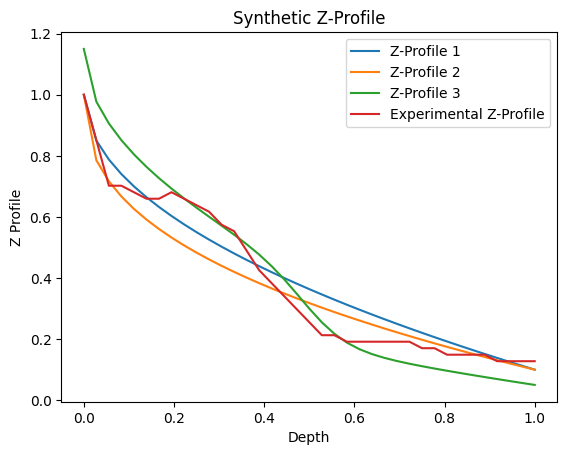

In [170]:
import matplotlib.pyplot as plt
from imaris_ims_file_reader.ims import ims
import tifffile

name = "E-133_S-16_O-1.tif"
input_directory = r"D:\Data Hussein raw\E-133_S-16_O-1"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = tifffile.imread(os.path.join(input_directory, f"{name}"))[14,:,0]
print(cropped.shape)
intensities = []
for z in range(cropped.shape[0]):
    intensities.append(np.percentile(cropped[z], 99))
# remove all values before max of intensities
intensities = intensities[np.argmax(intensities):]

depth = np.linspace(0.0, 1.0, len(intensities), dtype=np.float32)   # 0 = top, 1 = deepest
top, bottom = 1, 0.1
z_profile1 = (top - (top - bottom) * depth**0.5)[:, None, None]
z_profile2 = (top - (top - bottom) * depth**0.4)[:, None, None]

# 1) gentle sqrt falloff (your current curve)
sqrt_part = top - (top - bottom) * np.sqrt(depth)

# 2) sigmoid: slight lift before the knee, bigger drop after
d0, k, deep_drop, boost = 0.5, 20.0, 0.5, 0.15   # +boost = how much higher before the knee
sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
z_profile3 = (sqrt_part * factor)[:, None, None]

plt.plot(depth, z_profile1[:, 0, 0], label="Z-Profile 1")
plt.plot(depth, z_profile2[:, 0, 0], label="Z-Profile 2")
plt.plot(depth, z_profile3[:, 0, 0], label="Z-Profile 3")
plt.plot(depth, np.array(intensities) / np.max(intensities), label="Experimental Z-Profile")
plt.xlabel("Depth")
plt.ylabel("Z Profile")
plt.title("Synthetic Z-Profile")
plt.legend()
plt.show()

In [18]:
import numpy as np
from skimage.measure import regionprops

def centroid_accuracy(gt, pred_mask):
    gt = np.asarray(gt)
    pred_mask = np.asarray(pred_mask)
    if gt.shape != pred_mask.shape:
        raise ValueError("Masks must share shape")

    gt_props = regionprops(gt)
    hit_pred_labels = set()
    predicted_labels = np.array([])
    tp = fn = merged_cells = 0

    fn_list = []
    for prop in gt_props:
        centroid = np.rint(prop.centroid).astype(int)
        centroid = tuple(np.clip(centroid, 0, np.array(gt.shape) - 1))
        pred_label = pred_mask[centroid]
        predicted_labels = np.append(predicted_labels, pred_label)
        if pred_label > 0:
            if pred_label in hit_pred_labels:
                # This predicted label has already been matched to a ground truth cell
                fn += 1
                merged_cells += 1
            else:
                tp += 1
                hit_pred_labels.add(int(pred_label))
        else:
            fn += 1
            fn_list.append(int(prop.label))


    pred_labels = set(np.unique(pred_mask))
    pred_labels.discard(0)
    fp = len(pred_labels - hit_pred_labels)
    fp_list = list(pred_labels - hit_pred_labels)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0

    gt_binary = gt > 0
    pred_binary = pred_mask > 0
    intersection = np.count_nonzero(gt_binary & pred_binary)
    dice = (
        (2 * intersection) / (gt_binary.sum() + pred_binary.sum())
        if (gt_binary.sum() + pred_binary.sum())
        else 0.0
    )

    return {
        "true_positives": tp,
        "false_negatives": fn,
        "false_positives": fp,
        "merged_cells": merged_cells,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "voxel_dice": dice,
        "tp_list": list(hit_pred_labels),
        "fp_list": fp_list,
        "fn_list": fn_list,
    }

In [1]:
import segment3D.usegment3d as uSegment3D
import segment3D.parameters as uSegment3D_params

def usegment_stitch(mask):
    """Stitch a stack of 2D XY label masks into a 3D segmentation (no XZ/YZ needed)."""
    labels_xy = np.squeeze(mask).astype(np.int32)

    p = uSegment3D_params.get_2D_to_3D_aggregation_params()
    p['indirect_method']['dtform_method']       = 'edt'   # pure numpy -> no dask cluster / no hang
    # p['postprocess_binary']['binary_fill_holes'] = True
    p['postprocess_binary']['binary_closing']    = 0     # bridge small z-gaps from signal loss
    p['gradient_descent']['do_mp']               = False  # keep gradient descent single-process too
    p['connected_component']['thresh_factor'] = 1   # default 0 -> raise it. Higher threshold on the
                                                  # point-density map => touching centroids separate
    p['connected_component']['smooth_sigma']  = 0   # default 1 -> lower it. Less density smoothing =>
                                                  # adjacent peaks stay distinct instead of fusing

    segmentation3D, (probability3D, gradients3D) = uSegment3D.aggregate_2D_to_3D_segmentation_indirect_method(
        segmentations=[labels_xy, [], []],
        img_xy_shape=labels_xy.shape,
        precomputed_binary=None,
        params=p, savefolder=None, basename=None)
    return segmentation3D

In [ ]:
from pathlib import Path
import os
import sys
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
from utils.stitch_3d import stitch_3d
import importlib
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.load_model import load_model
from utils.stitch_3d import stitch_3d
from cellpose import models
from time import time
import tifffile
import numpy as np
import pandas as pd


output_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"
model = load_model(r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_low_quality_model")

results = []
for i in range(20):
    # realistic_volume, gt = generate_synthetic_data(number_of_cells = 300, max_attempts = 250, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (420,420,420), organoid_size = 380)
    # print(f"generated {len(np.unique(gt)) - 1} cells in the synthetic organoid")
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid_{i}.tif"), realistic_volume, compression="zlib",
    #     compressionargs={"level": 8})
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid_gt_{i}.tif"), gt.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    gt = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_gt_{i}.tif"))
    realistic_volume = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_{i}.tif"))

    # time_start = time()
    # segmented_2d = segment(realistic_volume, model)
    # time_2d_seg_end = time() 
    # nuclogic_cellpose_time = time_2d_seg_end - time_start

    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_2d_{i}.tif"), segmented_2d.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    segmented_2d = tifffile.imread(os.path.join(output_directory, f"synthetic_segmented_2d_{i}.tif"))
    nuclogic = stitch_3d(segmented_2d, realistic_volume, breaking_threshold = 6, scale=(2.5, 0.64, 0.64))
    time_nuclogic_stitch_end = time()
    # nuclogic_stitch_time = time_nuclogic_stitch_end - time_2d_seg_end
    tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_nuclogic_{i}.tif"), nuclogic.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})

        
    # usegment_start = time()
    # usegment = usegment_stitch(segmented_2d)
    # usegment_end = time()
    # usegment_stitch_time = usegment_end - usegment_start
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_usegment_{i}.tif"), usegment.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    
    # cp4,_,_ = model.eval(
    #                 realistic_volume,
    #                 diameter=None,
    #                 normalize=True,
    #                 flow3D_smooth=0.4,
    #                 resample=True,
    #                 do_3D=True,
    #                 z_axis=0
    #             )
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_cp4_{i}.tif"), cp4.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    # time2 = time()
    # cp4 = tifffile.imread(os.path.join(output_directory, f"synthetic_segmented_cp4_{i}.tif"))
    # np.set_printoptions(suppress=True, precision=4)
    # print(f"Real mask {len(np.unique(gt))-1},NucLogic {len(np.unique(nuclogic))-1}, Cellpose 4 {len(np.unique(cp4))-1}")
    # nuclogic_time = time_nuclogic_stitch_end - time_start
    # cp4_time = time2 - time_nuclogic_stitch_end
    # print(f"NucLogic time: {nuclogic_time:.2f}s, Cellpose 4 time: {cp4_time:.2f}s")
    nuclogic_results = centroid_accuracy(gt, nuclogic)
    # cp4_results = centroid_accuracy(gt, cp4)
    # useg_results = centroid_accuracy(gt, usegment)
    print(f"NucLogic centroid accuracy: {nuclogic_results['f1']:.4f}")
    # print(f"Cellpose 4 centroid accuracy: {cp4_results['f1']:.4f}")
    # print(f"USegment3D centroid accuracy: {useg_results['f1']:.4f}")

    print(f"Nuclogic f1 {nuclogic_results['f1']:.4f}, Cellpose 4 f1 {cp4_results['f1']:.4f}, USegment3D f1 {useg_results['f1']:.4f}")

    # results_df = pd.DataFrame(
    # {
    #     "method": ["nuclogic", "cellpose4", "usegment3d"],
    #     "f1": [nuclogic_results["f1"], cp4_results["f1"], useg_results["f1"]],
    #     "precision": [nuclogic_results["precision"], cp4_results["precision"], useg_results["precision"]],
    #     "recall": [nuclogic_results["recall"], cp4_results["recall"], useg_results["recall"]],
    #     "actual_cells": [len(np.unique(gt)) - 1, len(np.unique(gt)) - 1, len(np.unique(gt)) - 1],
    #     "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1, len(np.unique(usegment)) - 1],
    #     "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"], useg_results["true_positives"]],
    #     "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"], useg_results["false_positives"]],
    #     "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"], useg_results["false_negatives"]],
    #     "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"], useg_results["merged_cells"]],
    #     "total_time": [nuclogic_time, cp4_time, usegment_stitch_time+nuclogic_cellpose_time],
    #     "nuclogic_2d_time": [nuclogic_cellpose_time, 0, nuclogic_cellpose_time],
    #     "stitching_time": [nuclogic_stitch_time, 0, usegment_stitch_time],
    # }
    # )
    results_df = pd.DataFrame(
        {
            "method": ["nuclogic"],
            "f1": [nuclogic_results["f1"]],
            "precision": [nuclogic_results["precision"]],
            "recall": [nuclogic_results["recall"]],
            "actual_cells": [len(np.unique(gt)) - 1],
            "predicted_cells": [len(np.unique(nuclogic)) - 1],
            "true_positives": [nuclogic_results["true_positives"]],
            "false_positives": [nuclogic_results["false_positives"]],
            "false_negatives": [nuclogic_results["false_negatives"]],
            "merged_cells": [nuclogic_results["merged_cells"]],
        }
        )
    name = f"synthetic_organoid_{i}"
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

results_df.to_csv(os.path.join(output_directory, "synthetic_results_nuc.tsv"), sep="\t", index=False)


Using CUDA for processing.
loaded custom model: 2d_low_quality_model
Starting 3D stitching process...
Created 2979 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 288 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 32 breaks.
    Iteration 2: Made 15 breaks.
    Iteration 3: Made 3 breaks.
Finding touching cell pairs...
Found 97 pairs of touching cells.
Splitted 66 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 5 small cells, and removed 22 cells without suitable neighbors.
Final stitched mask has 311 cells.
NucLogic centroid accuracy: 0.9755
Nuclogic f1 0.9755, Cellpose 4 f1 0.9630, USegment3D f1 0.9282
Starting 3D stitching process...
Created 2974 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 285 cells formed.
Starting iterative breaking of cells
    Iteration 1: 

In [4]:
import ssl

_orig = ssl.SSLContext.load_default_certs
def _safe(self, purpose=ssl.Purpose.SERVER_AUTH):
    try: _orig(self, purpose)
    except ssl.SSLError: pass
ssl.SSLContext.load_default_certs = _safe

In [ ]:
import skimage.io as skio 
import pylab as plt 
import numpy as np 
import scipy.ndimage as ndimage
import skimage.segmentation as sksegmentation 
import os 
import skimage.exposure as skexposure
import segment3D.parameters as uSegment3D_params # this is useful to call default parameters, and keep track of parameter changes and for saving parameters.  
import segment3D.gpu as uSegment3D_gpu
import segment3D.usegment3d as uSegment3D
import segment3D.filters as uSegment3D_filters 
import segment3D.file_io as uSegment3D_fio

def usegment3D(image, model="nuclei", scale=(2.5, 0.64, 0.64)):
    preprocess_params = uSegment3D_params.get_preprocess_params()
    px_res = scale[1]/scale[0] 
    factor = 0.5 # to resonate with approx 30 diameter in cellpose
    preprocess_params['factor'] = factor # istropic scaling factor 
    preprocess_params['voxel_res'] = [1./px_res, 1., 1.] # scale up 
    img_preprocess = uSegment3D.preprocess_imgs(image, params=preprocess_params)
    img_preprocess = np.squeeze(img_preprocess)
    # img_preprocess = ndimage.median_filter(img_preprocess, size=3)

    cellpose_segment_params = uSegment3D_params.get_Cellpose_autotune_params()
    cellpose_segment_params['cellpose_modelname'] = model 
        
    """
    If the below auto-inferred diameter is picking up noise and being too small, we can increase the default ksize, alternatively we can add median_filter.
    """
    cellpose_segment_params['ksize'] = 15
    cellpose_segment_params['best_diam'] = 20

    # invert model
    cellpose_segment_params['model_invert'] = False # new cellpose seems to prefer no model inversion? for membrane markers.
    cellpose_segment_params['use_edge'] = True # for autofinding best slice. 
    print(f"GPU: {cellpose_segment_params['gpu']}")
    if len(img_preprocess.shape) == 3:
        # this expects a multichannel input image and in the format (M,N,L,channels) i.e. channels last.
        img_preprocess = img_preprocess[...,None] # we generate an artificial channel
    #### 1. running for xy orientation. If the savefolder and basename are specified, the output will be saved as .pkl and .mat files 
    img_segment_2D_xy_diams, img_segment_3D_xy_probs, img_segment_2D_xy_flows, img_segment_2D_xy_styles = uSegment3D.Cellpose2D_model_auto(img_preprocess, 
                                                                                                                                            view='xy', 
                                                                                                                                            params=cellpose_segment_params, 
                                                                                                                                            basename=None, savefolder=None)
    # #### 2. running for xz orientation 
    # img_segment_2D_xz_diams, img_segment_3D_xz_probs, img_segment_2D_xz_flows, img_segment_2D_xz_styles = uSegment3D.Cellpose2D_model_auto(img_preprocess, 
    #                                                                                                                                         view='xz', 
    #                                                                                                                                         params=cellpose_segment_params, 
    #                                                                                                                                         basename=None, savefolder=None)

    # #### 3. running for yz orientation 
    # img_segment_2D_yz_diams, img_segment_3D_yz_probs, img_segment_2D_yz_flows, img_segment_2D_yz_styles = uSegment3D.Cellpose2D_model_auto(img_preprocess, 
    #                                                                                                                                         view='yz', 
    #                                                                                                                                         params=cellpose_segment_params, 
    #                                                                                                                                         basename=None, savefolder=None)



    # =============================================================================
    #     3. We can now use the predicted probabilies and flows directly to aggregate a 3D consensus segmentation (Direct Method)
    # =============================================================================

    aggregation_params = uSegment3D_params.get_2D_to_3D_aggregation_params()

    # make sure that we say we are using Cellpose probability predictions which needs to be normalized. If not using Cellpose predicted masks, then set this to be False. We assume this has been appropriately normalized to 0-1
    aggregation_params['combine_cell_probs']['cellpose_prob_mask'] = True 

    # add some temporal decay 
    aggregation_params['gradient_descent']['gradient_decay'] = 0.05 # increase this to alleviate splitting of elongated/branching structures with cellpose gradients or decrease towards 0.0 to encourage splitting. 
    aggregation_params['postprocess_binary']['binary_fill_holes'] = True # we want the base segmentations to have holes filled


    # probs and gradients should be supplied in the order of [xy, xz, yz]. if one or more do not exist use [] e.g. [xy, [], []]
    segmentation3D, (probability3D, gradients3D) = uSegment3D.aggregate_2D_to_3D_segmentation_direct_method(probs=[img_segment_3D_xy_probs,
                                                                                                                    [],
                                                                                                                    []], 
                                                                                                            gradients=[img_segment_2D_xy_flows,
                                                                                                                        [],
                                                                                                                        []], 
                                                                                                            params=aggregation_params,
                                                                                                            savefolder=None,
                                                                                                            basename=None)
    
    postprocess_segment_params = uSegment3D_params.get_postprocess_segmentation_params()
    postprocess_segment_params['flow_consistency']['flow_threshold'] = 0.85 # we can adjust the threshold if needed
    segmentation3D_filt, flow_consistency_intermediates = uSegment3D.postprocess_3D_cell_segmentation(segmentation3D,
                                                                                                      aggregation_params=aggregation_params,
                                                                                                      postprocess_params=postprocess_segment_params,
                                                                                                      cell_gradients=gradients3D,
                                                                                                      savefolder=None,
                                                                                                      basename=None)
    return segmentation3D_filt


In [3]:
# try stardist

import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize

output_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0,1,2)
results = []

for i in range(20):
    # realistic_volume, gt = generate_synthetic_data(number_of_cells = 300, max_attempts = 150, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (420,420,420), organoid_size = 380)
    realistic_volume = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_{i}.tif"))
    gt = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_gt_{i}.tif"))
    time_start = time()
    img = normalize(realistic_volume, 1,99.8, axis=axis_norm)
    stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    time_end = time()
    star_time = time_end - time_start
    tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_stardist_{i}.tif"), stardist.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})
    np.set_printoptions(suppress=True, precision=4)
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt, stardist)
    print(f"StarDist3D centroid accuracy: {stardist_results['f1']:.4f}")

    print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

    results_df = pd.DataFrame(
    {
        "method": ["stardist"],
        "f1": [stardist_results["f1"]],
        "precision": [stardist_results["precision"]],
        "recall": [stardist_results["recall"]],
        "actual_cells": [len(np.unique(gt)) - 1],
        "predicted_cells": [len(np.unique(stardist)) - 1],
        "true_positives": [stardist_results["true_positives"]],
        "false_positives": [stardist_results["false_positives"]],
        "false_negatives": [stardist_results["false_negatives"]],
        "merged_cells": [stardist_results["merged_cells"]],
        "total_time": [star_time],
        "nuclogic_2d_time": [0],
        "stitching_time": [0],
    }
    )
    name = f"synthetic_organoid_{i}"
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "synthetic_results_stardist.tsv"), sep="\t", index=False)

Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.


100%|██████████| 32/32 [00:09<00:00,  3.41it/s]


stardist time: 11.08s
StarDist3D centroid accuracy: 0.5795
StarDist3D f1 0.5795


100%|██████████| 32/32 [00:08<00:00,  3.64it/s]


stardist time: 9.90s
StarDist3D centroid accuracy: 0.5536
StarDist3D f1 0.5536


...

stardist time: 10.10s
StarDist3D centroid accuracy: 0.5471
StarDist3D f1 0.5471


100%|██████████| 32/32 [00:09<00:00,  3.55it/s]


stardist time: 10.21s
StarDist3D centroid accuracy: 0.5751
StarDist3D f1 0.5751


100%|██████████| 32/32 [00:09<00:00,  3.53it/s]


stardist time: 10.19s
StarDist3D centroid accuracy: 0.5758
StarDist3D f1 0.5758


<>:62: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:62: SyntaxWarning: "is not" with a literal. Did you mean "!="?
C:\Users\6331823\AppData\Local\Temp\ipykernel_33816\744517341.py:62: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if text is not "ns":


Removing y-tick labels for axis 1
Removing y-tick labels for axis 2
T-test for total_time: t-statistic = -4.4166, p-value = 0.0000


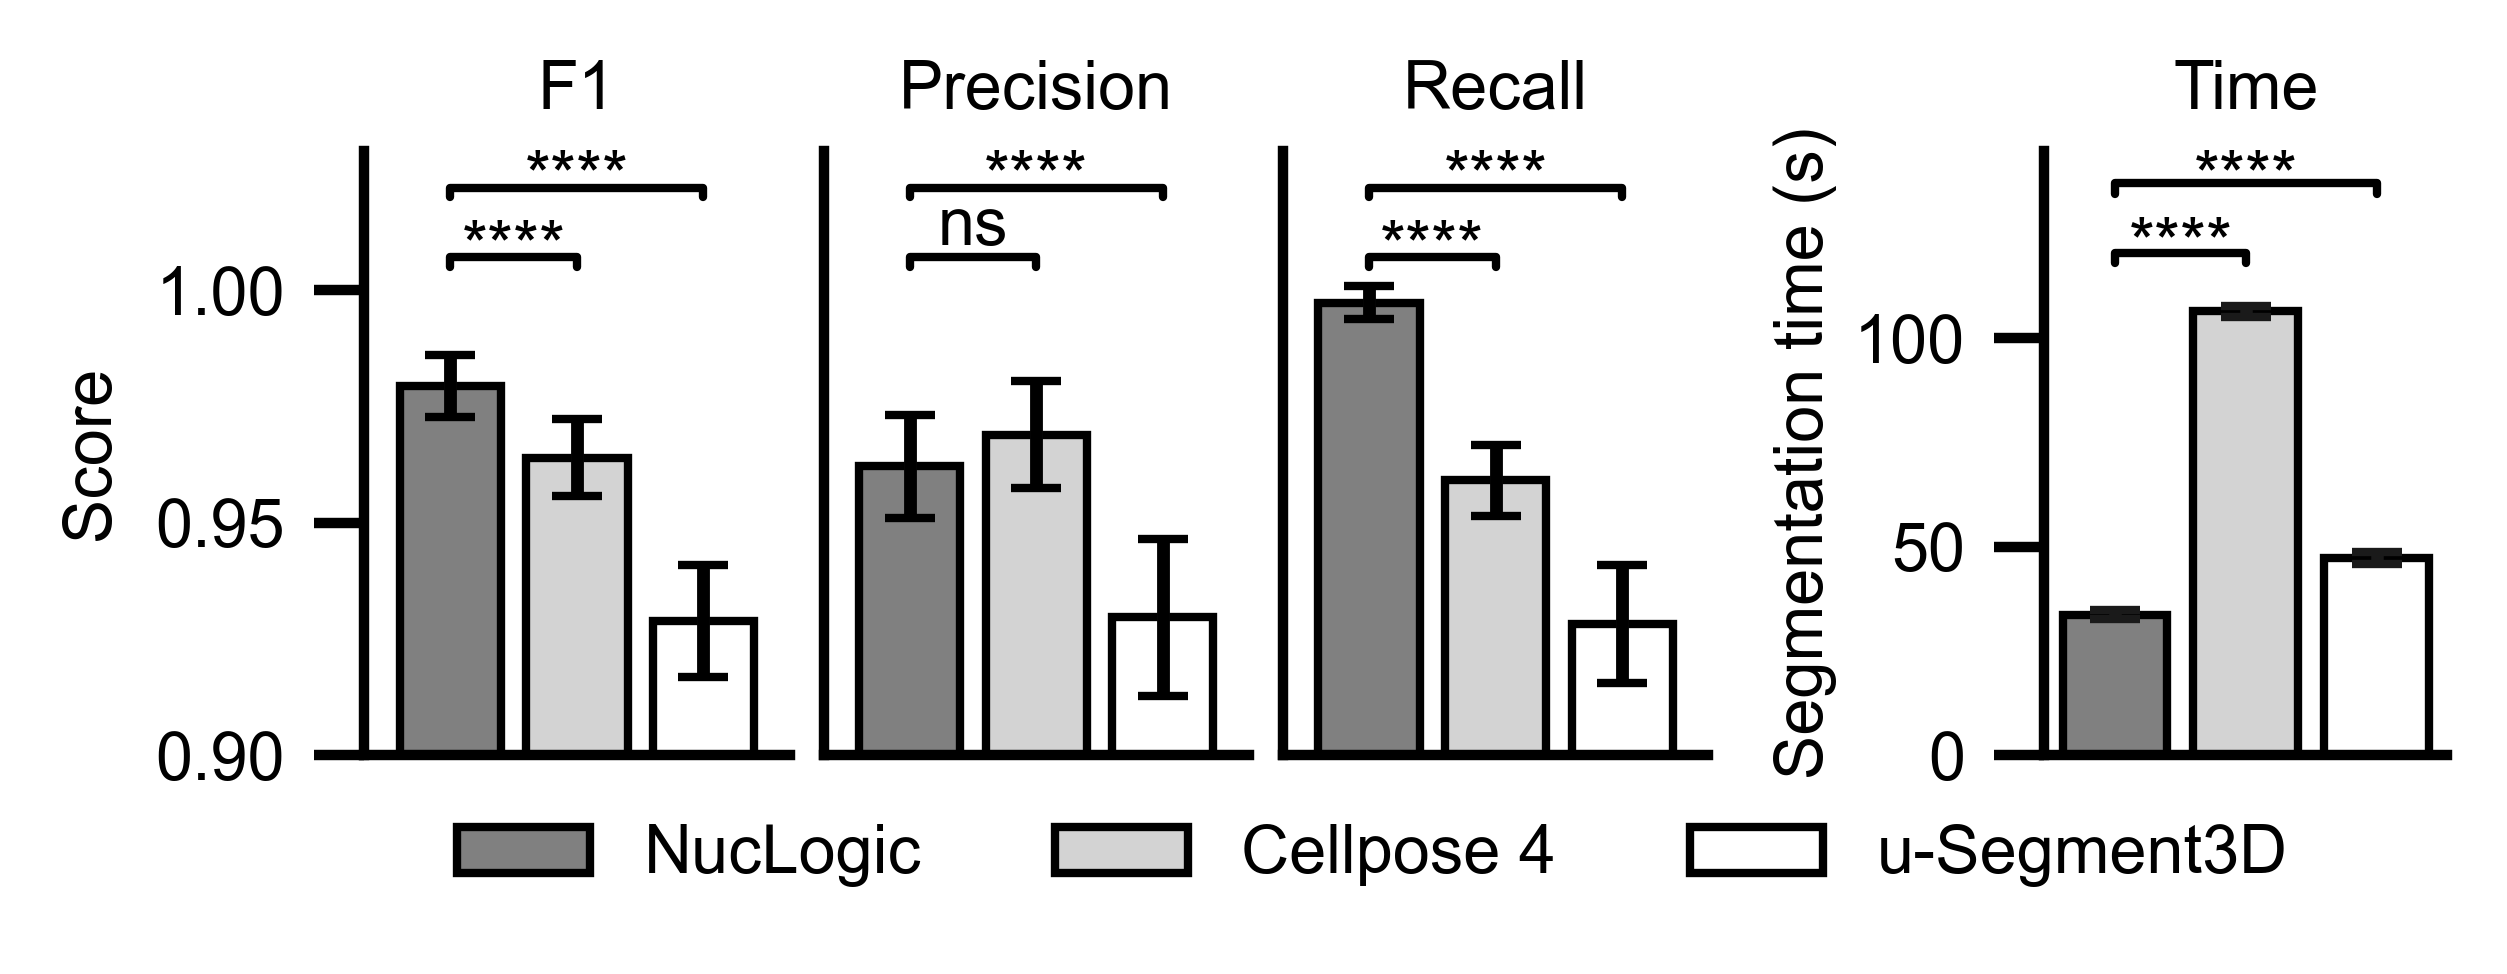

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ttest_ind
from matplotlib.patches import Patch
import os
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "synthetic_results_new.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
score_metrics = ["f1", "precision", "recall"]
time_metric = "total_time"
sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
    },
)
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)
cols = score_metrics + [time_metric]            
agg = results.groupby("method")[cols].agg(["mean", "std"])

method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
legend_handles = [
    Patch(facecolor=method_colors[m], edgecolor="black", label=m)
    for m in methods
]

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
def add_bracket(ax, x1, x2, y, text, dh=0.03, barh=0.01):
    ax.plot([x1, x1, x2, x2], [y, y + barh*y, y + barh*y, y], color="black", lw=1)
    if text is not "ns":
        ax.text((x1 + x2) / 2, y + barh - dh*y, text, ha="center", va="bottom", fontsize=8)
    else:
        ax.text((x1 + x2) / 2, y + barh, text, ha="center", va="bottom", fontsize=8)

fig = plt.figure(figsize=(5.6*0.8, 2*0.8), dpi=600)
outer = fig.add_gridspec(1, 3, width_ratios=[3.0, 0.75, 0.9], wspace=0.0)

left = outer[0].subgridspec(1, 3, wspace=0.08)
axes = [fig.add_subplot(left[0, i]) for i in range(3)]

spacer = fig.add_subplot(outer[1])
spacer.axis("off")

time_ax = fig.add_subplot(outer[2])
axes.append(time_ax)

# --- 3 score bars on the LEFT axis ---
for i, metric in enumerate(score_metrics):
    means = [agg.loc[m, (metric, "mean")] for m in methods]
    sds   = [agg.loc[m, (metric, "std")]  for m in methods]

    # perform t test to check if the difference between the two methods is significant
    p_cp4 = ttest_ind(
        results[results["method"] == "NucLogic"][metric],
        results[results["method"] == "Cellpose 4"][metric],
        equal_var=False,
    ).pvalue

    p_useg = ttest_ind(
            results[results["method"] == "NucLogic"][metric],
            results[results["method"] == "u-Segment3D"][metric],
            equal_var=False,
    ).pvalue
    reject, p_adj, _, _ = multipletests([p_cp4, p_useg], alpha=0.05, method="holm")
    p_cp4_adj, p_useg_adj = p_adj
    fillcolor = [method_colors[m] for m in methods]
    axes[i].bar(methods, means, yerr=sds, linewidth=1,
           label=metric.capitalize(), color=fillcolor, edgecolor="black")
    

    max_height = 1.005
    add_bracket(axes[i], 0, 1, max_height, significance_text(p_cp4_adj), dh=0.005, barh=0.002)
    add_bracket(axes[i], 0, 2, max_height + 0.015, significance_text(p_useg_adj), dh=0.005, barh=0.002)
        
    axes[i].set_ylim(0.9, 1.03)
    axes[i].set_ylabel("")
    axes[i].set_title(metric.capitalize(), pad=5)
    axes[i].errorbar(x=methods, y=means, yerr=sds, fmt='none', color="black", capsize=3)
    axes[i].margins(x=0.1)

    if i != 0:
        print(f"Removing y-tick labels for axis {i}")
        axes[i].set_yticklabels("")
        # axes[i].tick_params(left=True, bottom=False)
    else:
        axes[i].set_ylabel("Score")
        axes[i].tick_params(left=True, bottom=False)


# --- cosmetics ---
for ax in axes:
    ax.tick_params(axis="x", labelbottom=False, bottom=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

time_ax.set_ylabel("Segmentation time (s)", labelpad=2) #can adjust labelpad
time_ax.yaxis.set_label_position("left")
time_ax.yaxis.tick_left()
time_ax.tick_params(left=True, labelleft=True, right=False, labelright=False)
means = [agg.loc[m, (time_metric, "mean")] for m in methods]
sds   = [agg.loc[m, (time_metric, "std")]  for m in methods]
p_cp4 = ttest_ind(
    results[results["method"] == "NucLogic"][metric],
    results[results["method"] == "Cellpose 4"][metric],
    equal_var=False,
).pvalue

p_useg = ttest_ind(
        results[results["method"] == "NucLogic"][metric],
        results[results["method"] == "u-Segment3D"][metric],
        equal_var=False,
).pvalue
reject, p_adj, _, _ = multipletests([p_cp4, p_useg], alpha=0.05, method="holm")
p_cp4_adj, p_useg_adj = p_adj
print(f"T-test for {time_metric}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
fillcolor = [method_colors[m] for m in methods]
axes[3].bar(methods, means, yerr=sds, linewidth=1, capsize=3,
        label=metric.capitalize(), color=fillcolor, edgecolor="black")

max_height = 118
add_bracket(axes[3], 0, 1, max_height, significance_text(p_cp4_adj), barh=0.02)
add_bracket(axes[3], 0, 2, max_height*1.14, significance_text(p_useg_adj), barh=0.02)

axes[3].set_ylim(0, 145)
axes[3].set_title("Time", pad=5)

fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.05))
fig.subplots_adjust(bottom=0.25)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
# plt.savefig(os.path.join(figure_folder, "synthetic_results_scores_all.eps"), dpi=600, bbox_inches="tight")
plt.show()

Figure 2D

In [9]:
import napari
import sys
import os
from napari.utils.colormaps import colormap_utils as cu
import tifffile
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.centroid_accuracy import centroid_accuracy

colormap = cu.label_colormap(num_colors=1024)
colormap_seg = {0: '', 1: "#65ae45", 2: 'cyan', 3: 'magenta'}

def color_mask(mask, gt):
    results = centroid_accuracy(gt, mask)
    tp_list = results["tp_list"]
    print(f"True positives: {len(tp_list)}")
    fp_list = results["fp_list"]
    fn_list = results["fn_list"]
    # mask-based classes (tp=1, fp=2)
    lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
    lut[np.asarray(tp_list, dtype=int)] = 1
    lut[np.asarray(fp_list, dtype=int)] = 2
    colored = lut[mask]

    # fn comes from gt, painted on top
    fn_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
    fn_lut[np.asarray(fn_list, dtype=int)] = 3
    colored[fn_lut[gt] == 3] = 3
    return colored

input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"

organoid_number = 3
realistic_volume = tifffile.imread(os.path.join(input_directory, f"synthetic_organoid_{organoid_number}.tif"))
gt = tifffile.imread(os.path.join(input_directory, f"synthetic_organoid_gt_{organoid_number}.tif"))
nuclogic = tifffile.imread(os.path.join(input_directory, f"synthetic_segmented_nuclogic_{organoid_number}.tif"))
nuclogic = color_mask(nuclogic, gt)
cp4 = tifffile.imread(os.path.join(input_directory, f"synthetic_segmented_cp4_{organoid_number}.tif"))
cp4 = color_mask(cp4, gt)
usegment = tifffile.imread(os.path.join(input_directory, f"synthetic_segmented_usegment_{organoid_number}.tif"))
usegment = color_mask(usegment, gt)
viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)

y_half = slice(0, realistic_volume.shape[1] // 2)
x_half = slice(0, realistic_volume.shape[2])

contrast = (np.median(realistic_volume) * 0.8, np.percentile(realistic_volume, 99.98))
viewer.add_image(realistic_volume[:, y_half, x_half], scale = scale, contrast_limits = contrast, colormap="Greys")
# viewer.add_labels(gt[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.add_labels(cp4[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.add_labels(usegment[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "synthetic_data_colored.png"), canvas_only=True, scale = 4)

# add top slice
# set ndisplay to 2d
# viewer = napari.Viewer(ndisplay=2)
# viewer.add_image(realistic_volume, scale = scale, contrast_limits = (100, 115), colormap="Greys")
# viewer.add_labels(nuclogic, scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
# viewer.add_labels(cp4, scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
# viewer.add_labels(usegment, scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
# # viewer.reset_view()
# # set z slice to top
# viewer.dims.set_point(0, realistic_volume.shape[0] - 1)
# viewer.dims.current_step = (101, 0, 0)
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# #toggle grid mode on
# viewer.grid.enabled = True
# viewer.theme = 'light'
# napari.run()

# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# viewer.screenshot(path=os.path.join(output_directory, "synthetic_data_slice.png"), canvas_only=True, scale = 2)


True positives: 300
True positives: 287
True positives: 277


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

Test on drosophila

In [35]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import tifffile
import pandas as pd

names = ["Drosophila_1", "Drosophila_2"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

scale = (1, 1, 1)

# model = load_model(r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1\model\drosophila")
# model = load_model(
#     r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
# )

results = []
for name in names:
    input_directory = os.path.join(base_directory, name)

    image = tifffile.imread(os.path.join(input_directory, "data.tif"))

    # start_time = time.time()
    # mask = segment(image, model)
    # tifffile.imwrite(
    #     os.path.join(input_directory, "2d_segmented_seg4.tif"),
    #     mask,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_trained.tif"))
    # segmentation_time = time.time() - start_time


    # start_stitch_time = time.time()
    # nuclogic = stitch_3d(
    #     mask,
    #     image,
    #     image_type_1="wt",
    #     breaking_threshold=6,
    #     scale=scale
    # )
    # end_time = time.time()
    # nuclogic_time = end_time - start_time
    # nuclogic_cellpose_time = start_stitch_time - start_time
    # nuclogic_stitch_time = end_time - start_stitch_time
    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_nuclogic_seg4.tif"),
    #     nuclogic,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    ground_truth = tifffile.imread(
        os.path.join(input_directory, "GroundTruth.tif")
    )

    # nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    # print(f"centroid accuracy: {nuclogic_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    # )

    # print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    # print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    # print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")

    usegment_start = time.time()
    usegment = usegment_stitch(mask)
    usegment_end = time.time()
    usegment_results = (centroid_accuracy(ground_truth, usegment))
    print(f"centroid accuracy: {usegment_results}")
    print(usegment_end - usegment_start)

    # start_cp4 = time.time()
    # cp4,_,_ = model.eval(
    #                 image,
    #                 diameter=None,
    #                 normalize=True,
    #                 flow3D_smooth=0.4,
    #                 invert=False,
    #                 resample=True,
    #                 do_3D=True,
    #                 z_axis=0
    #             )
    # end_cp4 = time.time()
    # cp4_time = end_cp4 - start_cp4

    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_cp4.tif"),
    #     cp4,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    # cp4_results = (centroid_accuracy(ground_truth, cp4))
    # print(f"centroid accuracy: {cp4_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    # )
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    # print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # # save results of centroid accuracy and amount of cells to a tsv file

#     results_df = pd.DataFrame(
#         {
#             "method": ["nuclogic", "cellpose4"],
#             "f1": [nuclogic_results["f1"], cp4_results["f1"]],
#             "precision": [nuclogic_results["precision"], cp4_results["precision"]],
#             "recall": [nuclogic_results["recall"], cp4_results["recall"]],
#             "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
#             "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
#             "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
#             "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
#             "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
#             "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
#             "total_time": [nuclogic_time, cp4_time],
#             "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
#             "stitching_time": [nuclogic_stitch_time, 0],
#         }
#     )
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "zebrafish_results_seg4.tsv"), sep="\t", index=False)

centroid accuracy: {'true_positives': 476, 'false_negatives': 14, 'false_positives': 19, 'merged_cells': 0, 'precision': 0.9616161616161616, 'recall': 0.9714285714285714, 'f1': 0.966497461928934, 'voxel_dice': 0.7830214615947255, 'tp_list': [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 145, 146, 147, 148, 149, 150, 152, 153, 154, 155, 156, 157, 158, 159, 160, 163, 164, 165, 166, 167, 168, 169, 171, 172, 173, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188,

100%|██████████| 200/200 [01:18<00:00,  2.55it/s]


centroid accuracy: {'true_positives': 1582, 'false_negatives': 112, 'false_positives': 404, 'merged_cells': 96, 'precision': 0.796576032225579, 'recall': 0.9338842975206612, 'f1': 0.8597826086956522, 'voxel_dice': 0.8880406428464008, 'tp_list': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 88, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 103, 104, 105, 108, 109, 110, 111, 112, 113, 115, 116, 119, 120, 121, 122, 125, 126, 127, 128, 129, 130, 131, 133, 134, 136, 138, 139, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 155, 157, 159, 162, 164, 165, 166, 167, 168, 169, 170, 172, 173, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 194, 195, 197, 198, 200, 201, 202, 2

100%|██████████| 200/200 [00:40<00:00,  4.93it/s]


centroid accuracy: {'true_positives': 482, 'false_negatives': 8, 'false_positives': 13, 'merged_cells': 1, 'precision': 0.9737373737373738, 'recall': 0.9836734693877551, 'f1': 0.9786802030456854, 'voxel_dice': 0.8610440991431632, 'tp_list': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176,

In [5]:
# drosophila stardist
# try stardist

import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize

names = ["Drosophila_1", "Drosophila_2"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0,1,2)
results = []

for name in names:
    input_directory = os.path.join(base_directory, name)
    image = tifffile.imread(os.path.join(input_directory, "data.tif"))
    gt = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))    
    # time_start = time()
    # img = normalize(image, 1,99.8, axis=axis_norm)
    # stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    # time_end = time()
    # star_time = time_end - time_start
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_stardist_{name}.tif"), stardist.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    stardist = tifffile.imread(os.path.join(input_directory, f"3d_segmented_stardist_{name}.tif"))
    np.set_printoptions(suppress=True, precision=4)
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt, stardist)
    print(f"StarDist3D centroid accuracy: {stardist_results}")

#     print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

#     results_df = pd.DataFrame(
#     {
#         "method": ["stardist"],
#         "f1": [stardist_results["f1"]],
#         "precision": [stardist_results["precision"]],
#         "recall": [stardist_results["recall"]],
#         "actual_cells": [len(np.unique(gt)) - 1],
#         "predicted_cells": [len(np.unique(stardist)) - 1],
#         "true_positives": [stardist_results["true_positives"]],
#         "false_positives": [stardist_results["false_positives"]],
#         "false_negatives": [stardist_results["false_negatives"]],
#         "merged_cells": [stardist_results["merged_cells"]],
#         "total_time": [star_time],
#         "nuclogic_2d_time": [0],
#         "stitching_time": [0],
#     }
#     )
#     name = f"synthetic_organoid_{i}"
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "synthetic_results_stardist.tsv"), sep="\t", index=False)

Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
stardist time: 236.04s
StarDist3D centroid accuracy: {'true_positives': 1104, 'false_negatives': 590, 'false_positives': 213, 'merged_cells': 2, 'precision': 0.8382687927107062, 'recall': 0.6517119244391971, 'f1': 0.7333111922949187, 'voxel_dice': 0.50332259495602, 'tp_list': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 34, 35, 37, 38, 39, 40, 41, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 56, 57, 60, 63, 64, 65, 66, 67, 68, 69, 70, 73, 74, 76, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 1

In [ ]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)

names = ["Drosophila_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
dir = os.path.join(base_directory, names[0])
image = tifffile.imread(os.path.join(dir, "data.tif"))
ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))
viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)

viewer.reset_view()
viewing_angle = (0, 180, 90)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "drosophila_data.png"), canvas_only=True, scale = 2.2)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (109.09719441054212, 99.90710855199106, 302.3227946123624)
viewer.camera.zoom   = 11.503409054721994
# @viewer.bind_key('c')  # press 'c' to capture camera state
# def print_camera(viewer):
#     print(f"viewer.camera.center = {viewer.camera.center}")
#     print(f"viewer.camera.angles = {viewer.camera.angles}")
#     print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "drosophila_zoomed.png"), canvas_only=True, scale = 2)

NameError: name 'os' is not defined

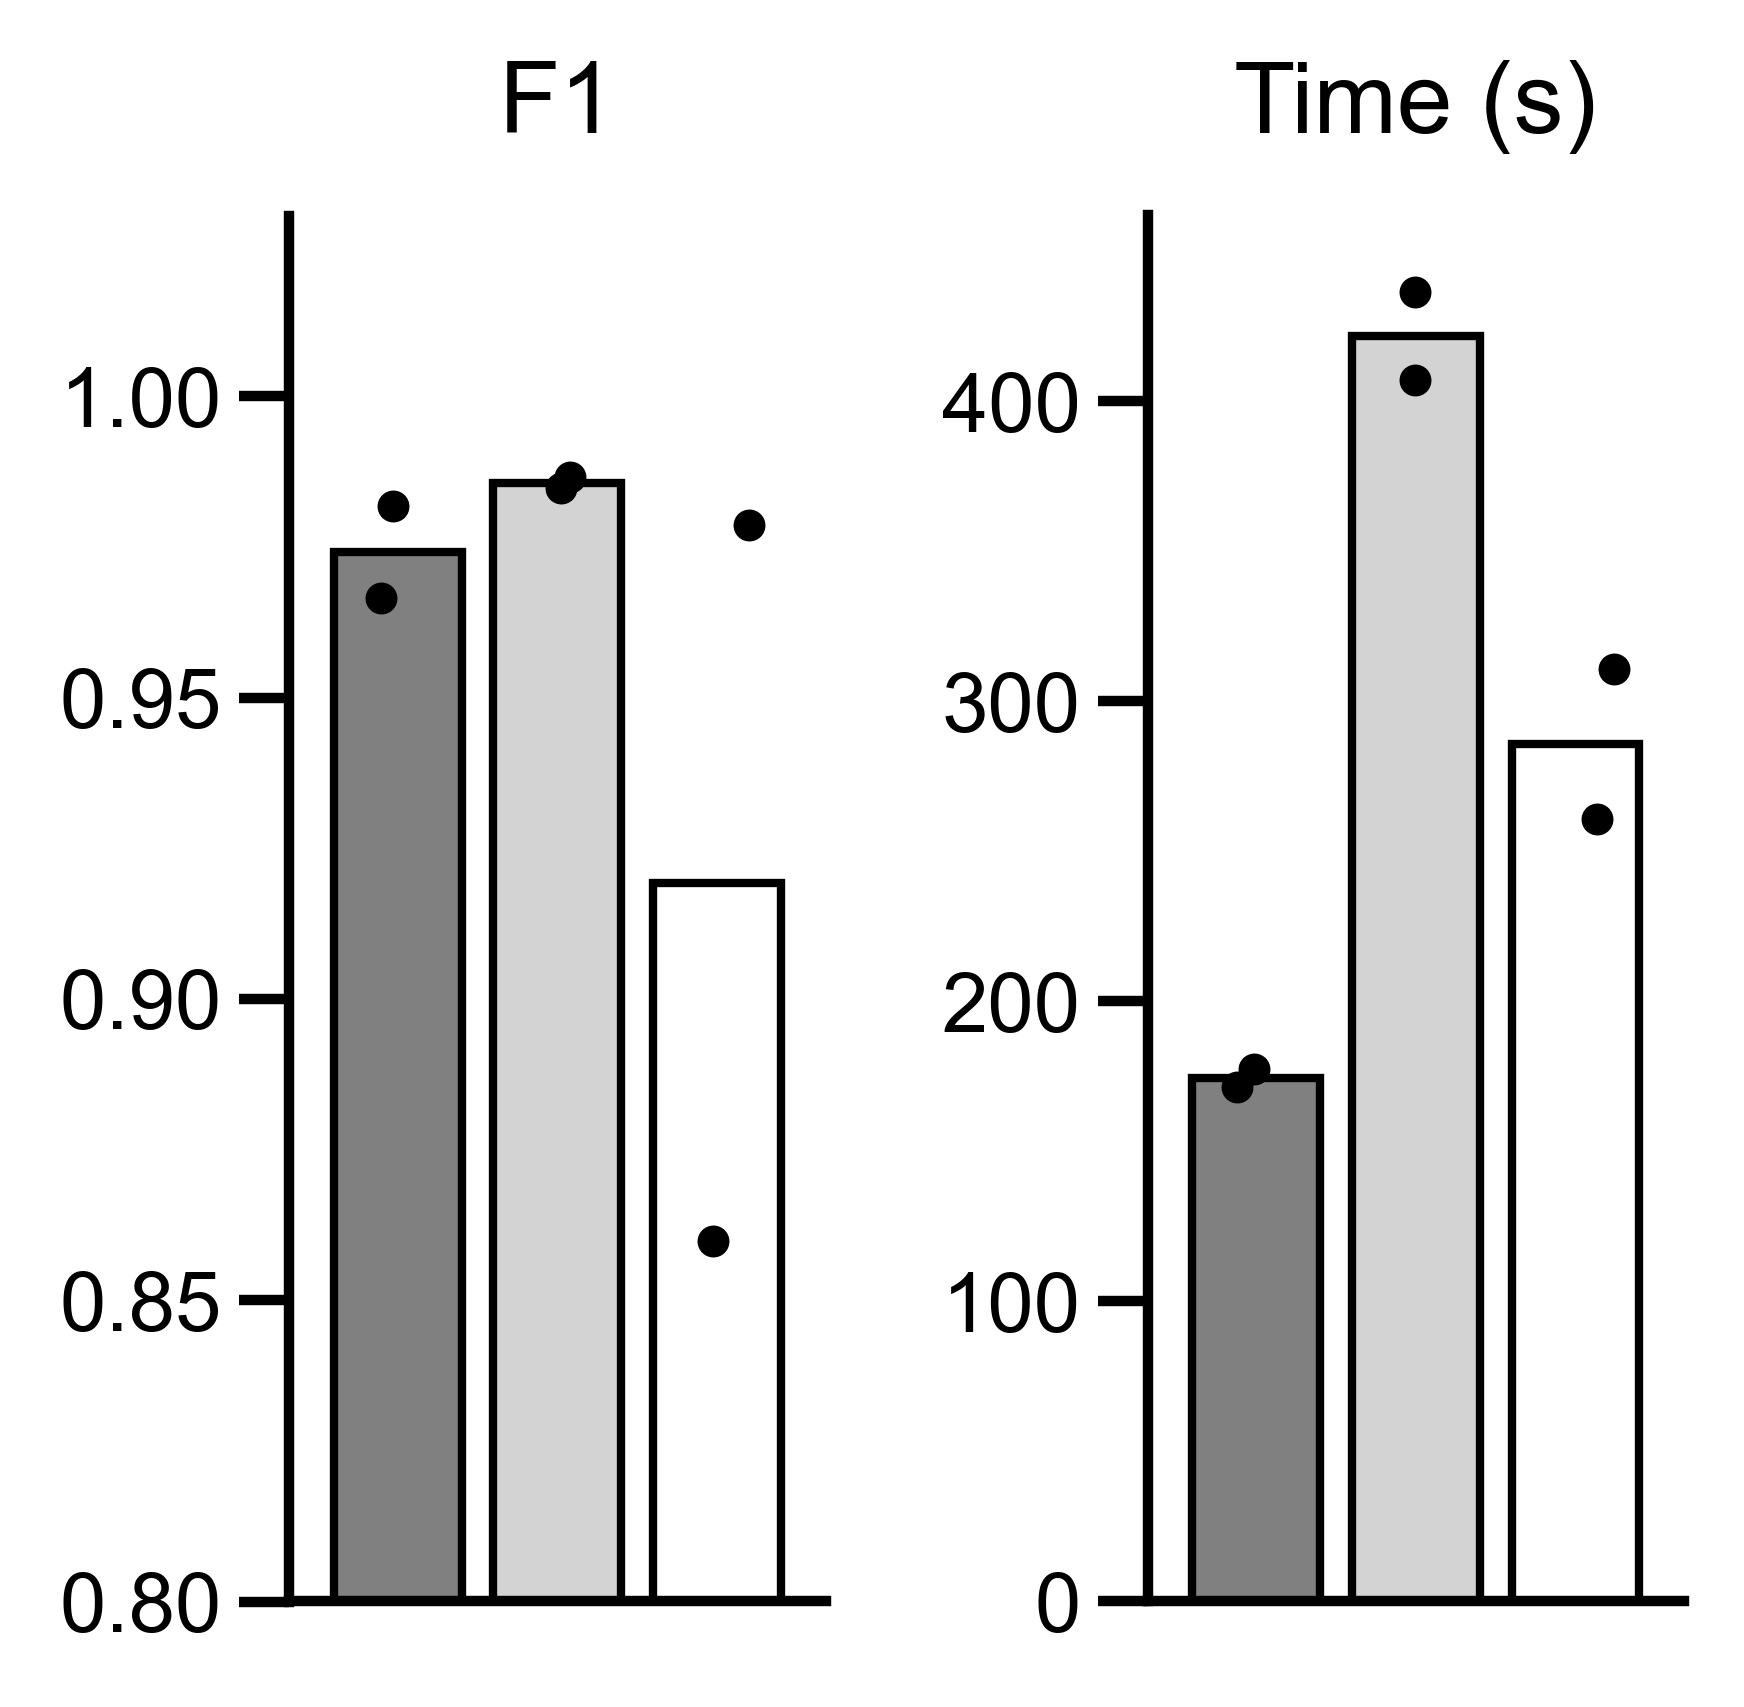

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "drosophila_results.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
metrics = ["f1", "total_time"]
method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)                    
agg = results.groupby("method")[metrics].agg(["mean", "std"])

x = np.arange(len(methods))          # one group center per method
color =  "black"

fig, axes = plt.subplots(
    figsize=(3, 3),
    dpi=600,
    ncols=2,
    gridspec_kw={"width_ratios": [1,1], "wspace": 0.6},
)


for i, metric in enumerate(metrics):
        means = [agg.loc[m, (metric, "mean")] for m in methods]
        sds   = [agg.loc[m, (metric, "std")]  for m in methods]
        axes[i].bar(x=methods, height=means, capsize=4, linewidth=1,
                label="Time", color=[method_colors[m] for m in methods], edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars
        # axes[i].errorbar(x=methods, y=means, yerr=sds, fmt='none', color="black", capsize=4)
        for j, method in enumerate(methods):
                vals = results.loc[results["method"] == method, metric].to_numpy()
                jitter = np.random.normal(loc=0, scale=0.1, size=len(vals))
                axes[i].scatter(
                        np.full(len(vals), x[j]) + jitter,
                        vals,
                        color="black",
                        s=8,
                        zorder=3,
                )

        axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        axes[i].set_xticklabels("", size=8)
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)

        axes[i].tick_params(left=True, bottom=False) 
        axes[i].tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
        axes[i].margins(x=0.1)
        axes[i].set_ylabel("")
        axes[i].tick_params(axis="y", labelsize=10)

        nuclogic_values = results[results["method"] == "NucLogic"][metric]
        cellpose_values = results[results["method"] == "Cellpose 4"][metric]
        usegment_values = results[results["method"] == "u-Segment3D"][metric]
        star_values = results[results["method"] == "StarDist"][metric]
     
        if i == 0:
                axes[i].set_title("F1", pad=10)
                axes[i].set_ylim(0.8, 1.03)
        else:
                axes[i].set_title("Time (s)", pad=10)
                axes[i].set_ylim(0, 462)



figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "drosophila_results_full.eps"), dpi=600, bbox_inches="tight")
plt.show()

Zebrafish

In [1]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import tifffile
import pandas as pd

# names = ["Drosophila_1", "Drosophila_2"]
names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

model = load_model(
    r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model\models\zebrafish"
)
# model = load_model(
#     r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
# )

results = []
for name in names:
    if name == "Zebrafish_1":
        scale = (2.5, 0.43, 0.43)

    input_directory = os.path.join(base_directory, name)

    image = tifffile.imread(os.path.join(input_directory, "data.tif"))

    # start_time = time.time()
    # mask = segment(image, model)
    # tifffile.imwrite(
    #     os.path.join(input_directory, "2d_segmented_trained.tif"),
    #     mask,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_trained.tif"))
    # segmentation_time = time.time() - start_time


    start_stitch_time = time.time()
    nuclogic = stitch_3d(
        mask,
        image,
        image_type_1="wt",
        breaking_threshold=6,
        scale=scale
    )
    end_time = time.time()
    # nuclogic_time = end_time - start_time
    # nuclogic_cellpose_time = start_stitch_time - start_time
    nuclogic_stitch_time = end_time - start_stitch_time
    print(f"Stitching completed in {nuclogic_stitch_time:.2f} seconds.")
    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_nuclogic_trained.tif"),
    #     nuclogic,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    # nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_trained.tif"))

    ground_truth = tifffile.imread(
        os.path.join(input_directory, "GroundTruth.tif")
    )

    # nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    # print(f"centroid accuracy: {nuclogic_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    # )

    # print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    # print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    # print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")

    # print("Running u-Segment3D...")
    # usegment_start = time.time()
    # usegment = usegment_stitch(mask)
    # usegment_end = time.time()
    # usegment_time = usegment_end - usegment_start
    # usegment_results = (centroid_accuracy(ground_truth, usegment))
    # print(f"centroid accuracy: {usegment_results}")
    # print(f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(usegment)) - 1}")
    # print(f"u-Segment3D completed in {usegment_time:.2f} seconds.")

#     start_cp4 = time.time()
#     cp4,_,_ = model.eval(
#                     image,
#                     diameter=None,
#                     normalize=True,
#                     flow3D_smooth=0.4,
#                     invert=False,
#                     resample=True,
#                     do_3D=True,
#                     z_axis=0,
#                     min_size=150,
#                 )
#     end_cp4 = time.time()
#     cp4_time = end_cp4 - start_cp4

#     tifffile.imwrite(
#         os.path.join(input_directory, "3d_segmented_cp4_trained.tif"),
#         cp4,
#         compression="zlib",
#         compressionargs={"level": 8},
#     )

#     cp4_results = (centroid_accuracy(ground_truth, cp4))
#     print(f"centroid accuracy: {cp4_results}")
#     print(
#         f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
#     )
#     print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
#     print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

#     # save results of centroid accuracy and amount of cells to a tsv file

#     results_df = pd.DataFrame(
#         {
#             "method": ["nuclogic", "cellpose4"],
#             "f1": [nuclogic_results["f1"], cp4_results["f1"]],
#             "precision": [nuclogic_results["precision"], cp4_results["precision"]],
#             "recall": [nuclogic_results["recall"], cp4_results["recall"]],
#             "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
#             "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
#             "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
#             "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
#             "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
#             "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
#             "total_time": [nuclogic_time, cp4_time],
#             "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
#             "stitching_time": [nuclogic_stitch_time, 0],
#         }
#     )
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "zebrafish_results_trained.tsv"), sep="\t", index=False)

Using CUDA for processing.
loaded custom model: zebrafish
Starting 3D stitching process...
Created 63993 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 12988 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 2463 breaks.
    Iteration 2: Made 795 breaks.
    Iteration 3: Made 153 breaks.
    Iteration 4: Made 15 breaks.
    Iteration 5: Made 3 breaks.
    Iteration 6: Made 1 breaks.
Finding touching cell pairs...
Found 9350 pairs of touching cells.
Splitted 6066 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 57 small cells, and removed 2947 cells without suitable neighbors.
Final stitched mask has 13414 cells.
Stitching completed in 10.61 seconds.


In [16]:
# Measuring zebrafish accuracy in bottom 10% of the cells
from skimage.measure import regionprops


name = "Zebrafish_1"
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
input_directory = os.path.join(base_directory, name)
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
ground_truth = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_trained.tif"))
cellpose4 = tifffile.imread(os.path.join(input_directory, "3d_segmented_cp4_trained.tif"))
print(ground_truth.shape)

# find the z slice that contains the bottom 10% of the cells
z_list = []
for region in regionprops(ground_truth):
    centeroid = region.centroid
    z_list.append(centeroid[0])
z_list = np.array(z_list)
bottom_10_percent = np.percentile(z_list, 20)
print(f"Bottom 10% of cells are below z = {bottom_10_percent:.2f}")

# bottom 10# of cells are below z17, calculate f1 for this

bottom_gt = np.copy(ground_truth)[:int(bottom_10_percent), :, :]
bottom_nuclogic = np.copy(nuclogic)[:int(bottom_10_percent), :, :]
bottom_cellpose4 = np.copy(cellpose4)[:int(bottom_10_percent), :, :]

bottom_nuclogic_results = centroid_accuracy(bottom_gt, bottom_nuclogic)
bottom_cellpose4_results = centroid_accuracy(bottom_gt, bottom_cellpose4)

print(bottom_nuclogic_results)
print(bottom_cellpose4_results)


(170, 1920, 1920)
Bottom 10% of cells are below z = 33.87
{'true_positives': 2299, 'false_negatives': 403, 'false_positives': 322, 'merged_cells': 144, 'precision': 0.8771461274322777, 'recall': 0.8508512213175425, 'f1': 0.8637986098064999, 'voxel_dice': 0.7441022251501204, 'tp_list': [1, 2, 3, 4, 5, 7, 8, 11, 12, 13, 14, 16, 16400, 16402, 19, 20, 21, 22, 16404, 24, 25, 26, 27, 28, 30, 31, 32, 33, 34, 35, 37, 42, 43, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 63, 64, 65, 68, 69, 70, 73, 74, 75, 76, 77, 78, 80, 81, 83, 84, 85, 86, 87, 90, 92, 94, 95, 96, 97, 98, 101, 102, 103, 104, 105, 107, 108, 109, 111, 115, 116, 117, 118, 120, 121, 122, 123, 124, 125, 127, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 142, 145, 146, 147, 148, 151, 152, 153, 154, 155, 157, 159, 161, 163, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 177, 178, 179, 181, 183, 185, 186, 187, 188, 190, 191, 192, 193, 194, 195, 199, 200, 201, 202, 203, 204, 205, 208, 209, 210, 211, 213, 214

In [5]:
# try stardist zebrafish

import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.centroid_accuracy import centroid_accuracy

names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0,1,2)
results = []

for name in names:
    input_directory = os.path.join(base_directory, name)
    image = tifffile.imread(os.path.join(input_directory, "data.tif"))
    gt = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))    
    time_start = time()
    img = normalize(image, 1,99.8, axis=axis_norm)
    stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    time_end = time()
    star_time = time_end - time_start
    tifffile.imwrite(os.path.join(input_directory, f"3d_segmented_stardist_{name}.tif"), stardist.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})
    stardist = tifffile.imread(os.path.join(input_directory, f"3d_segmented_stardist_{name}.tif"))
    np.set_printoptions(suppress=True, precision=4)
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt, stardist)
    print(f"StarDist3D centroid accuracy: {stardist_results}")

#     print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

#     results_df = pd.DataFrame(
#     {
#         "method": ["stardist"],
#         "f1": [stardist_results["f1"]],
#         "precision": [stardist_results["precision"]],
#         "recall": [stardist_results["recall"]],
#         "actual_cells": [len(np.unique(gt)) - 1],
#         "predicted_cells": [len(np.unique(stardist)) - 1],
#         "true_positives": [stardist_results["true_positives"]],
#         "false_positives": [stardist_results["false_positives"]],
#         "false_negatives": [stardist_results["false_negatives"]],
#         "merged_cells": [stardist_results["merged_cells"]],
#         "total_time": [star_time],
#         "nuclogic_2d_time": [0],
#         "stitching_time": [0],
#     }
#     )
#     name = f"synthetic_organoid_{i}"
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "synthetic_results_stardist.tsv"), sep="\t", index=False)

Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.


100%|██████████| 768/768 [12:16<00:00,  1.04it/s]


stardist time: 809.41s
StarDist3D centroid accuracy: {'true_positives': 4821, 'false_negatives': 7972, 'false_positives': 2752, 'merged_cells': 52, 'precision': 0.6366037237554469, 'recall': 0.37684671304619716, 'f1': 0.4734361190218992, 'voxel_dice': 0.3718252077811998, 'tp_list': [1, 3, 4, 5, 6, 7, 8, 9, 11, 14, 16, 19, 21, 24, 32, 35, 36, 37, 41, 43, 44, 46, 48, 49, 50, 53, 55, 56, 58, 60, 61, 63, 64, 65, 69, 71, 72, 74, 82, 89, 94, 95, 99, 101, 102, 104, 106, 107, 109, 110, 112, 113, 116, 117, 119, 120, 123, 125, 128, 130, 131, 133, 135, 138, 139, 143, 144, 145, 147, 148, 151, 152, 154, 155, 156, 157, 158, 159, 160, 161, 164, 165, 166, 167, 169, 171, 172, 173, 175, 176, 177, 178, 179, 180, 184, 185, 187, 188, 189, 190, 191, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 211, 212, 214, 216, 217, 218, 220, 223, 225, 229, 230, 231, 232, 233, 234, 235, 237, 240, 241, 242, 243, 244, 248, 249, 250, 251, 253, 254, 256, 257, 258, 259, 260, 261, 263, 265, 26

In [13]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)
colormap_seg = {0: '', 1: 'green', 2: 'magenta', 3: 'cyan'}

names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
dir = os.path.join(base_directory, names[0])
image = tifffile.imread(os.path.join(dir, "data.tif"))
ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))

# def color_mask(mask, gt, tp_list, fp_list, fn_list):
#     # mask-based classes (tp=1, fp=2)
#     lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
#     lut[np.asarray(tp_list, dtype=int)] = 1
#     lut[np.asarray(fp_list, dtype=int)] = 2
#     colored = lut[mask]

#     # fn comes from gt, painted on top
#     fn_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
#     fn_lut[np.asarray(fn_list, dtype=int)] = 3
#     colored[fn_lut[gt] == 3] = 3
#     return colored

# nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
# nuclogic_colored = color_mask(nuclogic, ground_truth, nuclogic_results["tp_list"], nuclogic_results["fp_list"], nuclogic_results["fn_list"])
# cp4_results = (centroid_accuracy(ground_truth, cp4))
# cp4_colored = color_mask(cp4, ground_truth, cp4_results["tp_list"], cp4_results["fp_list"], cp4_results["fn_list"])

viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "zebrafish_data.png"), size=(2160, 3840), canvas_only=True, scale = 1.2)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (24.796264343669097, 237.4340231835281, 402.7615460461847)
viewer.camera.angles = (179.77222044782297, -0.3018545374737001, 1.8301771723984743)
viewer.camera.zoom   = 10.457644595201812
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "zebrafish_zoomed.png"), size=(2160, 3840), canvas_only=True, scale = 1.3)

array([[[110, 110, 110, 255],
        [109, 109, 109, 255],
        [107, 107, 107, 255],
        ...,
        [121, 187, 216, 255],
        [121, 187, 216, 255],
        [121, 187, 216, 255]],

       [[110, 110, 110, 255],
        [108, 108, 108, 255],
        [106, 106, 106, 255],
        ...,
        [121, 187, 216, 255],
        [121, 187, 216, 255],
        [121, 187, 216, 255]],

       [[109, 109, 109, 255],
        [108, 108, 108, 255],
        [106, 106, 106, 255],
        ...,
        [121, 187, 216, 255],
        [121, 187, 216, 255],
        [121, 187, 216, 255]],

       ...,

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0

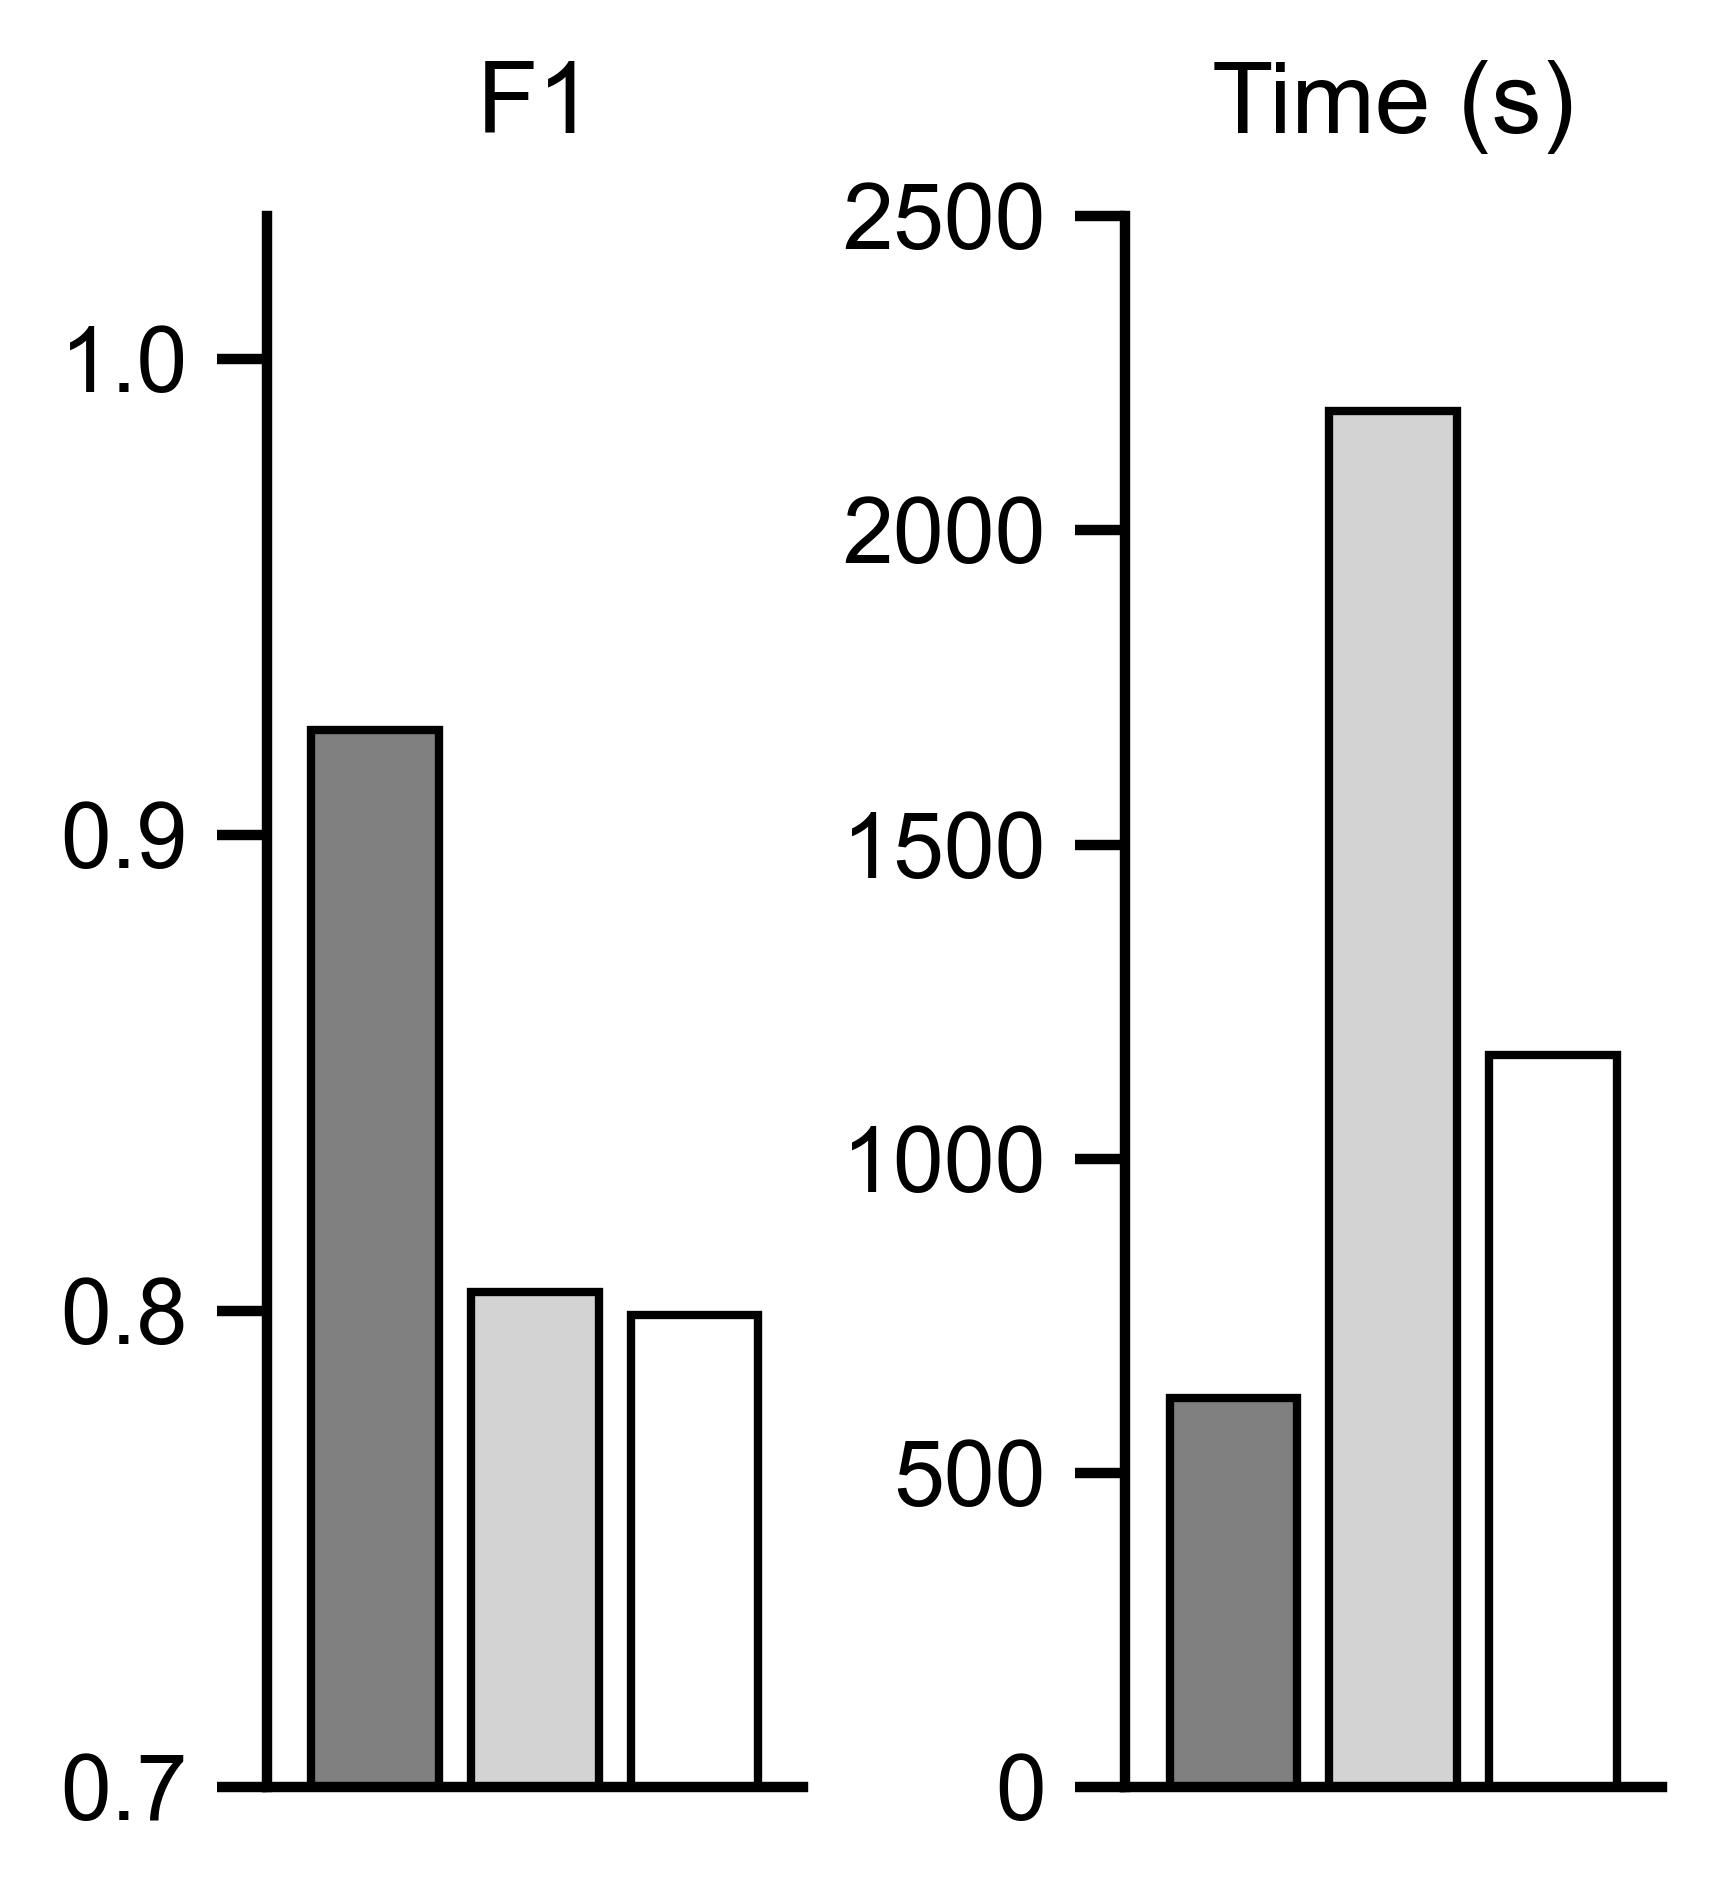

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "zebrafish_results_trained.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
metrics = ["f1", "total_time"]
method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)                    
agg = results.groupby("method")[metrics].agg(["mean", "std"])

x = np.arange(len(methods))          # one group center per method
color =  "black"

fig, axes = plt.subplots(
    figsize=(3, 3.4),
    dpi=600,
    ncols=2,
    gridspec_kw={"width_ratios": [1,1], "wspace": 0.6},
)


for i, metric in enumerate(metrics):
        means = [agg.loc[m, (metric, "mean")] for m in methods]
        sds   = [agg.loc[m, (metric, "std")]  for m in methods]
        axes[i].bar(x=methods, height=means, capsize=4, linewidth=1,
                label="Time", color=[method_colors[m] for m in methods], edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars

        axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        axes[i].set_xticklabels("")
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)

        axes[i].tick_params(left=True, bottom=False) 
        axes[i].tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
        axes[i].margins(x=0.1)
        axes[i].set_ylabel("")

        nuclogic_values = results[results["method"] == "NucLogic"][metric]
        cellpose_values = results[results["method"] == "Cellpose 4"][metric]
        usegment_values = results[results["method"] == "u-Segment3D"][metric]
        star_values = results[results["method"] == "StarDist"][metric]
     
        if i == 0:
                axes[i].set_title("F1", pad=10)
                axes[i].set_ylim(0.7, 1.03)
                axes[i].yaxis.set_major_locator(MaxNLocator(nbins=4))
        else:
                axes[i].set_title("Time (s)", pad=10)
                axes[i].set_ylim(0, 2500)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "zebrafish_results_full.eps"), dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)
colormap_seg = {0: '', 1: 'green', 2: 'magenta', 3: 'cyan'}

names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
dir = os.path.join(base_directory, names[0])
image = tifffile.imread(os.path.join(dir, "data.tif"))
ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))

# def color_mask(mask, gt, tp_list, fp_list, fn_list):
#     # mask-based classes (tp=1, fp=2)
#     lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
#     lut[np.asarray(tp_list, dtype=int)] = 1
#     lut[np.asarray(fp_list, dtype=int)] = 2
#     colored = lut[mask]

#     # fn comes from gt, painted on top
#     fn_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
#     fn_lut[np.asarray(fn_list, dtype=int)] = 3
#     colored[fn_lut[gt] == 3] = 3
#     return colored

# nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
# nuclogic_colored = color_mask(nuclogic, ground_truth, nuclogic_results["tp_list"], nuclogic_results["fp_list"], nuclogic_results["fn_list"])
# cp4_results = (centroid_accuracy(ground_truth, cp4))
# cp4_colored = color_mask(cp4, ground_truth, cp4_results["tp_list"], cp4_results["fp_list"], cp4_results["fn_list"])

viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "zebrafish_data.png"), size=(2160, 3840), canvas_only=True, scale = 1.2)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (24.796264343669097, 237.4340231835281, 402.7615460461847)
viewer.camera.angles = (179.77222044782297, -0.3018545374737001, 1.8301771723984743)
viewer.camera.zoom   = 10.457644595201812
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "zebrafish_zoomed.png"), size=(2160, 3840), canvas_only=True, scale = 1.3)

Emmanuel zebrafish

In [ ]:
import napari
import nrrd
import numpy as np


image, header = nrrd.read(r"C:\Users\6331823\Local SSD\EML_zebrafish\MF59_r0c3.nrrd")
image = np.transpose(image, (2, 1, 0))  # transpose to ZYX order
seg, header = nrrd.read(r"C:\Users\6331823\Local SSD\EML_zebrafish\MF59_masks_crop.nrrd")
seg = np.transpose(seg, (2, 1, 0))  # transpose to ZYX order

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image, scale=(0.43, 0.23, 0.23))
viewer.add_labels(seg, scale=(0.43, 0.23, 0.23), iso_gradient_mode="smooth", opacity=1)
# random_indices = np.random.choice(image.shape[0], size=10, replace=False)
# for index in random_indices:
#     slice = image[index, :, :]
#     tifffile.imwrite(os.path.join(r"C:\Users\6331823\Local SSD\EML_zebrafish\model", f"slice_{index}.tif"), slice, compression="zlib", compressionargs={"level": 8})


<Labels layer 'seg' at 0x2410f6e4890>

In [3]:
import nrrd
import numpy as np
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import pandas as pd
import tifffile
from skimage.transform import resize
from scipy import ndimage

input_directory = r"C:\Users\6331823\Local SSD\EML_zebrafish"
names = ["MF59_r0c3.nrrd"]

scale = (0.43, 0.23, 0.23)  # in micrometers



model = load_model(
    os.path.join(input_directory, "model","models", "zebrafish_lightsheet")
)

results = []
for name in names:
    image, header = nrrd.read(os.path.join(input_directory, name))
    image = np.transpose(image, (2, 1, 0))  # transpose to ZYX order
    image = ndimage.zoom(image, 0.25, order=0)

    start_time = time.time()
    mask = segment(image, model)
    tifffile.imwrite(
        os.path.join(input_directory, "2d_segmented_rescaled.tif"),
        mask,
        compression="zlib",
        compressionargs={"level": 8},
    )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_rescaled.tif"))
    segmentation_time = time.time() - start_time


    start_stitch_time = time.time()
    nuclogic = stitch_3d(
        mask,
        image,
        image_type_1="wt",
        breaking_threshold=2,
        scale=scale
    )
    end_time = time.time()
    nuclogic_time = end_time - start_time
    nuclogic_cellpose_time = start_stitch_time - start_time
    nuclogic_stitch_time = end_time - start_stitch_time

    ground_truth, header = nrrd.read(
        os.path.join(input_directory, "MF59_masks_crop.nrrd")
    )
    ground_truth = np.transpose(ground_truth, (2, 1, 0))  # transpose to ZYX order
    nuclogic = resize(nuclogic, ground_truth.shape, order=0)  # rescale back to original size
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_nuclogic_rescaled.tif"),
        nuclogic,
        compression="zlib",
        compressionargs={"level": 8},
    )
    nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_rescaled.tif"))

    nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    print(f"centroid accuracy: {nuclogic_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    )

    print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")


    start_cp4 = time.time()
    cp4,_,_ = model.eval(
                    image,
                    diameter=None,
                    normalize=True,
                    flow3D_smooth=0.4,
                    invert=False,
                    resample=True,
                    do_3D=True,
                    z_axis=0,
                    min_size=150,
                    progress=True,
                )
    end_cp4 = time.time()
    cp4_time = end_cp4 - start_cp4

    cp4 = resize(cp4, ground_truth.shape, order=0)  # rescale back to original size
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_cp4_rescaled.tif"),
        cp4,
        compression="zlib",
        compressionargs={"level": 8},
    )

    cp4_results = (centroid_accuracy(ground_truth, cp4))
    print(f"centroid accuracy: {cp4_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    )
    print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # save results of centroid accuracy and amount of cells to a tsv file

    results_df = pd.DataFrame(
        {
            "method": ["nuclogic", "cellpose4"],
            "f1": [nuclogic_results["f1"], cp4_results["f1"]],
            "precision": [nuclogic_results["precision"], cp4_results["precision"]],
            "recall": [nuclogic_results["recall"], cp4_results["recall"]],
            "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
            "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
            "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
            "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
            "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
            "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
            "total_time": [nuclogic_time, cp4_time],
            "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
            "stitching_time": [nuclogic_stitch_time, 0],
        }
    )
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results_df.to_csv(os.path.join(output_directory, "emmanuel_results_rescaled.tsv"), sep="\t", index=False)

Using CUDA for processing.
loaded custom model: zebrafish_lightsheet
Starting 3D stitching process...
Created 58118 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 5141 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 2384 breaks.
    Iteration 2: Made 1853 breaks.
    Iteration 3: Made 1097 breaks.
    Iteration 4: Made 484 breaks.
    Iteration 5: Made 155 breaks.
    Iteration 6: Made 45 breaks.
    Iteration 7: Made 7 breaks.
    Iteration 8: Made 1 breaks.
    Iteration 9: Made 1 breaks.
Finding touching cell pairs...
Found 20059 pairs of touching cells.
Splitted 11147 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 141 small cells, and removed 360 cells without suitable neighbors.
Final stitched mask has 10667 cells.
centroid accuracy: {'true_positives': 9228, 'false_negatives': 1292, 'false_positives': 1439, 'merged_cells': 1010, 'precision': 0.86

In [2]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.centroid_accuracy import centroid_accuracy
from utils.stitch_3d import stitch_3d
from scipy import ndimage
import nrrd
import numpy as np
# from utils.load_model import load_model
from skimage.transform import resize
import tifffile
import time
import pandas as pd

input_directory = r"C:\Users\6331823\Local SSD\EML_zebrafish"

name = "MF59_r0c3_2"

# image_normal, header = nrrd.read(os.path.join(input_directory, f"{name}.nrrd"))
# image_normal = np.transpose(image_normal, (2, 1, 0))  # transpose to ZYX order
# image_zoomed = ndimage.zoom(image_normal, 0.25, order=0)

# def degrade_image(image, bottom=0.05):
#     depth = np.linspace(0.0, 1.0, image.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
#     sqrt_part = 1.0 - (1.0 - bottom) * np.sqrt(depth)
#     d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
#     sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
#     factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
#     z_profile = (sqrt_part * factor)[:, None, None]
#     image_degraded = image * z_profile
#     return image_degraded

# image_degraded = degrade_image(image_zoomed, bottom=0.05)
# image_degraded = resize(image_degraded, image_normal.shape, order=1)  # rescale to zoomed size
# tifffile.imwrite(os.path.join(input_directory, f"{name}_degraded.tif"), image_degraded, compression="zlib", compressionargs={"level": 8})
# image_degraded = tifffile.imread(os.path.join(input_directory, f"{name}_degraded.tif"))

# images = [image_degraded]
# gt , header = nrrd.read(os.path.join(input_directory, "MF59_masks_crop_2.nrrd"))
# gt = np.transpose(gt, (2, 1, 0))  # transpose to ZYX order
gt = tifffile.imread(os.path.join(input_directory, f"MF59_r0c3_2_3d_segmented_cp4.tif")).astype(np.uint16)
# model = load_model(
#     os.path.join(input_directory, "model", "models", "zebrafish_lightsheet")
# )

# for image in images:
    # if image.shape != gt.shape:
extra_name = "_degraded"
sample_name = f"{name}_degraded"
# else:
#     extra_name = ""
#     sample_name = name
print(f"Processing {sample_name}...")
# del image
# start_nuclogic_cp = time.time()
# segmented_2d = segment(image, model)
# end_nuclogic_cp = time.time()
# nuclogic_cp_time = end_nuclogic_cp - start_nuclogic_cp
# tifffile.imwrite(
#     os.path.join(input_directory, f"{name}_2d_segmented{extra_name}.tif"),
#     segmented_2d,
#     compression="zlib",
#     compressionargs={"level": 8},
# )
# segmented_2d = tifffile.imread(os.path.join(input_directory, f"{name}_2d_segmented.tif"))
# segmented_2d = resize(segmented_2d, image.shape, order=0)  # rescale back to original size

# scale = (0.83, 0.46, 0.46)  # in micrometers
# nuclogic_start_stitch_time = time.time()
# nuclogic_3d = stitch_3d(segmented_2d,   
#         image,
#         image_type_1="wt",
#         breaking_threshold=2,
#         scale=scale
#     )
# end_nuclogic_stitch = time.time()
# nuclogic_stitch_time = end_nuclogic_stitch - nuclogic_start_stitch_time
# print(f"Nuclogic stitching time: {nuclogic_stitch_time:.2f} seconds")
# # nuclogic_time = end_nuclogic_stitch - start_nuclogic_cp

# if image.shape != gt.shape:
#     nuclogic_3d = resize(nuclogic_3d, (gt.shape[0], gt.shape[1], gt.shape[2]), order=0)

# tifffile.imwrite(
#     os.path.join(input_directory, f"{name}_3d_segmented_nuclogic{extra_name}.tif"),
#     nuclogic_3d,
#     compression="zlib",
#     compressionargs={"level": 8},
# )
nuclogic_3d = tifffile.imread(os.path.join(input_directory, f"{name}_3d_segmented_nuclogic{extra_name}.tif")).astype(np.uint16)

print("Starting centroid accuracy")
nuclogic_results = centroid_accuracy(gt, nuclogic_3d)
#     print(f"Nuclogic time: {nuclogic_time:.2f} seconds")
print(f"Nuclogic time Nuclogic results: {nuclogic_results}")
predicted_cells_nuclogic = len(np.unique(nuclogic_3d)) - 1
#     #remove nuclogic out of memory
del nuclogic_3d

#     start_usegment = time.time()
#     usegment = usegment_stitch(segmented_2d)
#     end_usegment = time.time()
#     usegment_time = end_usegment - start_usegment
#     if image.shape != gt.shape:
#         usegment = resize(usegment, (gt.shape[0], gt.shape[1], gt.shape[2]), order=0)

#     tifffile.imwrite(
#         os.path.join(input_directory, f"{name}_3d_segmented_usegment{extra_name}.tif"),
#         usegment,
#         compression="zlib",
#         compressionargs={"level": 8},
#     )
usegment = tifffile.imread(os.path.join(input_directory, f"{name}_3d_segmented_usegment{extra_name}.tif")).astype(np.uint16)
usegment_results = centroid_accuracy(gt, usegment)
# print(f"u-Segment3D time: {usegment_time:.2f} seconds")
print(f"u-Segment3D results: {usegment_results}")
predicted_cells_usegment = len(np.unique(usegment)) - 1
del usegment
#     del segmented_2d

#     start_cp4 = time.time()
#     cp4,_,_ = model.eval(
#                     image,
#                     diameter=None,
#                     normalize=True,
#                     flow3D_smooth=0.4,
#                     resample=True,
#                     do_3D=True,
#                     z_axis=0,
#                     min_size=150,
#                     progress=True,
#                 )
#     end_cp4 = time.time()
#     cp4_time = end_cp4 - start_cp4

#     if image.shape != gt.shape:
#         cp4 = resize(cp4, (gt.shape[0], gt.shape[1], gt.shape[2]), order=0)
#     tifffile.imwrite(
#         os.path.join(input_directory, f"{name}_3d_segmented_cp4{extra_name}.tif"),
#         cp4,
#         compression="zlib",
#         compressionargs={"level": 8},
#     )
cp4 = tifffile.imread(os.path.join(input_directory, f"{name}_3d_segmented_cp4{extra_name}.tif")).astype(np.uint16)
cp4_results = centroid_accuracy(gt, cp4)
#     print(f"Cellpose 4 time: {cp4_time:.2f} seconds")
predicted_cells_cp4 = len(np.unique(cp4)) - 1
del cp4
print(f"Cellpose 4 results: {cp4_results}")

actual_cells = len(np.unique(gt)) - 1

results_df = pd.DataFrame(
    {
        "method": ["nuclogic", "cellpose4", "usegment3d"],
        "f1": [nuclogic_results["f1"], cp4_results["f1"], usegment_results["f1"]],
        "precision": [nuclogic_results["precision"], cp4_results["precision"], usegment_results["precision"]],
        "recall": [nuclogic_results["recall"], cp4_results["recall"], usegment_results["recall"]],
        "actual_cells": [actual_cells, actual_cells, actual_cells],
        "predicted_cells": [predicted_cells_nuclogic, predicted_cells_cp4, predicted_cells_usegment],
        "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"], usegment_results["true_positives"]],
        "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"], usegment_results["false_positives"]],
        "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"], usegment_results["false_negatives"]],
        "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"], usegment_results["merged_cells"]],
        # "total_time": [nuclogic_time, cp4_time, usegment_time],
        # "nuclogic_2d_time": [nuclogic_cellpose_time, 0, 0],
        # "stitching_time": [nuclogic_stitch_time, 0, 0],
    }
)
results_df.insert(0, "sample", name) 

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results_df.to_csv(os.path.join(output_directory, "emmanuel_results_cp_2.tsv"), sep="\t", index=False)

Processing MF59_r0c3_2_degraded...
Starting centroid accuracy
Nuclogic time Nuclogic results: {'true_positives': 38418, 'false_negatives': 5983, 'false_positives': 1151, 'merged_cells': 3439, 'precision': 0.9709115721903511, 'recall': 0.8652507826400306, 'f1': 0.9150410861021794, 'voxel_dice': 0.9251202447879949, 'tp_list': [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77, 78, 79, 80, 81, 82, 83, 84, 86, 87, 88, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 104, 105, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 138, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149, 150, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,

In [ ]:
import napari
import os
import tifffile
import nrrd
import numpy as np
from napari.utils.colormaps import colormap_utils as cu
from skimage.transform import resize
from scipy import ndimage
colormap = cu.label_colormap(num_colors=1024)

input_directory = r"C:\Users\6331823\Local SSD\EML_zebrafish"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"

image, header = nrrd.read(os.path.join(input_directory, "MF59_r0c3_2.nrrd"))
image = np.transpose(image, (2, 1, 0)) # transpose to ZYX orde
shapes = image.shape
image = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_degraded.tif"))
gt , header = nrrd.read(os.path.join(input_directory, "MF59_masks_crop_2.nrrd"))
# image = ndimage.zoom(image, 0.25, order=0)  # downsample for faster visualization
image = resize(image, (shapes[0], shapes[1], shapes[2]), order=0)  # upsample again
xy_25 = slice(0, image.shape[1] // 4)
xy_8 = slice(0, image.shape[1] // 12)
image = image[:, xy_25, :]
gt = np.transpose(gt, (2, 1, 0)).astype(np.uint16)  # transpose to ZYX order
# gt = ndimage.zoom(gt, 0.25, order=0)  # downsample for faster visualization
# gt = resize(gt, (shapes[0], shapes[1], shapes[2]), order=0).astype(np.uint16)  # upsample again
gt = gt[:, xy_25, :]
# nuclogic = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_3d_segmented_nuclogic.tif")).astype(np.uint16)
nuclogic = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_3d_segmented_nuclogic_degraded.tif")).astype(np.uint16)
nuclogic = nuclogic[:, xy_25, :]
# cp4 = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_3d_segmented_cp4.tif")).astype(np.uint16)
cp4 = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_3d_segmented_cp4_degraded.tif")).astype(np.uint16)
cp4 = cp4[:, xy_25, :]

# scale = (0.43, 0.23, 0.23)  # in micrometers
# viewer = napari.Viewer(ndisplay=2)
# # viewer.add_image(image, scale=scale) #contrast_limits=(0, 600) for degraded
# viewer.add_image(image, scale=scale, contrast_limits=(0, 600)) #contrast_limits=(0, 600) for degraded
# viewer.add_labels(gt, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(cp4, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.reset_view()
# # move to z 594
# viewer.dims.set_point(0, 575 * scale[0]) 
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# viewer.grid.enabled = True
# viewer.camera.zoom  = 3
# napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "emmanuel_degraded_slice.png"), size=(2160, 3840), canvas_only=True, scale = 1)

scale = (0.43, 0.23, 0.23)  # in micrometers
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image[:, xy_8, :], scale=scale) #contrast_limits=(0, 600) for degraded
viewer.add_labels(gt[:, xy_8, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(nuclogic[:, xy_8, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(cp4[:, xy_8, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.grid.enabled = True
viewer.camera.zoom   = 1.3

napari.run()
viewer.screenshot(path=os.path.join(output_directory, "emmanuel_degraded_2.png"), size=(2160, 3840), canvas_only=True, scale = 1)

# viewer.camera.center = (255.82705268500638, 48.530579166199146, 251.23925045414418)
# viewer.camera.angles = (180.0, 0.0, 0.0)
# viewer.camera.zoom = 5
# # # Reset view to the data bounds, then set a side-view camera angle (XZ view)
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# viewer.screenshot(path=os.path.join(output_directory, "emmanuel_normal_zoomed.png"), size=(2160, 3840), canvas_only=True, scale = 1)



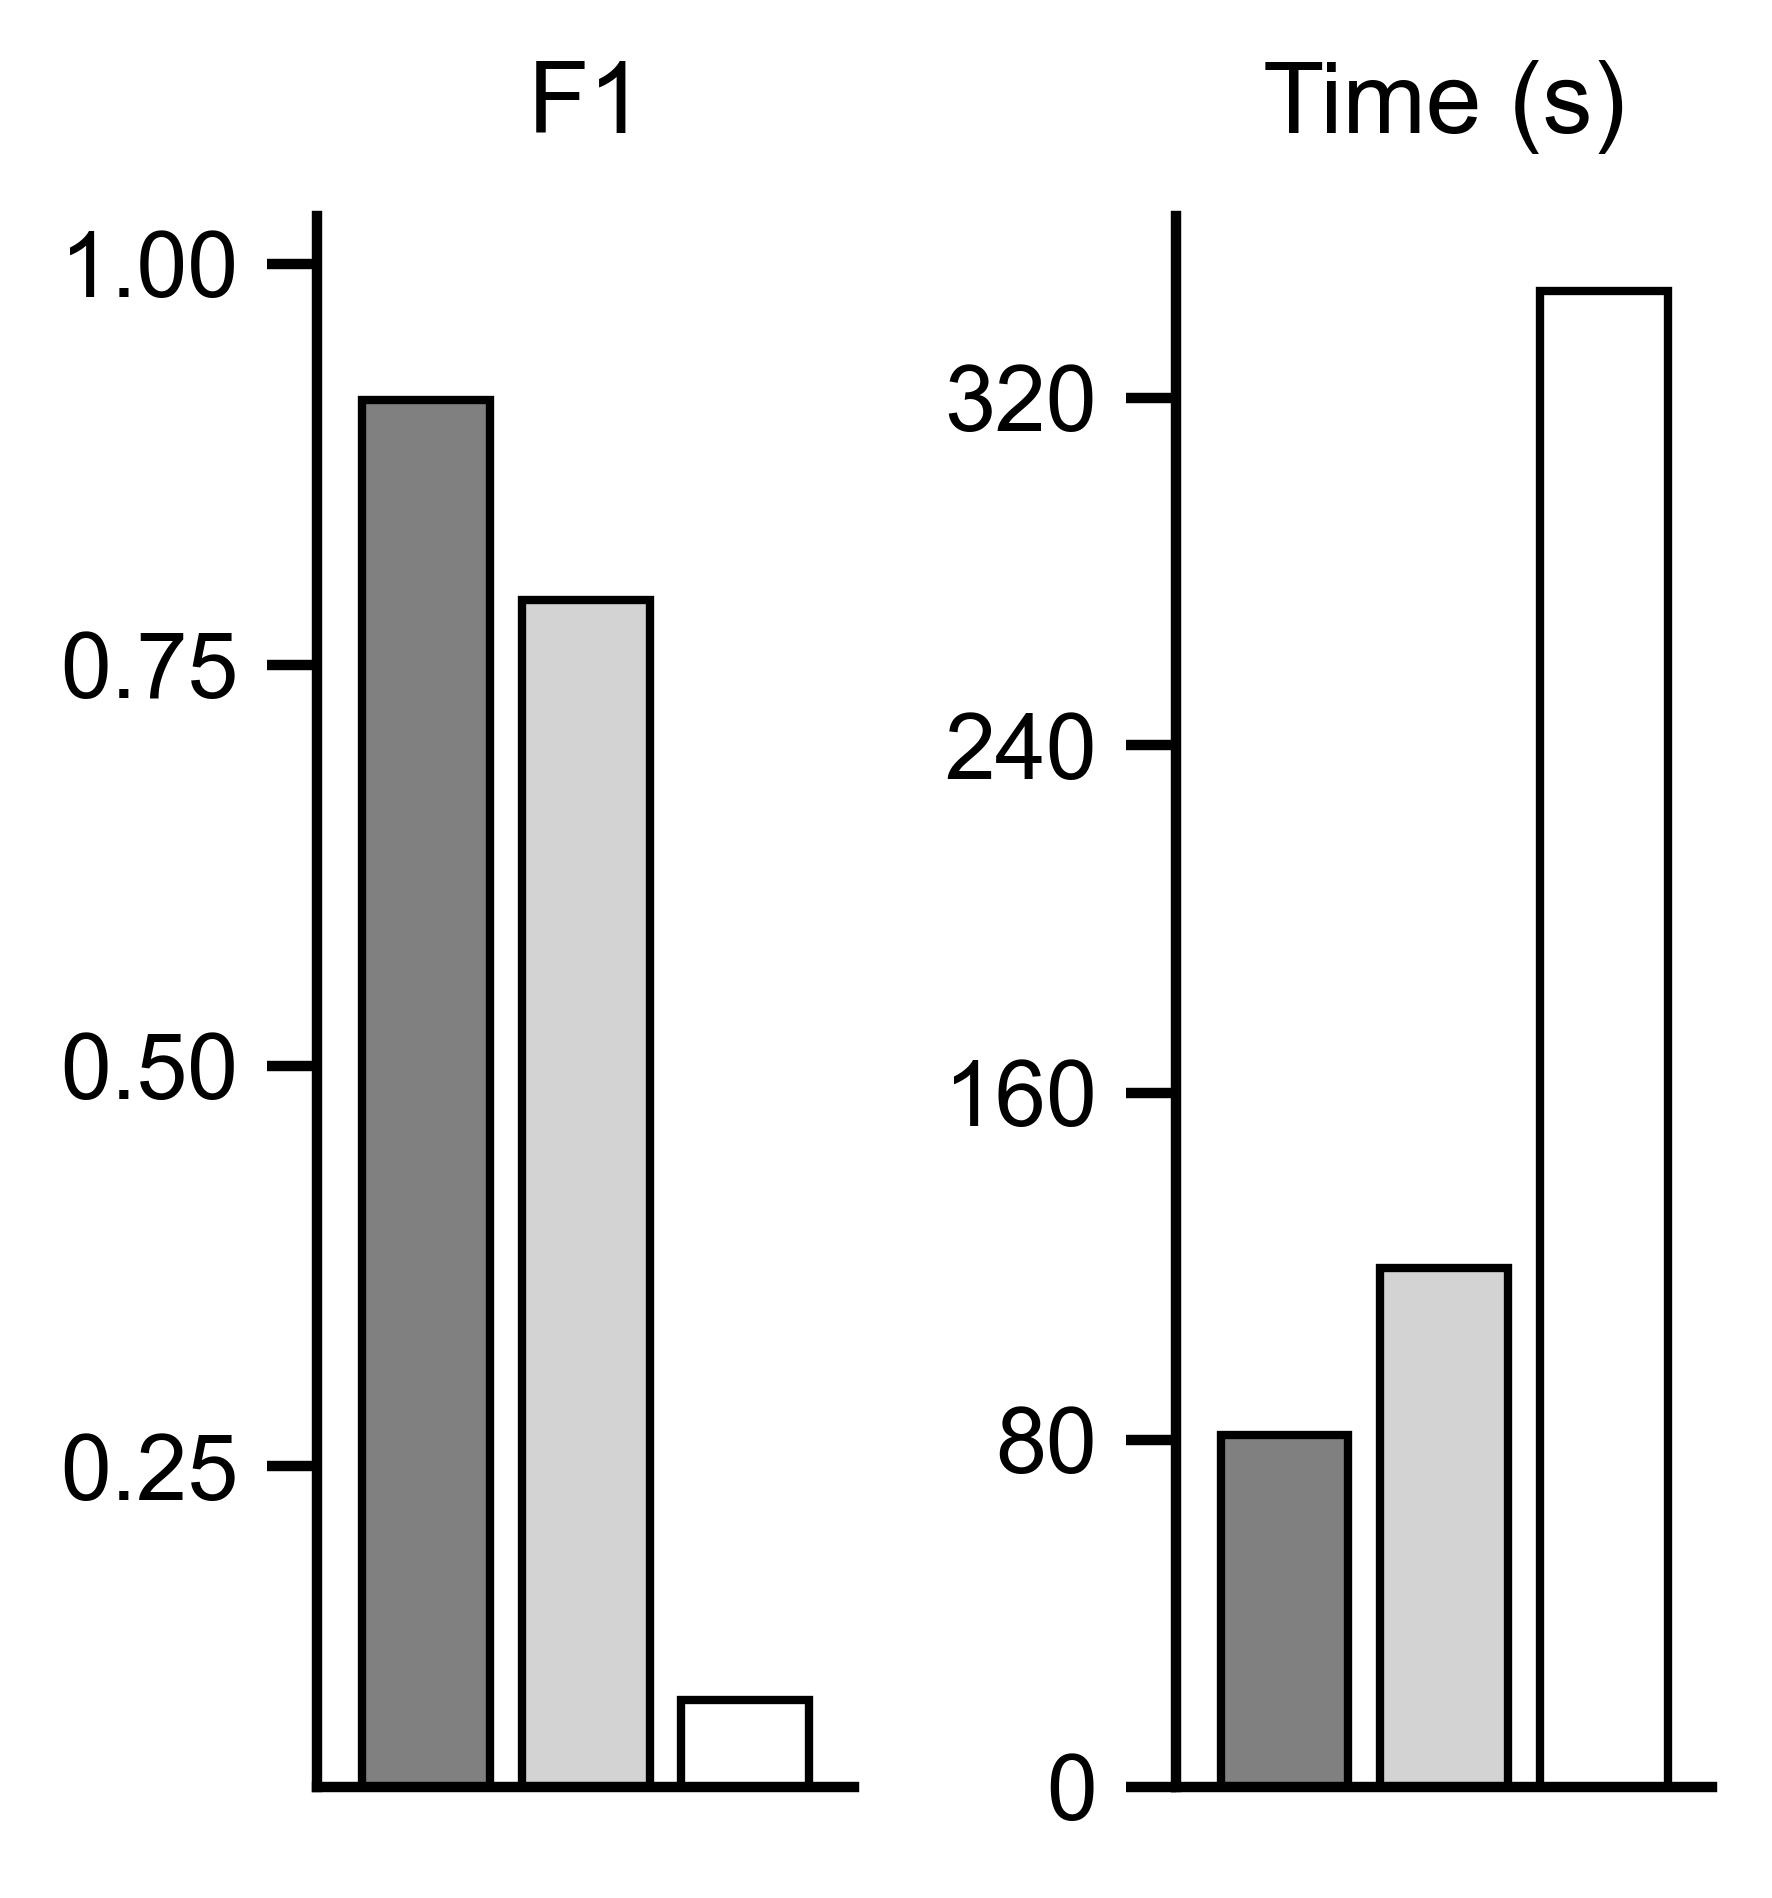

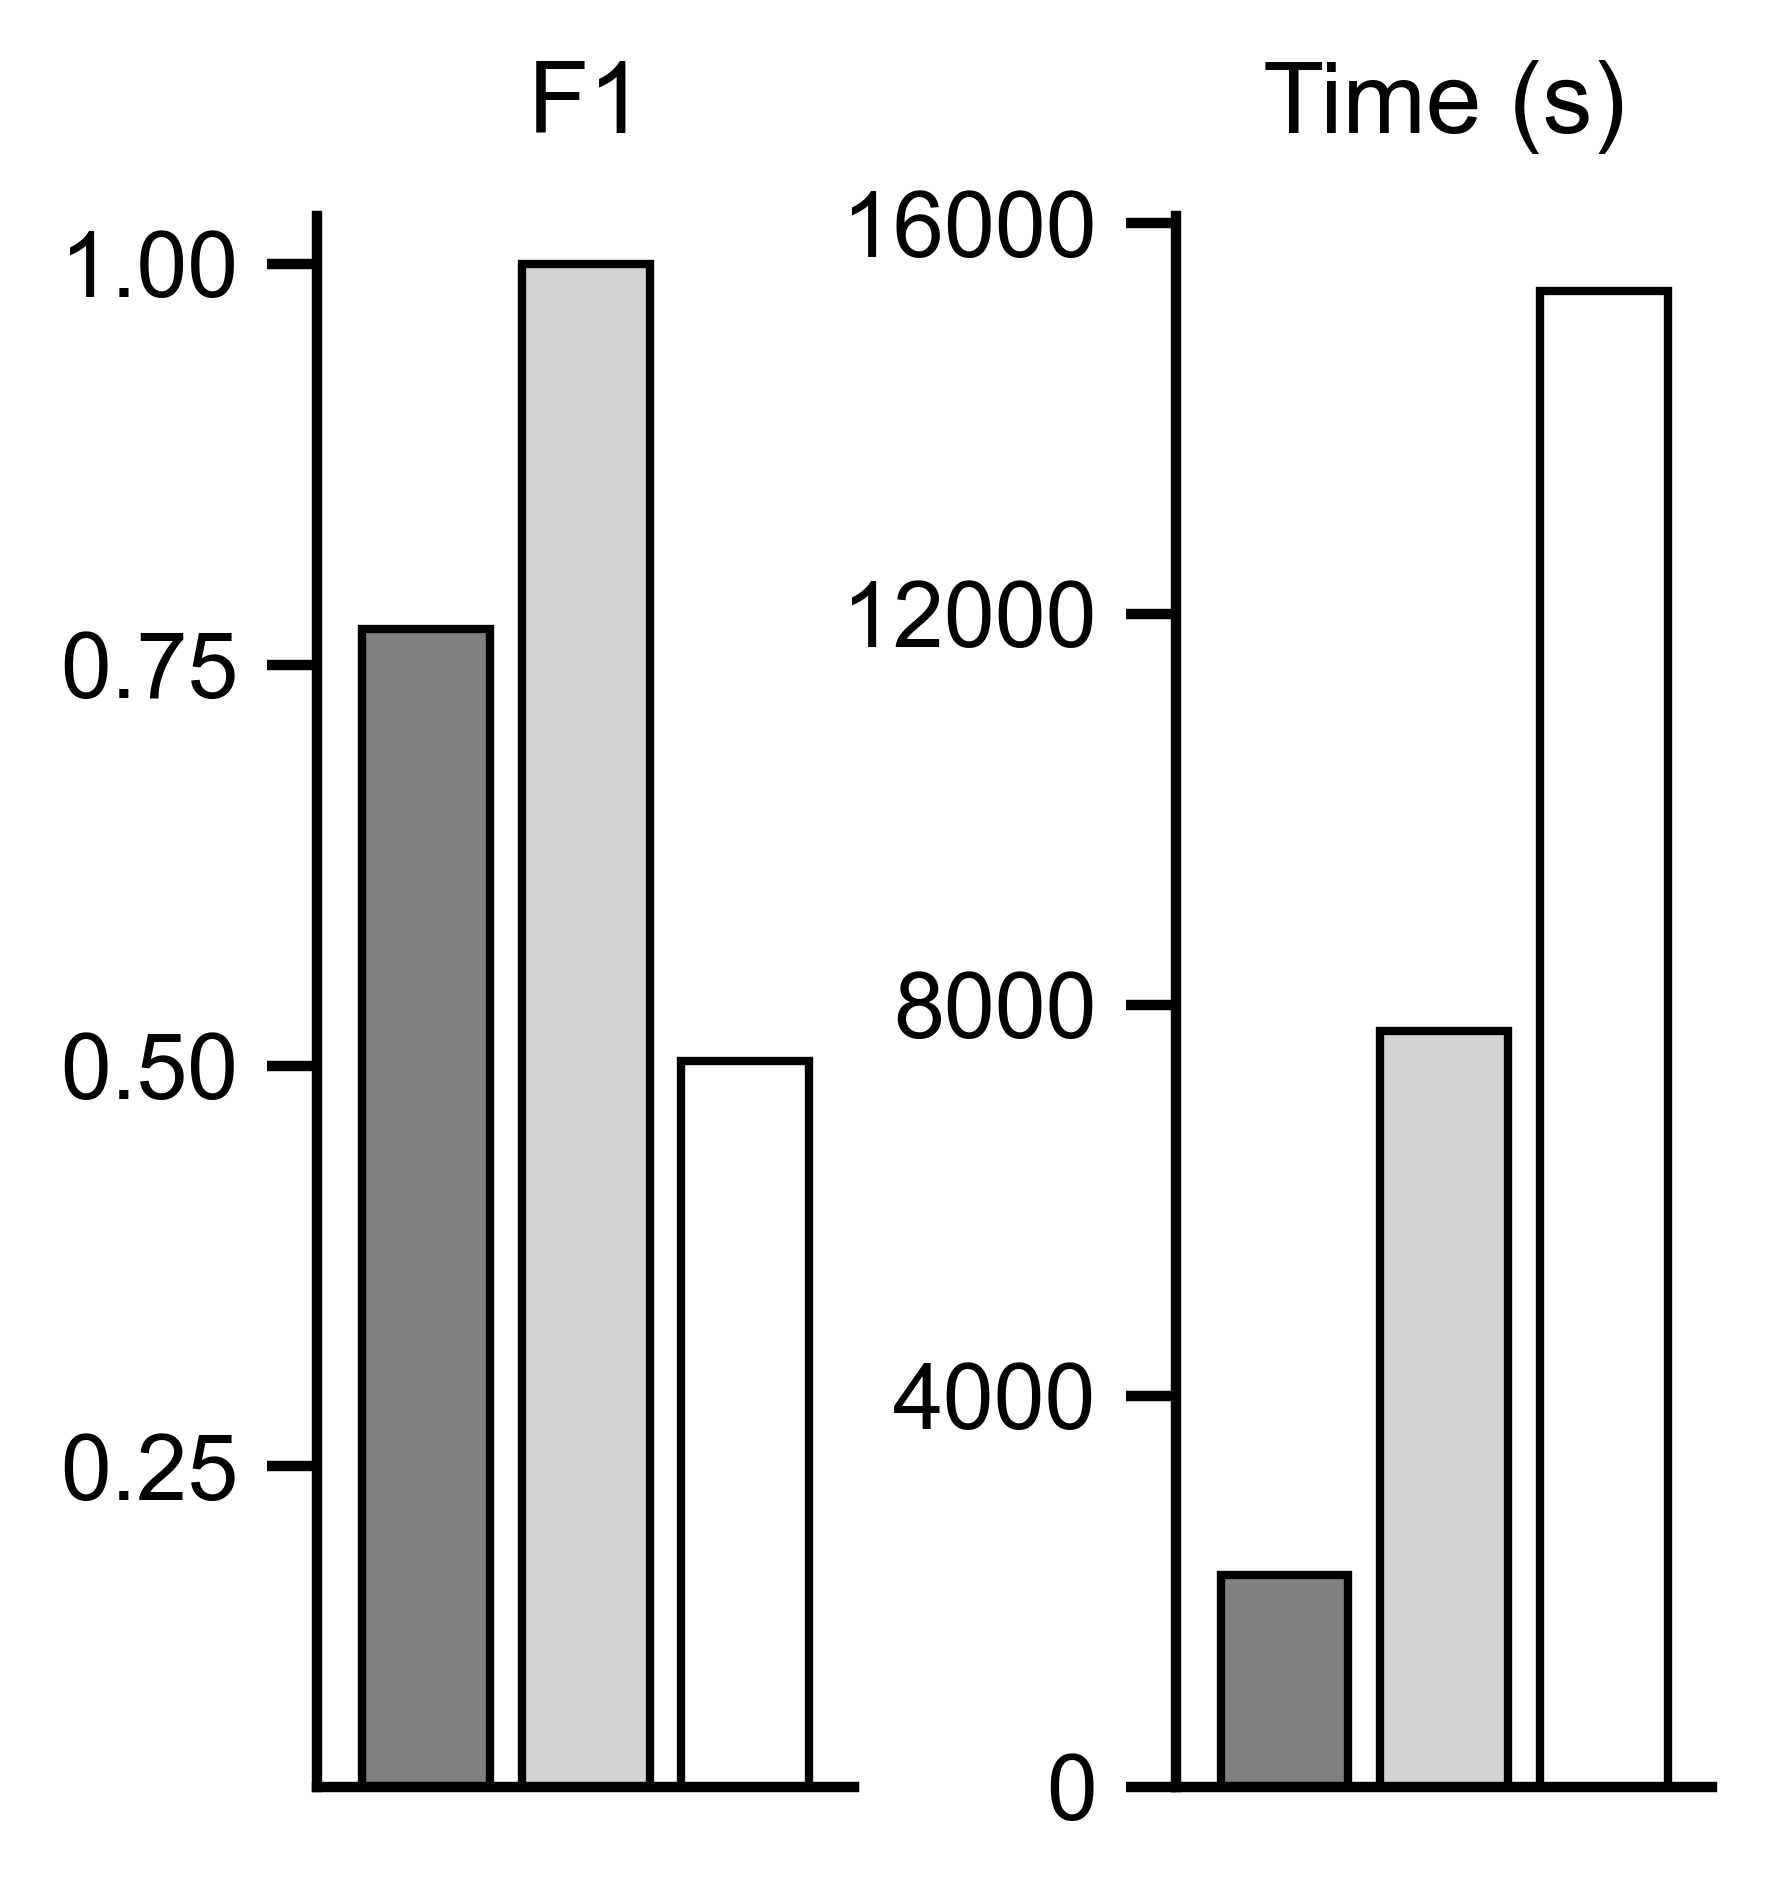

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "emmanuel_results_cp.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
metrics = ["f1", "total_time"]
method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  
# 
for sample in results["sample"].unique():
    sample_results = results[results["sample"] == sample]                  
    agg = sample_results.groupby("method")[metrics].agg(["mean", "std"])

    x = np.arange(len(methods))          # one group center per method
    color =  "black"

    fig, axes = plt.subplots(
        figsize=(3, 3.4),
        dpi=600,
        ncols=2,
        gridspec_kw={"width_ratios": [1,1], "wspace": 0.6},
    )


    for i, metric in enumerate(metrics):
            means = [agg.loc[m, (metric, "mean")] for m in methods]
            sds   = [agg.loc[m, (metric, "std")]  for m in methods]
            axes[i].bar(x=methods, height=means, capsize=4, linewidth=1,
                    label="Time", color=[method_colors[m] for m in methods], edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars

            axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
            axes[i].set_xticklabels("")
            axes[i].spines["top"].set_visible(False)
            axes[i].spines["right"].set_visible(False)

            axes[i].tick_params(left=True, bottom=False) 
            axes[i].tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
            axes[i].margins(x=0.1)
            axes[i].set_ylabel("")

        
            if i == 0:
                    axes[i].set_title("F1", pad=10)
                    axes[i].set_ylim(0.05, 1.03)
                    axes[i].yaxis.set_major_locator(MaxNLocator(nbins=4))
            else:
                    axes[i].set_title("Time (s)", pad=10)
                    # axes[i].set_ylim(0, 2500)

    figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
    plt.savefig(os.path.join(figure_folder, f"emmanuel_{sample}.eps"), dpi=600, bbox_inches="tight")
    plt.show()

# Figure 4

In [ ]:
# Small intestine cell type identification



In [ ]:
# Anna data TL of hepatocyte organoids with crc cells
import os
import tifffile
import napari
from napari.utils.colormaps import colormap_utils as cu
from napari.components._viewer_constants import CanvasPosition
import numpy as np
colormap = cu.label_colormap(num_colors=1024)
input_directory = r"E:\Data Hussein\E-133_S-61_O-1"

movie = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_cropped.tif"))
segmentation = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_segmented.tif"))
wt_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_wt_mask.tif"))
crc_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_crc_mask.tif"))
wt_mask = np.where(wt_mask > 0, 1, 0)
crc_mask = np.where(crc_mask > 0, 1, 0)
dapi = movie[:,:,0]
d2 = movie[:,:,1]
mTmG = movie[:,:,2]
dapi_contrast = (5, np.percentile(dapi, 99.99))
d2_contrast = (5, np.percentile(d2, 99.99))
mTmG_contrast = (np.median(mTmG)*1.2, np.percentile(mTmG, 99.99))

viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)

viewer.add_image(dapi, name = "DAPI", scale=scale, colormap="blue", blending="additive", contrast_limits=dapi_contrast)
viewer.add_image(d2, name = "D2", scale=scale, colormap="green",blending="additive", contrast_limits=d2_contrast)
viewer.add_image(mTmG, name = "mTmG", scale=scale, colormap="magenta", blending="additive", contrast_limits=mTmG_contrast)
viewer.add_labels(segmentation, name = "Segmentation", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap, blending="additive")
viewer.add_labels(crc_mask, name = "CRC mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap={1:"green"}, blending="translucent")
viewer.add_labels(wt_mask, name = "WT mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap={1:"magenta"}, blending="translucent")

viewer.reset_view()
def update_slider(event):
    time = viewer.dims.current_step[0]
    viewer.text_overlay.text = f"{time*5:1f} time"

viewer.text_overlay.visible = True
viewer.text_overlay.position = CanvasPosition.BOTTOM_CENTER
viewer.text_overlay.color = "white"
viewer.text_overlay.font_size = 24
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.dims.events.current_step.connect(update_slider)
viewer.grid.enabled = True
viewer.camera.angles = (180, 0, 0)
viewer.dims.set_point(0, 12)  # move to timepoint 12

# viewer.camera.center = (255.82705268500638, 48.530579166199146, 251.23925045414418)
# viewer.camera.angles = (180.0, 0.0, 0.0)
viewer.camera.zoom = 1.5
# # # Reset view to the data bounds, then set a side-view camera angle (XZ view)
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
viewer.screenshot(path=os.path.join(output_directory, "anna_tl_channels.png"), size=(2160, 3840), canvas_only=True, scale = 1)

viewer.layers["DAPI"].visible = False
viewer.layers["D2"].visible = False
viewer.layers["mTmG"].visible = False
viewer.layers["Segmentation"].visible = False
viewer.grid.enabled = False
viewer.camera.zoom = 2
for timepoint in [0,4, 8,12]:
    viewer.dims.set_point(0, timepoint)  # move to timepoint 12
    viewer.screenshot(path=os.path.join(output_directory, f"anna_tl_combined_{timepoint}.png"), size=(2160, 3840), canvas_only=True, scale = 1)

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default colo

In [58]:
import pandas as pd

# Plots of A
data = pd.read_csv(r"E:\Extra analysis for Hossein\70h_cell_data.tsv", sep="\t")

position_table = pd.read_csv(
    r"C:\Users\6331823\Downloads\hussein_positions.csv"
)

def _clean_series_to_list(series: pd.Series) -> list[str]:
    cleaned = series.dropna().astype(str).str.strip()
    return [value for value in cleaned if value]

wt_pure = _clean_series_to_list(position_table["WT pure"])
mixed = _clean_series_to_list(position_table["WT Mix"])
crc_pure = _clean_series_to_list(position_table["Cancer pure"])

# check for every row if the sample column is in wt_pure, mixed, or crc_pure and create a new column sample_type with values "WT pure", "Mix, or "CRC pure"
def determine_sample_type(sample):
    if sample in wt_pure:
        return "WT pure"
    elif sample in mixed:
        return "Mixed"
    elif sample in crc_pure:
        return "CRC pure"
    else:
        return "Unknown"
    
data["sample_type"] = data["sample"].apply(determine_sample_type)
data["time"] = data["time"].astype(int)
import numpy as np

# Counts per sample/time
wt_counts = (
    data[data["phenotype_crc_vs_wt"].str.lower().eq("wt")]
    .groupby(["sample", "time"], as_index=False)
    .size()
    .rename(columns={"size": "wt_cells"})
)

crc_counts = (
    data[data["phenotype_crc_vs_wt"].str.lower().eq("crc")]
    .groupby(["sample", "time"], as_index=False)
    .size()
    .rename(columns={"size": "crc_cells"})
)

total_counts = (
    data.groupby(["sample", "time"], as_index=False)
    .size()
    .rename(columns={"size": "total_cells"})
)

# Merge by keys (sample + time), not by index
summary_df = total_counts.merge(wt_counts, on=["sample", "time"], how="left").merge(
    crc_counts, on=["sample", "time"], how="left"
)

summary_df["wt_cells"] = summary_df["wt_cells"].fillna(0).astype(int)
summary_df["crc_cells"] = summary_df["crc_cells"].fillna(0).astype(int)

# Baseline at t=0 per sample
t0 = summary_df[summary_df["time"] == 0][
    ["sample", "total_cells", "wt_cells", "crc_cells"]
].rename(
    columns={
        "total_cells": "total_cells_t0",
        "wt_cells": "wt_cells_t0",
        "crc_cells": "crc_cells_t0",
    }
)

summary_df = summary_df.merge(t0, on="sample", how="left")

# Relative growth per sample (vs each sample's own t=0)
summary_df["relative_growth_total"] = summary_df["total_cells"] / summary_df[
    "total_cells_t0"
].replace(0, np.nan)
summary_df["relative_growth_wt"] = summary_df["wt_cells"] / summary_df[
    "wt_cells_t0"
].replace(0, np.nan)
summary_df["relative_growth_crc"] = summary_df["crc_cells"] / summary_df[
    "crc_cells_t0"
].replace(0, np.nan)

summary_df["sample_type"] = summary_df["sample"].apply(determine_sample_type)

#remove unnecessary columns
summary_df = summary_df.drop(columns=["total_cells_t0", "wt_cells_t0", "crc_cells_t0"])

# Move sample_type column to the front
cols = summary_df.columns.tolist()
cols.insert(0, cols.pop(cols.index("sample_type")))
summary_df = summary_df[cols]

print(summary_df.head())

summary = []
full_data = []
for sample in summary_df["sample"].unique():
    sample_data = summary_df[summary_df["sample"] == sample]
    raw_sample_data = data[data["sample"] == sample]
    if sample_data["sample_type"].iloc[0] == "WT pure" and sample_data["relative_growth_crc"].notna().any():
        sample_data["wt_cells"] = sample_data["total_cells"]
        sample_data["crc_cells"] = 0
        sample_data["relative_growth_wt"] = sample_data["relative_growth_total"]
        sample_data["relative_growth_crc"] = 0
        summary.append(sample_data)

        raw_sample_data["phenotype_crc_vs_wt"] = "wt"
        full_data.append(raw_sample_data)
    elif sample_data["sample_type"].iloc[0] == "CRC pure" and sample_data["relative_growth_wt"].notna().any():
        sample_data["wt_cells"] = 0
        sample_data["crc_cells"] = sample_data["total_cells"]
        sample_data["relative_growth_wt"] = 0
        sample_data["relative_growth_crc"] = sample_data["relative_growth_total"]
        summary.append(sample_data)

        raw_sample_data["phenotype_crc_vs_wt"] = "crc"
        full_data.append(raw_sample_data)
    else:
        summary.append(sample_data)
        full_data.append(raw_sample_data)

summary = pd.concat(summary, ignore_index=True)
full_data = pd.concat(full_data, ignore_index=True)


print(summary.head())

  sample_type          sample  time  total_cells  wt_cells  crc_cells  \
0     WT pure  E-133_S-10_O-1     0           20        20          0   
1     WT pure  E-133_S-10_O-1     5           23        23          0   
2     WT pure  E-133_S-10_O-1    10           26        26          0   
3     WT pure  E-133_S-10_O-1    15           33        33          0   
4     WT pure  E-133_S-10_O-1    20           28        28          0   

   relative_growth_total  relative_growth_wt  relative_growth_crc  
0                   1.00                1.00                  NaN  
1                   1.15                1.15                  NaN  
2                   1.30                1.30                  NaN  
3                   1.65                1.65                  NaN  
4                   1.40                1.40                  NaN  


C:\Users\6331823\AppData\Local\Temp\ipykernel_33748\3172458746.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data["wt_cells"] = sample_data["total_cells"]
C:\Users\6331823\AppData\Local\Temp\ipykernel_33748\3172458746.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data["crc_cells"] = 0
C:\Users\6331823\AppData\Local\Temp\ipykernel_33748\3172458746.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

  sample_type          sample  time  total_cells  wt_cells  crc_cells  \
0     WT pure  E-133_S-10_O-1     0           20        20          0   
1     WT pure  E-133_S-10_O-1     5           23        23          0   
2     WT pure  E-133_S-10_O-1    10           26        26          0   
3     WT pure  E-133_S-10_O-1    15           33        33          0   
4     WT pure  E-133_S-10_O-1    20           28        28          0   

   relative_growth_total  relative_growth_wt  relative_growth_crc  
0                   1.00                1.00                  NaN  
1                   1.15                1.15                  NaN  
2                   1.30                1.30                  NaN  
3                   1.65                1.65                  NaN  
4                   1.40                1.40                  NaN  


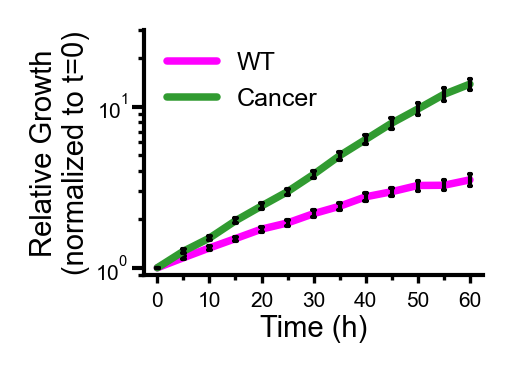

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from matplotlib.ticker import MaxNLocator, LogLocator, NullFormatter
import statsmodels.formula.api as smf
sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "ytick.labelsize": 5,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        # tick lengths (major long, minor short)
        "xtick.major.size": 1,
        "ytick.major.size": 1,
        "xtick.minor.size": 0.5,
        "ytick.minor.size": 0.5,
        "xtick.minor.width": 1,
        "ytick.minor.width": 1,
        # show minor ticks by default
        "ytick.minor.visible": True,
        "xtick.minor.visible": False,   # your x is categorical (pointplot), leave off
    
    },
)

# Show mixed only
df_mixed = summary[summary["sample_type"] == "Mixed"].copy()
df_mixed = df_mixed[df_mixed["time"] <= 60]
df_mixed_long = df_mixed.melt(
    id_vars=["sample", "time", "sample_type"],
    value_vars=["relative_growth_wt", "relative_growth_crc"],
    var_name="cell_type",
    value_name="relative_growth"
)
df_mixed_long["cell_type"] = df_mixed_long["cell_type"].replace({"relative_growth_wt": "WT mixed", "relative_growth_crc": "Cancer mixed"})

mm = 1 / 25.4  # millimeters in inches
fig, axes = plt.subplots(nrows=1, figsize=(37*mm,27*mm), dpi=300, gridspec_kw={"hspace": 0.4})
# Plot 1: relative_wt
sns.pointplot(
    data=df_mixed_long,
    x="time",
    y="relative_growth",
    hue="cell_type",
    hue_order=["WT mixed", "Cancer mixed"],
    palette={"WT mixed": "magenta", "Cancer mixed": "#319b31"},
    errorbar="se",  # or "se" for standard error, or ("ci", 95) for confidence interval
    capsize=0.1,  # Width of error bar caps
    err_kws={"linewidth": 1, "color": "black"},  # Style the error bars
    markersize=0,  # Size of the points
)
plt.ylabel("Relative Growth\n(normalized to t=0)", labelpad=1)
plt.xlabel("")
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["WT", "Cancer"],
           title="", loc="upper left", fontsize=6, frameon=False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().set_yscale("log")
plt.gca().set_ylim((0.9,30))
plt.tick_params(axis="y", pad=1)  

# set tick params to have numbers every 10 hours and minor ticks every 5 hours
from matplotlib.ticker import FixedLocator, FixedFormatter

times = sorted(df_mixed_long["time"].unique())
major = [i for i, t in enumerate(times) if t % 10 == 0]
minor = [i for i, t in enumerate(times) if t % 5 == 0 and t % 10 != 0]

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator(major))
ax.xaxis.set_major_formatter(FixedFormatter([str(int(times[i])) for i in major]))
ax.xaxis.set_minor_locator(FixedLocator(minor))
plt.tick_params(axis="x", which="minor", bottom=True, width=.8, length=1.3)
plt.tick_params(axis="x", which="major", bottom=True, width=.8, length=2)

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9), numticks=10))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis="y", which="major", left=True, length=3, width=1, pad=1)
ax.tick_params(axis="y", which="minor", left=True, length=1.5, width=0.8)
plt.xlabel("Time (h)", labelpad=1)
# mixed_summary = summary[summary["sample_type"] == "Mixed"].copy()
# mixed_summary = mixed_summary[mixed_summary["time"] <= 60]
# sns.pointplot(
#     data=mixed_summary,
#     x="time",
#     y="wt_cells",
#     hue="sample",
#     palette=["#f5b1cf"] * mixed_summary["sample"].nunique(),
#     ax=axes[1],
#     legend=False,
#     markersize=0,
#     linewidth=0.5,
#     alpha=0.5
# )
# sns.pointplot(
#     data=mixed_summary,
#     x="time",
#     y="crc_cells",
#     hue="sample",
#     palette=["#bed6b2"] * mixed_summary["sample"].nunique(),
#     ax=axes[1],
#     legend=False,
#     markersize=0,
#     linewidth=0.5,
#     alpha=0.5
# )
# sns.pointplot(
#     data=mixed_summary,
#     x="time",
#     y="wt_cells",
#     ax=axes[1],
#     legend=False,
#     markersize=0,
#     linewidth=2,
#     color="magenta",
#     errorbar="se",  # or "se" for standard error, or ("ci", 95) for confidence interval
#     capsize=0.1,  # Width of error bar caps
#     err_kws={"linewidth": 1, "color": "black"},  # Style the error bars
# )
# sns.pointplot(
#     data=mixed_summary,
#     x="time",
#     y="crc_cells",
#     ax=axes[1],
#     legend=False,
#     markersize=0,
#     linewidth=2,
#     color="green",
#     errorbar="se",  # or "se" for standard error, or ("ci", 95) for confidence interval
#     capsize=0.1,  # Width of error bar caps
#     err_kws={"linewidth": 1, "color": "black"},  # Style the error bars
# )
# axes[1].set_ylabel("Total cell count")
# axes[1].set_xlabel("Time (h)")
# axes[1].legend(title="", loc="upper left", fontsize=7, frameon=False) #turn of legend box
# axes[1].spines["top"].set_visible(False)
# axes[1].spines["right"].set_visible(False)
# axes[1].set_yscale("log")
# axes[1].set_ylim((10, 10000))
# axes[1].yaxis.set_major_locator(LogLocator(base=10, numticks=10))
# axes[1].yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(1, 10) * 0.1, numticks=100))
# axes[1].yaxis.set_minor_formatter(NullFormatter())



output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
plt.savefig(os.path.join(output_directory, f"TL_growth_curves_mixed.eps"), dpi=600, bbox_inches="tight")

plt.show()

# df = summary.copy()
# df = df[df["time"] <= 60]

# # Create two subplots side by side
# fig, axes = plt.subplots(nrows = 2, figsize=(2.7, 2.8), dpi=300)

# # Plot 1: relative_wt
# sns.pointplot(
#     data=df,
#     x="time",
#     y="relative_growth_wt",
#     hue="sample_type",
#     hue_order=["WT pure", "Mixed"],
#     palette={"WT pure": "magenta", "Mixed": "#f1a7c4"},
#     ax=axes[0],
#     errorbar="se",  # or "se" for standard error, or ("ci", 95) for confidence interval
#     capsize=0.1,  # Width of error bar caps
#     err_kws={"linewidth": 1, "color": "black"},  # Style the error bars
#     markersize=0  # Size of the points
# )
# # axes[0].set_title("WT Cell Relative Growth")
# # set y label in the center of the figure
# axes[0].set_ylabel("")
# axes[0].set_xlabel("")
# axes[0].legend(title="", loc=(0.02, 0.6), fontsize=7, handles=axes[0].get_legend_handles_labels()[0], labels=["WT pure", "WT mixed"])
# axes[0].set_ylim(top=7)
# d_wt = df[df["sample_type"].isin(["WT pure", "Mixed"])].copy()
# d_wt["log_growth_wt"] = np.log(d_wt["relative_growth_wt"])
# d_wt = d_wt.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_growth_wt"])
# model_wt = smf.mixedlm("log_growth_wt ~ C(time) * sample_type",
#                        d_wt, groups=d_wt["sample"]).fit()

# def significance_text(p):
#     if p < 0.0001:
#         return "****"
#     elif p < 0.001:
#         return "***"
#     elif p < 0.01:
#         return "**"
#     elif p < 0.05:
#         return "*"
#     else:
#         return ""

# for i, time in enumerate(df["time"].unique()):
#     p_value = model_wt.pvalues.get(f"C(time)[T.{time}]:sample_type[T.WT pure]", np.nan)
#     sig_text = significance_text(p_value)
#     axes[0].text(i, 15, sig_text, ha="center", va="bottom", fontsize=6)

# # Plot 2: relative_enriched
# sns.pointplot(
#     data=df,
#     x="time",
#     y="relative_growth_crc",
#     hue="sample_type",
#     hue_order=["CRC pure", "Mixed"],
#     palette={"CRC pure": "#319b31", "Mixed": "#a7eaa7"},
#     ax=axes[1],
#     errorbar="se",
#     capsize=0.1,
#     err_kws={"linewidth": 1, "color": "black"},
#     markersize=0,
#     #lower linewidth for lines 

# )
# # axes[1].set_title("CRC Cell Relative Growth")
# axes[1].set_ylabel("")
# axes[1].set_xlabel("Time (h)")
# axes[1].legend(title="", loc=(0.02, 0.6), fontsize=7, handles=axes[1].get_legend_handles_labels()[0], labels=["Cancer pure", "Cancer mixed"])
# axes[1].set_ylim(top=18)
# # set specific y-ticks for the second plots at 0 5 10 15
# axes[1].set_yticks([1,2,3,10])

# d_crc = df[df["sample_type"].isin(["CRC pure", "Mixed"])].copy()
# d_crc["log_growth_crc"] = np.log(d_crc["relative_growth_crc"])
# d_crc = d_crc.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_growth_crc"])
# model_crc = smf.mixedlm("log_growth_crc ~ C(time) * sample_type",
#                         d_crc, groups=d_crc["sample"]).fit()
# for i, time in enumerate(df["time"].unique()):
#     p_value = model_crc.pvalues.get(f"C(time)[T.{time}]:sample_type[T.Mixed]", np.nan)
#     sig_text = significance_text(p_value)
#     axes[1].text(i, 15, sig_text, ha="center", va="bottom", fontsize=6)


# for ax in axes:
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)
#     # remove legend box
#     ax.legend_.get_frame().set_linewidth(0.0)
#     #turn on ticks
#     ax.tick_params(axis="both", which="both", bottom=True, left=True, size=3, labelsize=6)
#     ax.set_yscale("log")
#     # ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
#     ax.set_ylim((0.9,20))
# # fig.supylabel("Number of cells per organoid (normalized to t=0)", fontsize=8, x=0.08, y=0.55)
# fig.supylabel("Number of cells per organoid\n       (normalized to t=0)", fontsize=8, x=0.08, y=0.55)

# plt.tight_layout()

# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# plt.savefig(os.path.join(output_directory, f"TL_growth_curves.eps"), dpi=600, bbox_inches="tight")

plt.show()

In [7]:
# B create schemetic overview of how EDT transform works
#B overview of touching cells
import os
import tifffile
import napari
from napari.utils.colormaps import colormap_utils as cu
from napari.utils.colormaps import DirectLabelColormap
from napari.components._viewer_constants import CanvasPosition
import numpy as np
import pandas as pd
from scipy import ndimage
colormap = cu.label_colormap(num_colors=1024)
input_directory = r"E:\Data Hussein\E-133_S-61_O-1"
scale = (0.64, 0.64) # in micrometers
segmentation = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_segmented.tif"))
selected = [1, 11, 13, 16, 18, 19]
selected_mask = np.isin(segmentation, selected).astype(np.uint16)
selected_mask = np.where(selected_mask > 0, segmentation, 0).astype(np.uint16)
selected_mask = selected_mask[12] # show only 1 timepoint
selected_mask = np.max(selected_mask, axis=0) 

#transform 5um
background = selected_mask == 0
distance, indices = ndimage.distance_transform_edt(background, sampling=scale, return_indices=True)
grow = background & (distance <= 5)
expanded = selected_mask.copy()
expanded[grow] = selected_mask[indices[0][grow], indices[1][grow]]
from skimage.segmentation import find_boundaries

bordered = expanded.copy()
bordered[find_boundaries(expanded, mode="inner", connectivity=1)] = 0


def colormap_cell(cell_numbers, color1, color2):
    colormap = {None: color2, 0: ""}
    for cell in cell_numbers:
            colormap[int(cell)] = color1
    return DirectLabelColormap(color_dict=colormap)

viewer = napari.Viewer(ndisplay=2)
viewer.add_labels(selected_mask, name = "Selected cells", scale=(1,1), iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(expanded, name = "expanded", scale=(1,1), iso_gradient_mode="smooth", opacity=1, colormap=colormap)

cells = []
for cell in selected:
    cells.append(cell)
    colormap_selected = colormap_cell(cells, "magenta", "lime")
    viewer.add_labels(bordered, name = f"expanded_{cells}", scale=(1,1), colormap=colormap_selected)
viewer.reset_view()
viewer.grid.enabled = True
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.camera.zoom = 2
#make background white
viewer.theme = 'light'
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
viewer.screenshot(path=os.path.join(output_directory, "EDT transform.png"), size=(2160, 3840), scale = 1)


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\standardize_color.py:91: UserWarning: Empty string detected. Returning black instead.
  warnings.warn(


array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [109]:
#B overview of touching cells
import os
import tifffile
import napari
from napari.utils.colormaps import colormap_utils as cu
from napari.components._viewer_constants import CanvasPosition
import numpy as np
import pandas as pd
colormap = cu.label_colormap(num_colors=1024)
input_directory = r"E:\Data Hussein\E-133_S-61_O-1"

segmentation = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_segmented.tif"))
dilated_segmentation = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_segmented_touching_neighbour_5um.tif"))
wt_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_wt_mask.tif"))
crc_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_crc_mask.tif"))
properties = pd.read_csv(os.path.join(input_directory, "E-133_S-61_O-1_properties.tsv"), sep="\t")

combined_mask = []
for timepoint in range(segmentation.shape[0]):
    segmentation_timepoint = dilated_segmentation[timepoint]
    timepoint_properties = properties[properties["timepoint"] == timepoint]
    wt_properties = timepoint_properties[timepoint_properties["phenotype_crc_vs_wt"].str.lower() == "wt"]
    wt_touching_ids = wt_properties[wt_properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1]["label"].values
    wt_non_touching_ids = wt_properties[wt_properties["phenotype_similarity_ratio_touching_neighbour_5um"] == 1]["label"].values
    crc_properties = timepoint_properties[timepoint_properties["phenotype_crc_vs_wt"].str.lower() == "crc"]
    crc_touching_ids = crc_properties[crc_properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1]["label"].values
    crc_non_touching_ids = crc_properties[crc_properties["phenotype_similarity_ratio_touching_neighbour_5um"] == 1]["label"].values

    combined_mask.append(np.select(
        [
            np.isin(segmentation_timepoint, wt_touching_ids),
            np.isin(segmentation_timepoint, wt_non_touching_ids),
            np.isin(segmentation_timepoint, crc_touching_ids),
            np.isin(segmentation_timepoint, crc_non_touching_ids),
        ],
        [1, 2, 3, 4],
        default=0,
    ).astype(np.uint8))
combined_mask = np.stack(combined_mask, axis=0)
tifffile.imwrite(os.path.join(input_directory, "E-133_S-61_O-1_combined_mask_dilated.tif"), combined_mask, compression="zlib", compressionargs={"level": 8})
combined_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_combined_mask_dilated.tif"))
colormap_mixed = {2: "#f1a7c4", 1: "magenta", 4: "#a7eaa7", 3: "#319b31"}
colomap_touching = {1: "magenta", 3: "#319b31"}

viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)
viewer.add_labels(segmentation, name = "Segmentation", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap, blending="additive")
viewer.add_labels(dilated_segmentation, name = "Dilated Segmentation", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap, blending="additive")
# viewer.add_labels(crc_mask, name = "CRC mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap={1:"green"}, blending="translucent")
# viewer.add_labels(wt_mask, name = "WT mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap={1:"magenta"}, blending="translucent")
viewer.add_labels(combined_mask, name = "Combined Mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap_mixed, blending="translucent")
viewer.add_labels(combined_mask, name = "Combined Mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colomap_touching, blending="translucent")

viewer.reset_view()
def update_slider(event):
    time = viewer.dims.current_step[0]
    viewer.text_overlay.text = f"{time*5:1f} time"

viewer.text_overlay.visible = True
viewer.text_overlay.position = CanvasPosition.BOTTOM_CENTER
viewer.text_overlay.color = "white"
viewer.text_overlay.font_size = 24
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.dims.events.current_step.connect(update_slider)
viewer.grid.enabled = True
viewer.camera.angles = (180, 0, 0)
viewer.dims.set_point(0, 12)  # move to timepoint 12

# viewer.camera.center = (255.82705268500638, 48.530579166199146, 251.23925045414418)
viewer.camera.angles = (148.75832664972222, -29.25266749741341, 47.47202111488936)
viewer.camera.zoom = 1.2
# # # Reset view to the data bounds, then set a side-view camera angle (XZ view)
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# viewer.screenshot(path=os.path.join(output_directory, "anna_interaction.png"), size=(2160, 3840), canvas_only=True, scale = 1)


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


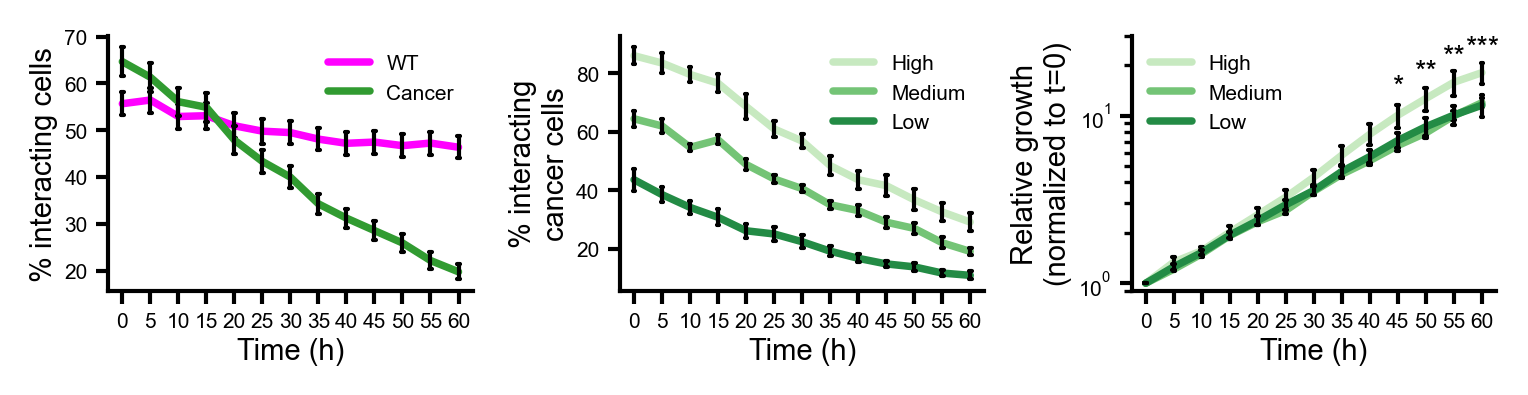

In [48]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

p = full_data.copy()
p = p[p["sample_type"] == "Mixed"]
p = p[p["time"] <= 60]
pheno = p["phenotype_crc_vs_wt"].str.lower()
interacting = p["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

p["wt"]      = pheno == "wt"
p["crc"]     = pheno == "crc"
p["int_wt"]  = p["wt"]  & interacting
p["int_crc"] = p["crc"] & interacting

results = (
    p.groupby(["time", "sample"])[["wt", "crc", "int_wt", "int_crc"]]
    .sum()
    .reset_index()
)
results["percent_interacting_wt"]  = results["int_wt"]  / results["wt"]  * 100
results["percent_interacting_crc"] = results["int_crc"] / results["crc"] * 100
results["relative_growth_crc"] = results["crc"] / results.groupby("sample")["crc"].transform("first")

sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        # set ticks thickness
        "xtick.major.width": 1,
        "ytick.major.width": 1,
    },
)

long = results.melt(
    id_vars="time",
    value_vars=["percent_interacting_wt", "percent_interacting_crc"],
    var_name="cell_type",
    value_name="percent_interacting",
)
mm = 1 / 25.4
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(129 * mm, 33 * mm), dpi=300)
position1 = 0
position2 = 1
position3 = 2
sns.pointplot(
    data=long,
    x="time",
    y="percent_interacting",
    hue="cell_type",
    palette={
        "percent_interacting_wt":  "magenta",
        "percent_interacting_crc": "#319b31",
    },
    ax=axes[position1],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1, "color": "black"},
    markersize=0,
)
axes[position1].set_ylabel("% interacting cells")
axes[position1].set_xlabel("Time (h)")
handles, _ = axes[position1].get_legend_handles_labels()
axes[position1].legend(handles=handles, labels=["WT", "Cancer"], title="", frameon=False)

axes[position1].spines["top"].set_visible(False)
axes[position1].spines["right"].set_visible(False)
# remove legend box
axes[position1].legend_.get_frame().set_linewidth(0.0)
#turn on ticks
axes[position1].tick_params(axis="both", which="major", bottom=True, left=True, size=3)

# one tercile label per SAMPLE, based on its mean CRC interaction across time
sample_level = results.groupby("sample")["percent_interacting_crc"].mean()
sample_group = pd.qcut(sample_level, q=3, labels=["Low", "Medium", "High"])
# sample_group = pd.qcut(sample_level, q=2, labels=["Low", "High"])
# edges = np.linspace(sample_level.min(), sample_level.max(), 4)
# sample_group = pd.cut(
#     sample_level,
#     bins=edges,
#     labels=["Low", "Medium", "High"],
#     include_lowest=True,          # <-- so the min value lands in "Low" instead of NaN
# )

results["interaction_group"] = results["sample"].map(sample_group)

sns.pointplot(
    data=results,
    x="time",
    y="percent_interacting_crc",
    hue="interaction_group",
    hue_order=["High", "Medium", "Low"],
    palette={"High": "#c7e9c0", "Medium": "#74c476", "Low": "#238b45"},
    ax=axes[position2],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1, "color": "black"},
    markersize=0,
)
axes[position2].set_ylabel("% interacting\ncancer cells")
axes[position2].set_xlabel("Time (h)")
handles, _ = axes[position2].get_legend_handles_labels()
axes[position2].legend(handles=handles, labels=["High", "Medium", "Low"], title="", frameon=False)

axes[position2].spines["top"].set_visible(False)
axes[position2].spines["right"].set_visible(False)
axes[position2].legend_.get_frame().set_linewidth(0.0)
axes[position2].tick_params(axis="both", which="major", bottom=True, left=True, size=3)

sns.pointplot(
    data=results,
    x="time",
    y="relative_growth_crc",
    hue="interaction_group",
    hue_order=["High", "Medium", "Low"],
    palette={"High": "#c7e9c0", "Medium": "#74c476", "Low": "#238b45"},
    ax=axes[position3],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1, "color": "black"},
    markersize=0,
)
axes[position3].set_yscale("log")
axes[position3].set_ylim(0.9, 30)
axes[position3].set_ylabel("Relative growth\n(normalized to t=0)")
axes[position3].set_xlabel("Time (h)")
handles, _ = axes[position3].get_legend_handles_labels()

# ax.legend_.remove()
axes[position3].legend(handles=handles, labels=["High", "Medium", "Low"], title="", frameon=False, loc="upper left")
axes[position3].legend_.get_frame().set_linewidth(0.0)
axes[position3].spines["top"].set_visible(False)
axes[position3].spines["right"].set_visible(False)
axes[position3].tick_params(axis="both", which="major", bottom=True, left=True, size=3)
axes[position3].tick_params(axis="y",    which="minor", left=True, width= .8, length=2)
# Calculate statistics between High and Low group
selected_results = results[results["interaction_group"].isin(["High", "Low"])].copy()
selected_results["interaction_group"] = selected_results["interaction_group"].cat.remove_unused_categories() 
selected_results["log_growth"] = np.log(selected_results["relative_growth_crc"])
selected_results = selected_results.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_growth"])
stats = smf.mixedlm("log_growth ~ C(time) * interaction_group", selected_results, groups=selected_results["sample"]).fit()

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

for i, time in enumerate(selected_results["time"].unique()):
    p_value = stats.pvalues.get(f"C(time)[T.{time}]:interaction_group[T.High]", np.nan)
    sig_text = significance_text(p_value)
    time_y_max = [selected_results[selected_results["time"] == time]["relative_growth_crc"].mean() for time in selected_results["time"].unique()][i]
    axes[position3].text(i, time_y_max * 1.4, sig_text, ha="center", va="bottom", fontsize=7)

# axes[0, 1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"TL_interacting_cells_overview.eps"), dpi=600, bbox_inches="tight")
plt.show()


In [45]:
import napari
import os
from numpy import unique
import tifffile
import zarr
input_directory = r"E:\Data Hussein"


# from the low medium high interaction groups, pick two samples each
# low_samples = unique(results[results["interaction_group"] == "Low"]["sample"].tolist())
# medium_samples = unique(results[results["interaction_group"] == "Medium"]["sample"].tolist())
# high_samples = unique(results[results["interaction_group"] == "High"]["sample"].tolist())

selected_samples = ["E-139_S-25_O-1","E-140_S-48_O-1"]
timepoint = 6
print("Selected samples for visualization:", selected_samples)
viewer = napari.Viewer(ndisplay=3)
viewer.reset_view()
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
scale = (2.5, 0.654, 0.654)  # z, y, x in micrometers


for sample in selected_samples:
    print(f"Visualizing sample: {sample}")
    image_path = os.path.join(input_directory, sample, f"{sample}_cropped.tif")

    image = tifffile.imread(image_path)[timepoint]
    viewer.add_image(
        image[: ,1], name=f"{sample} crc", scale=scale, colormap="green", blending="additive", visible=True
    )
    viewer.add_image(
        image[: ,2], name=f"{sample} wt", scale=scale, colormap="magenta", blending="additive", visible=True
    )
    wt_seg = tifffile.imread(os.path.join(input_directory, sample, f"{sample}_wt_mask.tif"))[timepoint]
    wt_seg_binary = np.where(wt_seg > 0, 1, 0)
    crc_seg = tifffile.imread(os.path.join(input_directory, sample, f"{sample}_crc_mask.tif"))[timepoint]
    crc_seg_binary = np.where(crc_seg > 0, 2, 0)
    combined_mask = wt_seg_binary + crc_seg_binary
    # viewer.add_labels(wt_seg_binary, name=f"{sample} WT segmentation", scale=scale, colormap=["black", "green"], blending="additive", visible=False)
    # viewer.add_labels(crc_seg_binary, name=f"{sample} CRC segmentation", scale=scale, colormap=["black", "magenta"], blending="additive", visible=False)
    viewer.add_labels(combined_mask, name=f"{sample} Combined segmentation", scale=scale, colormap={0: "", 1: "magenta", 2: "#319b31"}, blending="additive", opacity=1)

    viewer.camera.zoom = 3
    viewer.camera.angles = (-12.41674898333476, 8.824164192022561, 132.83181757795282)
    viewer.camera.center = (95.0, 129.81900000000002, 135.37800000000001)   
    output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
    viewer.layers[f"{sample} Combined segmentation"].visible = False
    viewer.screenshot(path=os.path.join(output_directory, f"Interaction_examples_{sample}.png"), size=(2160, 3840), scale = 1)
    viewer.layers[f"{sample} wt"].visible = False
    viewer.layers[f"{sample} crc"].visible = False
    viewer.layers[f"{sample} Combined segmentation"].visible = True
    viewer.screenshot(path=os.path.join(output_directory, f"Interaction_examples_{sample}_seg.png"), size=(2160, 3840), scale = 1)
    viewer.layers[f"{sample} Combined segmentation"].visible = False


@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")


Selected samples for visualization: ['E-139_S-25_O-1', 'E-140_S-48_O-1']
Visualizing sample: E-139_S-25_O-1


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


Visualizing sample: E-140_S-48_O-1


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


Microtissue

In [4]:
from imaris_ims_file_reader import ims
import tifffile
import napari
import os
import numpy as np
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\RB007_mix_suspension_ki67_FusionStitcher_F11"
name = os.path.basename(input_directory)
image = ims(os.path.join(input_directory, f"{name}_cropped.ims"))
segmentation = tifffile.imread(os.path.join(input_directory, f"{name}_segmented.tif"))
wt_segmentation   = tifffile.imread(os.path.join(input_directory, f"{name}_TdT_mask.tif"))
crc_segmentation  = tifffile.imread(os.path.join(input_directory, f"{name}_Dendra_mask.tif"))
ki67_segmentation = tifffile.imread(os.path.join(input_directory, f"{name}_ki67_mask.tif"))
ki67_segmentation = np.where(ki67_segmentation > 0, 1, 0)
combined_segmentation = np.zeros(wt_segmentation.shape, dtype=np.uint8)
combined_segmentation[wt_segmentation   > 0] = 1
combined_segmentation[crc_segmentation  > 0] = 2
# combined_segmentation[ki67_segmentation > 0] = 3

dapi = image[0, 0]
crc = image[0, 1]
wt = image[0, 2]
ki67 = image[0, 3]

dapi_contrast = (np.median(dapi) * 1.2, np.percentile(dapi, 99.95))
crc_contrast = (np.median(crc) * 1.3, np.percentile(crc, 99.9))
wt_contrast = (np.median(wt) * 1.2, np.percentile(wt, 99.9))
ki67_contrast = (np.median(ki67) * 1.2, np.percentile(ki67, 99.9))

viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.654, 0.654)  # z, y, x in micrometers
viewer.add_image(dapi, name="dapi", scale=scale, colormap="blue", blending="additive", contrast_limits=dapi_contrast)
viewer.add_image(crc, name="crc", scale=scale, colormap="green", blending="additive", contrast_limits=crc_contrast)
viewer.add_image(wt, name="wt", scale=scale, colormap="magenta", blending="additive", contrast_limits=wt_contrast)
viewer.add_image(ki67, name="ki67", scale=scale, colormap="white", blending="additive", contrast_limits=ki67_contrast)
viewer.add_labels(segmentation, name="segmentation", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap, blending="translucent")
viewer.add_labels(combined_segmentation, name="combined_mask", scale=scale, colormap={0:"", 1:"magenta", 2:"lime"}, blending="translucent", opacity=1)
viewer.add_labels(ki67_segmentation, name="ki67_mask", scale=scale, colormap={0:"", 1:"white"}, blending="translucent", opacity=1)
viewer.reset_view()
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
standard_zoom = 0.9
zoomed_zoom = 3.5
zoomed_center = (81.36403718997984, 754.7249132836121, 356.12557408071456)

# viewer.camera.zoom = standard_zoom
# viewer.layers["crc"].visible = False
# viewer.layers["wt"].visible = False
# viewer.layers["ki67"].visible = False
# viewer.layers["segmentation"].visible = False
# viewer.layers["combined_mask"].visible = False
# viewer.layers["ki67_mask"].visible = False
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_dapi.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_dapi_zoom.png"), size=(2160, 3840), scale = 1)

# viewer.reset_view()
# viewer.camera.zoom = standard_zoom
# viewer.layers["crc"].visible = True
# viewer.layers["wt"].visible = True
# viewer.layers["dapi"].visible = False
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_wt_crc.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_wt_crc_zoom.png"), size=(2160, 3840), scale = 1)

# viewer.reset_view()
# viewer.camera.zoom = standard_zoom
# viewer.layers["crc"].visible = False
# viewer.layers["wt"].visible = False
# viewer.layers["ki67"].visible = True
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_ki67.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_ki67_zoom.png"), size=(2160, 3840), scale = 1)

# viewer.reset_view()
# viewer.camera.zoom = standard_zoom
# viewer.layers["ki67"].visible = False
# viewer.layers["segmentation"].visible = True
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_segmentation.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_segmentation_zoom.png"), size=(2160, 3840), scale = 1)

# viewer.reset_view()
# viewer.camera.zoom = standard_zoom
# viewer.layers["combined_mask"].visible = True
# viewer.layers["segmentation"].visible = False
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_combined_mask.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_combined_mask_zoom.png"), size=(2160, 3840), scale = 1)

# viewer.reset_view()
# viewer.camera.zoom = standard_zoom
# viewer.layers["combined_mask"].visible = False
# viewer.layers["ki67_mask"].visible = True
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_ki67_mask.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_ki67_mask_zoom.png"), size=(2160, 3840), scale = 1)


@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\RB007_mix_suspension_ki67_FusionStitcher_F11\RB007_mix_suspension_ki67_FusionStitcher_F11_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\RB007_mix_suspension_ki67_FusionStitcher_F11\RB007_mix_suspension_ki67_FusionStitcher_F11_cropped.ims 



c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:128: UserWarning: HistogramMax value is not present for resolution 3, time 0, channel 3. 
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:134: UserWarning: HistogramMin value is not present for resolution 3, time 0, channel 3.
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:128: UserWarning: HistogramMax value is not present for resolution 4, time 0, channel 3. 
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warn

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\6331823\\Local SSD\\NucLogic paper figure data\\RB007_mix_suspension_ki67_FusionStitcher_F11\\RB007_mix_suspension_ki67_FusionStitcher_F11_ki67_mask.tif'

   ki67_positive  total_cells  wt_cells  crc_cells  interacting_wt  \
0          False        11474      7758       3716            2685   
1           True         1361       151       1210             135   

   non_interacting_wt  interacting_crc  non_interacting_crc  \
0                5073             1964                 1752   
1                  16              615                  595   

   percent_interacting_wt  percent_interacting_crc  
0               34.609435                52.852530  
1               89.403974                50.826446  


C:\Users\6331823\AppData\Local\Temp\ipykernel_17920\730521156.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["WT", "Cancer"])


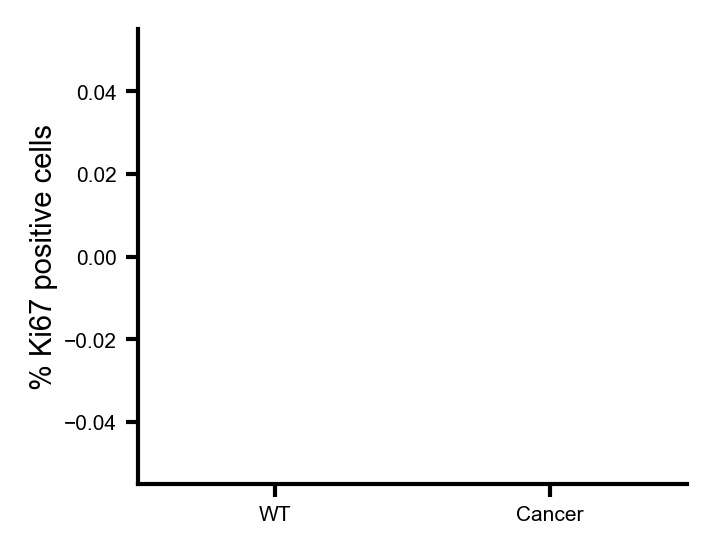

                         wt_cells  crc_cells  ki67_positive  ki67_percentage
phenotype_dendra_vs_tdt                                                     
Dendra                          0       4926              0              0.0
TdT                          7909          0              0              0.0


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\RB007_mix_suspension_ki67_FusionStitcher_F11"

name = os.path.basename(input_directory)
properties = pd.read_csv(os.path.join(input_directory, f"{name}_properties.tsv"), sep="\t")

sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

summary = properties.groupby("phenotype_dendra_vs_tdt").agg(
    wt_cells =("phenotype_dendra_vs_tdt", lambda x: (x == "TdT").sum()),
    crc_cells=("phenotype_dendra_vs_tdt", lambda x: (x == "Dendra").sum()),
    ki67_positive=("ki67_positive", lambda x: (x == "True").sum()),
    ki67_percentage=("ki67_positive", lambda x: (x == "True").sum() / len(x) * 100)
)

pheno       = properties["phenotype_dendra_vs_tdt"].str.lower()
interacting = properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

properties["interacting_wt"]      =  interacting & (pheno == "tdt")
properties["non_interacting_wt"]  = ~interacting & (pheno == "tdt")
properties["interacting_crc"]     =  interacting & (pheno == "dendra")
properties["non_interacting_crc"] = ~interacting & (pheno == "dendra")

summary_ki67 = properties.groupby("ki67_positive").agg(
    total_cells=("ki67_positive", "count"),
    wt_cells =("phenotype_dendra_vs_tdt", lambda x: (x == "TdT").sum()),
    crc_cells=("phenotype_dendra_vs_tdt", lambda x: (x == "Dendra").sum()),
    interacting_wt      =("interacting_wt", "sum"),
    non_interacting_wt  =("non_interacting_wt", "sum"),
    interacting_crc     =("interacting_crc", "sum"),
    non_interacting_crc =("non_interacting_crc", "sum"),
).reset_index()

summary_ki67["percent_interacting_wt"]  = summary_ki67["interacting_wt"]  / summary_ki67["wt_cells"]  * 100
summary_ki67["percent_interacting_crc"] = summary_ki67["interacting_crc"] / summary_ki67["crc_cells"] * 100

print(summary_ki67)

fig, ax = plt.subplots(figsize=(60/25.4, 50/25.4), dpi=300)
sns.barplot(
    data=summary,
    x="phenotype_dendra_vs_tdt",
    y="ki67_percentage",
    order=["TdT", "Dendra"],
    hue="phenotype_dendra_vs_tdt",
    palette={"TdT": "magenta", "Dendra": "#319b31"},
    ax=ax
)
ax.tick_params(axis="both", which="major", bottom=True, left=True, size=3)
ax.set_xticklabels(["WT", "Cancer"])
ax.set_ylabel("% Ki67 positive cells")
ax.set_xlabel("")
plt.show()
print(summary)

In [149]:
properties["interacting"] = properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

ki67_by_interaction = (
    properties.assign(ki67=properties["phenotype_ki67_vs_dapi"].eq("ki67"))
    .groupby(["phenotype_crc_vs_wt", "interacting"], as_index=False)
    .agg(n_cells=("ki67", "size"), ki67_positive=("ki67", "sum"))
)
ki67_by_interaction["ki67_percentage"] = (
    ki67_by_interaction["ki67_positive"] / ki67_by_interaction["n_cells"] * 100
)

print(ki67_by_interaction)

  phenotype_crc_vs_wt  interacting  n_cells  ki67_positive  ki67_percentage
0                 crc        False     1438            381        26.495132
1                 crc         True     3968           1989        50.126008
2                  wt        False     6510             75         1.152074
3                  wt         True     2038            411        20.166830


C:\Users\6331823\AppData\Local\Temp\ipykernel_17920\247863375.py:11: DtypeWarning: Columns (31,33,35) have mixed types. Specify dtype option on import or set low_memory=False.
  properties = pd.read_csv(os.path.join(input_directory, f"full_data.tsv"), sep="\t")
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\6331823\AppData\Local\Temp\ipykernel_17920\247863375.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["WT", "Cancer"])
C:\Users\6331823\AppData\Local\Temp\ipykernel_17920\247863375.py:147: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(


wt: n=10 pairs, t=1.177, p=0.2693
crc: n=10 pairs, t=-3.549, p=0.006225


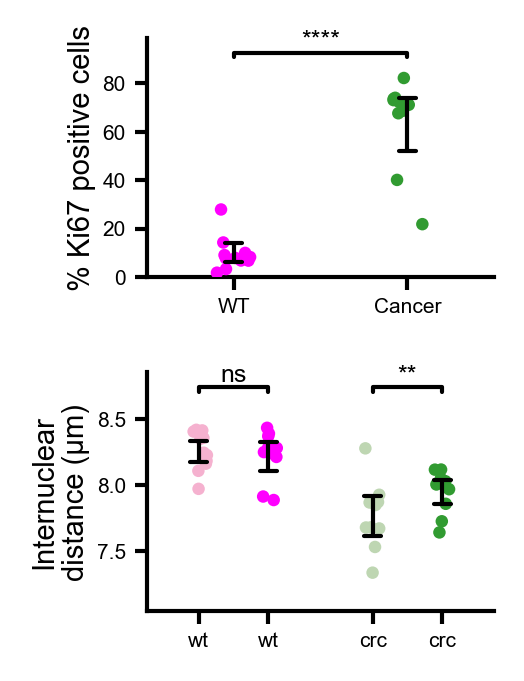

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\microtissues"

name = os.path.basename(input_directory)
properties = pd.read_csv(os.path.join(input_directory, f"full_data.tsv"), sep="\t")
# properties = pd.read_csv(os.path.join(input_directory,"RB007_mix_suspension_ki67_F11", f"RB007_mix_suspension_ki67_F11_properties.tsv"), sep="\t")
properties["log_ratio_ki67_background_subtracted_mean_intensity_dapi_background_subtracted_mean_intensity"] = np.log10(
    properties["ki67_background_subtracted_mean_intensity"] / properties["dapi_background_subtracted_mean_intensity"]
)
threshold = -0.2
properties["phenotype_ki67_vs_dapi"] = np.where(
    properties["log_ratio_ki67_background_subtracted_mean_intensity_dapi_background_subtracted_mean_intensity"] > threshold, "ki67", "dapi"
)

sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

properties["interacting"] = properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1
summary = properties.groupby(["phenotype_crc_vs_wt", "sample"]).agg(
    wt_cells =("phenotype_crc_vs_wt", lambda x: (x == "wt").sum()),
    crc_cells=("phenotype_crc_vs_wt", lambda x: (x == "crc").sum()),
    ki67_positive=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum()),
    ki67_percentage=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum() / len(x) * 100),
    density=("mean_distance_1_knn", "mean")
).reset_index()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(38/25.4, 63/25.4), 
                         dpi=300, gridspec_kw={"height_ratios": [1, 1], "hspace":0.4}) # gridspec_kw={"width_ratios": [0.5, 1], "wspace":0.8}
sns.stripplot(
    data=summary,
    x="phenotype_crc_vs_wt",
    y="ki67_percentage",
    order=["wt", "crc"],
    hue="phenotype_crc_vs_wt",
    palette={"wt": "magenta", "crc": "#319b31"},
    size=3,
    jitter=0.1,
    ax=axes[0]
)
sns.pointplot(
    data=summary,
    x="phenotype_crc_vs_wt",
    y="ki67_percentage",
    order=["wt", "crc"],
    color="black",
    markersize=0,
    capsize=0.1,
    linewidth=0,
    err_kws={"linewidth": 1, "color": "black"},
    zorder=10,
    ax=axes[0]
)

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
def add_bracket(ax, x1, x2, text, y=0.92, barh=0.02, fontsize=6):
    """Significance bracket. y/barh are axes fractions, so data limits are untouched."""
    if not text:
        return
    xlim = ax.get_xlim()                      # categorical padding, e.g. (-0.5, 1.5)
    trans = ax.get_xaxis_transform()          # x: data, y: axes fraction
    ax.plot([x1, x1, x2, x2], [y, y + barh, y + barh, y],
            color="black", lw=1, transform=trans, clip_on=False)
    ax.text((x1 + x2) / 2, y + barh, text, ha="center", va="bottom",
            fontsize=fontsize, transform=trans)
    ax.set_xlim(xlim)                         # undo the autoscale

wt_values = summary[summary["phenotype_crc_vs_wt"] == "wt"]["ki67_percentage"]
crc_values = summary[summary["phenotype_crc_vs_wt"] == "crc"]["ki67_percentage"]
# do a simple t test to compare the two groups
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(wt_values, crc_values, equal_var=False)

y_max = max(summary["ki67_percentage"])
axes[0].set_ylim(0, y_max*1.2)
# axes[0].text(0.5, y_max * 1.1, sig_text, ha="center", va="bottom", fontsize=6)
add_bracket(axes[0], 0, 1, significance_text(p_value))
axes[0].set_ylabel("% Ki67 positive cells")
axes[0].set_xticklabels(["WT", "Cancer"])

summary = properties.groupby(["phenotype_crc_vs_wt", "sample", "interacting"]).agg(
    wt_cells =("phenotype_crc_vs_wt", lambda x: (x == "wt").sum()),
    crc_cells=("phenotype_crc_vs_wt", lambda x: (x == "crc").sum()),
    ki67_positive=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum()),
    ki67_percentage=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum() / len(x) * 100),
    density=("mean_distance_1_KNN", "mean")
).reset_index()

palettes = {
    "wt":    {False: "#f5b1cf", True: "magenta"},
    "crc": {False: "#bed6b2", True: "#319b31"},
}
ORDER, HUE_ORDER, DODGE = ["wt", "crc"], [False, True], 0.4

for phenotype, palette in palettes.items():
    sub = summary[summary["phenotype_crc_vs_wt"] == phenotype]
    sns.stripplot(
        data=sub, x="phenotype_crc_vs_wt", y="density",
        order=ORDER, hue="interacting", hue_order=HUE_ORDER,
        palette=palette, size=3, jitter=0.1, dodge=DODGE,
        legend=False, ax=axes[1],
    )
sns.pointplot(
    data=summary,
    x="phenotype_crc_vs_wt",
    y="density",
    order=["wt", "crc"],
    hue="interacting",
    hue_order=HUE_ORDER,
    color="black",
    markersize=0,
    capsize=0.1,
    linewidth=0,
    err_kws={"linewidth": 1, "color": "black"},
    zorder=10,
    ax=axes[1],
    dodge=DODGE,
    legend=False
)

axes[1].set_ylabel("Internuclear\ndistance (µm)")
from matplotlib.lines import Line2D

n = len(HUE_ORDER)
offsets = (np.arange(n) - (n - 1) / 2) * DODGE 

ticks, labels = [], []
for i, phenotype in enumerate(ORDER):
    if phenotype == "wt":
        name = "WT"
    else:
        name = "Cancer"
    for j, interacting in enumerate(HUE_ORDER):
        ticks.append(i + offsets[j])
        labels.append(f"{name} int" if interacting else f"{name} non-int")

axes[1].set_xticks(ticks)
# axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_xlabel("")
ymax = max(summary["density"])
ymin = min(summary["density"])
axes[1].set_ylim(ymin * 0.96, ymax * 1.05)
# x positions of the four clusters (same offsets used for the ticks)
positions = {(p, i): x + offsets[j]
             for x, p in enumerate(ORDER)
             for j, i in enumerate(HUE_ORDER)}
from scipy.stats import ttest_rel
for phenotype in ORDER:
    sub = summary[summary["phenotype_crc_vs_wt"] == phenotype]
    paired = sub.pivot(index="sample", columns="interacting", values="density").dropna()
    if len(paired) < 2:
        continue
    t_stat, p_value = ttest_rel(paired[False], paired[True])
    add_bracket(
        axes[1],
        positions[(phenotype, False)],
        positions[(phenotype, True)],
        significance_text(p_value),
        y=0.92,
    )
    print(f"{phenotype}: n={len(paired)} pairs, t={t_stat:.3f}, p={p_value:.4g}")

for ax in axes:
    ax.tick_params(axis="both", which="major", bottom=True, left=True, size=3)
    ax.set_xlabel("")

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
plt.savefig(os.path.join(output_directory, f"microtissue_plot.eps"), dpi=600, bbox_inches="tight")
plt.show()

ki67_percentage / wt: n=10 pairs, t=-6.595, p=9.985e-05
ki67_percentage / crc: n=10 pairs, t=6.455, p=0.0001175
density / wt: n=10 pairs, t=1.177, p=0.2693
density / crc: n=10 pairs, t=-3.549, p=0.006225


C:\Users\6331823\AppData\Local\Temp\ipykernel_17920\3788135443.py:36: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\6331823\AppData\Local\Temp\ipykernel_17920\3788135443.py:36: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(


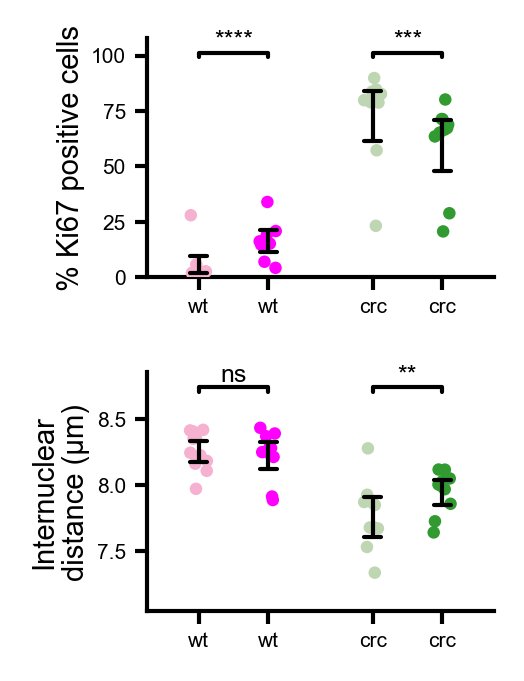

In [18]:
properties["interacting"] = properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

summary = properties.groupby(["phenotype_crc_vs_wt", "sample", "interacting"]).agg(
    wt_cells=("phenotype_crc_vs_wt", lambda x: (x == "wt").sum()),
    crc_cells=("phenotype_crc_vs_wt", lambda x: (x == "crc").sum()),
    ki67_positive=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum()),
    ki67_percentage=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum() / len(x) * 100),
    density=("mean_distance_1_KNN", "mean"),
).reset_index()

palettes = {
    "wt":  {False: "#f5b1cf", True: "magenta"},
    "crc": {False: "#bed6b2", True: "#319b31"},
}
ORDER, HUE_ORDER, DODGE = ["wt", "crc"], [False, True], 0.4
offsets = (np.arange(len(HUE_ORDER)) - (len(HUE_ORDER) - 1) / 2) * DODGE
positions = {(p, i): x + offsets[j]
             for x, p in enumerate(ORDER)
             for j, i in enumerate(HUE_ORDER)}
ticks = [positions[(p, i)] for p in ORDER for i in HUE_ORDER]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(38/25.4, 63/25.4),
                         dpi=300, gridspec_kw={"height_ratios": [1, 1], "hspace": 0.4})

from scipy.stats import ttest_rel

def split_panel(ax, value, ylabel, ylim):
    for phenotype, palette in palettes.items():
        sub = summary[summary["phenotype_crc_vs_wt"] == phenotype]
        sns.stripplot(
            data=sub, x="phenotype_crc_vs_wt", y=value,
            order=ORDER, hue="interacting", hue_order=HUE_ORDER,
            palette=palette, size=3, jitter=0.1, dodge=DODGE,
            legend=False, ax=ax,
        )
    sns.pointplot(
        data=summary, x="phenotype_crc_vs_wt", y=value,
        order=ORDER, hue="interacting", hue_order=HUE_ORDER,
        color="black", markersize=0, capsize=0.1, linewidth=0,
        err_kws={"linewidth": 1, "color": "black"},
        zorder=10, dodge=DODGE, legend=False, ax=ax,
    )
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticks(ticks)
    ax.set_ylim(*ylim)

    for phenotype in ORDER:
        sub = summary[summary["phenotype_crc_vs_wt"] == phenotype]
        paired = sub.pivot(index="sample", columns="interacting", values=value).dropna()
        if len(paired) < 2:
            continue
        t_stat, p_value = ttest_rel(paired[False], paired[True])
        add_bracket(ax, positions[(phenotype, False)], positions[(phenotype, True)],
                    significance_text(p_value), y=0.92)
        print(f"{value} / {phenotype}: n={len(paired)} pairs, t={t_stat:.3f}, p={p_value:.4g}")

split_panel(axes[0], "ki67_percentage", "% Ki67 positive cells",
            (0, summary["ki67_percentage"].max() * 1.2))
split_panel(axes[1], "density", "Internuclear\ndistance (µm)",
            (summary["density"].min() * 0.96, summary["density"].max() * 1.05))

for ax in axes:
    ax.tick_params(axis="both", which="major", bottom=True, left=True, size=3)
    ax.set_xlabel("")


In [125]:
print(properties.columns)

Index(['sample', 'label', 'z_pixel', 'y_pixel', 'x_pixel', 'bounding_box',
       'volume', 'z', 'y', 'x', 'dapi_raw_mean_intensity',
       'dapi_background_subtracted_mean_intensity', 'crc_raw_mean_intensity',
       'crc_background_subtracted_mean_intensity', 'wt_raw_mean_intensity',
       'wt_background_subtracted_mean_intensity', 'ki67_raw_mean_intensity',
       'ki67_background_subtracted_mean_intensity', 'timepoint', 'time',
       'ratio_crc_background_subtracted_mean_intensity_wt_background_subtracted_mean_intensity',
       'log_ratio_crc_background_subtracted_mean_intensity_wt_background_subtracted_mean_intensity',
       'phenotype_crc_vs_wt', 'mean_distance_1_KNN', 'neighbours_1_KNN',
       'touching_neighbour_5um_neighbours', 'touching_neighbour_5um_count',
       'mean_distance_touching_neighbour_5um',
       'phenotype_similarity_ratio_touching_neighbour_5um',
       'ratio_ki67_background_subtracted_mean_intensity_dapi_background_subtracted_mean_intensity',
       '

In [130]:
display(summary)

,phenotype_crc_vs_wt,sample,interacting,wt_cells,crc_cells,ki67_positive,ki67_percentage,density
0,crc,RB007_mix_suspension_ki67_F11,False,0,2658,614,23.100075,NaN
1,crc,RB007_mix_suspension_ki67_F11,True,0,2748,565,20.560408,NaN
2,crc,RB007_mix_suspension_ki67_F12,False,0,1024,920,89.843750,NaN
3,crc,RB007_mix_suspension_ki67_F12,True,0,3795,3041,80.131752,NaN
4,crc,RB007_mix_suspension_ki67_F13,False,0,1020,850,83.333333,7.871033
5,crc,RB007_mix_suspension_ki67_F13,True,0,2687,1787,66.505396,7.992795
6,crc,RB007_mix_suspension_ki67_FusionStitcher_F10,False,0,1495,855,57.190635,NaN
7,crc,RB007_mix_suspension_ki67_FusionStitcher_F10,True,0,2256,649,28.767730,NaN
8,crc,RB007_mix_suspension_ki67_FusionStitcher_F15,False,0,2104,1657,78.754753,NaN
9,crc,RB007_mix_suspension_ki67_FusionStitcher_F15,True,0,6045,3938,65.144748,NaN


In [10]:
import pandas as pd
import os
import numpy as np
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
properties = pd.read_csv(os.path.join(input_directory, f"ruth_data.tsv"), sep="\t")
properties = pd.read_csv(os.path.join(input_directory,"microtissues", "RB007_mix_suspension_ki67_F11", f"RB007_mix_suspension_ki67_F11_properties.tsv"), sep="\t")
properties["interacting"] = properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

threshold = -0.6
properties["log_ratio_ki67_background_subtracted_mean_intensity_dapi_background_subtracted_mean_intensity"] = np.log10(
    properties["ki67_background_subtracted_mean_intensity"] / properties["dapi_background_subtracted_mean_intensity"]
)
properties["phenotype_ki67_vs_dapi"] = np.where(
    properties["log_ratio_ki67_background_subtracted_mean_intensity_dapi_background_subtracted_mean_intensity"] > threshold, "ki67", "dapi"
)
# properties["phenotype_crc_vs_wt"] = properties["phenotype_Dendra_vs_TdT"].map({"Dendra": "crc", "TdT": "wt"})
# properties = properties[properties["sample"] == "RB007_mix_suspension_ki67_FusionStitcher_F11"]

ki67_by_interaction = (
    properties.assign(ki67=properties["phenotype_ki67_vs_dapi"].eq("ki67"))
    .groupby(["phenotype_crc_vs_wt", "interacting", "sample"], as_index=False)
    .agg(n_cells=("ki67", "size"), ki67_positive=("ki67", "sum"))
)
ki67_by_interaction["ki67_percentage"] = (
    ki67_by_interaction["ki67_positive"] / ki67_by_interaction["n_cells"] * 100
)

display(ki67_by_interaction)

,phenotype_crc_vs_wt,interacting,sample,n_cells,ki67_positive,ki67_percentage
0,crc,False,RB007_mix_suspension_ki67_F11,2658,1278,48.081264
1,crc,True,RB007_mix_suspension_ki67_F11,2748,1092,39.737991
2,wt,False,RB007_mix_suspension_ki67_F11,5436,75,1.379691
3,wt,True,RB007_mix_suspension_ki67_F11,3112,411,13.206941


New zebrafish brain data

In [8]:
import nrrd
import numpy as np
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import pandas as pd
import tifffile
from skimage.transform import resize
from scipy import ndimage

input_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001\40x WIS zstack DAPI midbrain"
names = ["40x WIS zstack DAPI midbrain.TIF"]

scale = (1, 0.1678, 0.1678)  # in micrometers


# load cp-sam foundation model
from cellpose import models
model = models.CellposeModel(model_type="cpsam_v2", gpu=True)
results = []
for name in names:
    image = tifffile.imread(os.path.join(input_directory, name))

    # start_time = time.time()
    # mask = segment(image, model)
    # # tifffile.imwrite(
    # #     os.path.join(input_directory, "2d_segmented_degraded.tif"),
    # #     mask,
    # #     compression="zlib",
    # #     compressionargs={"level": 8},
    # # )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented.tif"))
    # segmentation_time = time.time() - start_time
    # start_stitch_time = time.time()
    # nuclogic = stitch_3d(
    #     mask,
    #     image,
    #     image_type_1="wt",
    #     breaking_threshold=3,
    #     scale=scale
    # )
    # end_time = time.time()
    # nuclogic_time = end_time - start_time
    # nuclogic_cellpose_time = start_stitch_time - start_time
    # nuclogic_stitch_time = end_time - start_stitch_time

    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_nuclogic_degraded.tif"),
    #     nuclogic,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    # nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_rescaled.tif"))

    # nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    # print(f"centroid accuracy: {nuclogic_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    # )

    # print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    # print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    # print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")


    # start_cp4 = time.time()
    # cp4,_,_ = model.eval(
    #                 image,
    #                 diameter=None,
    #                 normalize=True,
    #                 flow3D_smooth=0.4,
    #                 resample=True,
    #                 do_3D=True,
    #                 z_axis=0,
    #                 min_size=150,
    #                 progress=True,
    #             )
    # end_cp4 = time.time()
    # cp4_time = end_cp4 - start_cp4

    ground_truth = tifffile.imread(os.path.join(input_directory, "3d_segmented_cp4.tif"))
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds.")

    start_usegment = time.time()
    usegment = usegment_stitch(mask)
    end_usegment = time.time()
    usegment_time = end_usegment - start_usegment

    print(f"Usegment completed in {usegment_time:.2f} seconds.")

    tifffile.imwrite(
        os.path.join(input_directory, f"3d_segmented_usegment.tif"),
        usegment,
        compression="zlib",
        compressionargs={"level": 8},
    )
    usegment = tifffile.imread(os.path.join(input_directory, f"3d_segmented_usegment.tif")).astype(np.uint16)

    print(ground_truth.shape, usegment.shape)
    usegement_results = centroid_accuracy(ground_truth, usegment)
    print(f"centroid accuracy: {usegement_results}")

    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_cp4_degraded.tif"),
    #     cp4,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    # cp4_results = (centroid_accuracy(ground_truth, cp4))
    # print(f"centroid accuracy: {cp4_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    # )
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    # print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # save results of centroid accuracy and amount of cells to a tsv file

    # results_df = pd.DataFrame(
    #     {
    #         "method": ["nuclogic", "cellpose4"],
    #         "f1": [nuclogic_results["f1"], cp4_results["f1"]],
    #         "precision": [nuclogic_results["precision"], cp4_results["precision"]],
    #         "recall": [nuclogic_results["recall"], cp4_results["recall"]],
    #         "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
    #         "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
    #         "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
    #         "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
    #         "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
    #         "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
    #         "total_time": [nuclogic_time, cp4_time],
    #         "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
    #         "stitching_time": [nuclogic_stitch_time, 0],
    #     }
    # )
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
# results_df.to_csv(os.path.join(output_directory, "emmanuel_results_rescaled.tsv"), sep="\t", index=False)

Automatric binary thresholding:  0.8


100%|██████████| 200/200 [1:09:22<00:00, 20.81s/it]


Usegment completed in 4399.17 seconds.
(101, 2048, 2048) (101, 2048, 2048)
centroid accuracy: {'true_positives': 14697, 'false_negatives': 1218, 'false_positives': 30251, 'merged_cells': 885, 'precision': 0.32697784106078137, 'recall': 0.9234684260131951, 'f1': 0.4829535185580731, 'voxel_dice': 0.9767045356995429, 'tp_list': [32768, 1, 2, 4, 32773, 32772, 32777, 10, 11, 32784, 32788, 22, 23, 32792, 25, 26, 32795, 28, 29, 32797, 32791, 32, 34, 36, 32805, 38, 39, 40, 43, 32813, 47, 32815, 49, 50, 32817, 32821, 54, 55, 32823, 57, 32826, 59, 32825, 32829, 32827, 65, 32834, 67, 68, 69, 32835, 32837, 32840, 74, 32842, 76, 32845, 78, 79, 32848, 81, 86, 87, 88, 32855, 90, 32856, 92, 93, 94, 95, 32863, 32864, 32865, 32861, 100, 101, 32868, 103, 32866, 32867, 32874, 108, 110, 32880, 113, 32881, 116, 117, 118, 119, 120, 121, 32885, 32889, 124, 125, 126, 127, 128, 129, 32898, 131, 132, 32900, 134, 135, 32905, 138, 32906, 32911, 32912, 145, 32913, 32916, 150, 32920, 154, 156, 157, 32926, 32927, 329

In [10]:
print(centroid_accuracy(ground_truth[:, 300:, :], usegment[:, 300:, :]))

{'true_positives': 12952, 'false_negatives': 1012, 'false_positives': 25699, 'merged_cells': 771, 'precision': 0.3351012910403353, 'recall': 0.9275279289601833, 'f1': 0.49233108429155187, 'voxel_dice': 0.9776427197351154, 'tp_list': [32768, 32772, 32773, 32777, 32784, 32788, 32791, 32792, 32795, 32797, 32805, 32813, 32815, 32817, 32821, 32823, 32825, 32826, 32827, 32829, 32834, 32835, 32837, 32840, 32842, 32845, 32848, 32855, 32856, 32857, 32861, 32863, 32864, 32865, 32866, 32867, 32868, 32874, 32880, 32881, 32885, 32887, 32888, 32889, 32898, 32900, 32905, 32906, 32965, 32975, 32980, 32985, 218, 32988, 223, 226, 227, 32996, 229, 32998, 232, 234, 33002, 33004, 241, 242, 243, 33009, 245, 33010, 247, 248, 249, 33011, 33018, 252, 253, 254, 33023, 33022, 257, 258, 262, 263, 264, 33034, 267, 33035, 33038, 272, 273, 33044, 278, 279, 280, 33046, 282, 33051, 284, 288, 290, 33059, 33058, 33061, 33063, 296, 33065, 33066, 33064, 301, 302, 33070, 304, 305, 33072, 307, 33076, 33075, 33071, 33078, 33

In [20]:
import nrrd
import numpy as np
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import pandas as pd
import tifffile
from skimage.transform import resize
from scipy import ndimage

input_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001\40x WIS zstack DAPI midbrain"
names = ["40x WIS zstack DAPI midbrain.TIF"]

scale = (1, 0.1678, 0.1678)  # in micrometers
rescale_factor = 0.5

def degrade_image(image, bottom=0.05):
    depth = np.linspace(0.0, 1.0, image.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
    sqrt_part = 1.0 - (1.0 - bottom) * np.sqrt(depth)
    d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
    sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
    factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
    z_profile = (sqrt_part * factor)[:, None, None]
    image_degraded = image * z_profile
    return image_degraded

# model = load_model(
#     os.path.join(input_directory, "model","models", "zebrafish_lightsheet")
# )
# load cp-sam foundation model
from cellpose import models
model = models.CellposeModel(model_type="cpsam_v2", gpu=True)
results = []
for name in names:
    # image = tifffile.imread(os.path.join(input_directory, name))
    # image = resize(image, (int(image.shape[0] * rescale_factor), int(image.shape[1] * rescale_factor), int(image.shape[2] * rescale_factor)), order=1)  # rescale 
    # image = degrade_image(image, bottom=0.05)
    # image = (image / np.percentile(image, 99.8) * 255).astype(np.uint8)
    
    # start_time = time.time()
    # mask = segment(image, model)
    # tifffile.imwrite(
    #     os.path.join(input_directory, "2d_segmented_degraded.tif"),
    #     mask,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    # mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_degraded.tif"))
    # segmentation_time = time.time() - start_time


    # start_stitch_time = time.time()
    # nuclogic = stitch_3d(
    #     mask,
    #     image,
    #     image_type_1="wt",
    #     breaking_threshold=3,
    #     scale=scale
    # )
    # end_time = time.time()
    # nuclogic_time = end_time - start_time
    # nuclogic_cellpose_time = start_stitch_time - start_time
    # nuclogic_stitch_time = end_time - start_stitch_time

    # ground_truth = tifffile.imread(os.path.join(input_directory, "3d_segmented_cp4.tif"))
    # # ground_truth = np.transpose(ground_truth, (2, 1, 0))  # transpose to ZYX order
    # nuclogic = resize(nuclogic, ground_truth.shape, order=0)  # rescale back to original size
    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_nuclogic_degraded.tif"),
    #     nuclogic,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_degraded.tif"))

    nuclogic_results = (centroid_accuracy(ground_truth[:, 300:, :], nuclogic[:, 300:, :]))
    print(f"centroid accuracy: {nuclogic_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    )

    print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")


    # start_cp4 = time.time()
    # cp4,_,_ = model.eval(
    #                 image,
    #                 diameter=None,
    #                 normalize=True,
    #                 flow3D_smooth=0.4,
    #                 resample=True,
    #                 do_3D=True,
    #                 z_axis=0,
    #                 min_size=150,
    #                 progress=True,
    #             )
    # end_cp4 = time.time()
    # cp4_time = end_cp4 - start_cp4
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds.")

    # cp4 = resize(cp4, ground_truth.shape, order=0)  # rescale back to original size
    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_cp4_degraded.tif"),
    #     cp4,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    # cp4_results = (centroid_accuracy(ground_truth, cp4))
    # print(f"centroid accuracy: {cp4_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    # )
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    # print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # start_usegment = time.time()
    # # usegment = usegment_stitch(segmented_2d)
    # end_usegment = time.time()
    # usegment = tifffile.imread(os.path.join(input_directory, "3d_segmented_usegment_degraded.tif"))
    # usegment_time = end_usegment - start_usegment

    # print(f"Usegment completed in {usegment_time:.2f} seconds.")

    # usegment = resize(usegment, ground_truth.shape, order=0)
    # tifffile.imwrite(
    #     os.path.join(input_directory, f"3d_segmented_usegment_degraded.tif"),
    #     usegment,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    # usegment = tifffile.imread(os.path.join(input_directory, f"3d_segmented_usegment_degraded.tif")).astype(np.uint16)

    # usegment_results = centroid_accuracy(ground_truth[:, 300:, :], usegment[:, 300:, :])
    # print(f"centroid accuracy: {usegment_results}")
    # save results of centroid accuracy and amount of cells to a tsv file

    # results_df = pd.DataFrame(
    #     {
    #         "method": ["nuclogic", "cellpose4"],
    #         "f1": [nuclogic_results["f1"], cp4_results["f1"]],
    #         "precision": [nuclogic_results["precision"], cp4_results["precision"]],
    #         "recall": [nuclogic_results["recall"], cp4_results["recall"]],
    #         "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
    #         "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
    #         "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
    #         "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
    #         "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
    #         "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
    #         "total_time": [nuclogic_time, cp4_time],
    #         "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
    #         "stitching_time": [nuclogic_stitch_time, 0],
    #     }
    # )
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
# results_df.to_csv(os.path.join(output_directory, "emmanuel_results_rescaled.tsv"), sep="\t", index=False)

centroid accuracy: {'true_positives': 12918, 'false_negatives': 1046, 'false_positives': 437, 'merged_cells': 695, 'precision': 0.9672781729689255, 'recall': 0.9250930965339444, 'f1': 0.9457154361433434, 'voxel_dice': 0.9626750576511153, 'tp_list': [180, 184, 188, 191, 192, 193, 194, 195, 196, 198, 202, 203, 204, 205, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 233, 234, 235, 236, 237, 240, 241, 242, 243, 244, 245, 246, 249, 250, 251, 252, 253, 254, 255, 259, 260, 261, 262, 263, 265, 266, 267, 268, 269, 270, 271, 273, 274, 275, 276, 278, 280, 282, 283, 284, 285, 287, 288, 289, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 313, 314, 315, 316, 317, 318, 320, 321, 322, 323, 324, 325, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 359, 360, 361, 362, 363, 364, 

In [22]:
nuclogic_degraded = nuclogic[:, 300:, :]
cp4_degraded = cp4[:, 300:, :]
ground_truth = tifffile.imread(os.path.join(input_directory, "3d_segmented_cp4.tif"))[:, 300:, :]
results__nuclogic_degraded = centroid_accuracy(ground_truth, nuclogic_degraded)
print(results__nuclogic_degraded)
results_cp4_degraded = centroid_accuracy(ground_truth, cp4_degraded)
print(results_cp4_degraded)


{'true_positives': 12009, 'false_negatives': 1955, 'false_positives': 574, 'merged_cells': 602, 'precision': 0.9543828975602002, 'recall': 0.8599971354912632, 'f1': 0.9047349983048931, 'voxel_dice': 0.9345803806192021, 'tp_list': [179, 183, 187, 190, 191, 192, 193, 194, 195, 197, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 230, 231, 232, 233, 234, 237, 238, 239, 240, 241, 242, 243, 245, 246, 247, 248, 249, 250, 251, 252, 256, 257, 258, 259, 260, 262, 263, 264, 265, 266, 267, 268, 270, 271, 272, 274, 275, 276, 279, 280, 281, 282, 284, 285, 287, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 312, 313, 314, 316, 317, 318, 320, 321, 322, 323, 324, 326, 327, 328, 329, 330, 331, 332, 333, 334, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 357, 358, 359, 360, 361, 362, 363, 365, 367,

In [9]:
import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize
from skimage.transform import resize


input_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001\40x WIS zstack DAPI midbrain"
names = ["40x WIS zstack DAPI midbrain.TIF"]

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0, 1, 2)  # normalize over all axes
rescale_factor = 0.5

for name in names:
    image = tifffile.imread(os.path.join(input_directory, name))
    gt = tifffile.imread(os.path.join(input_directory, f"3d_segmented_cp4.tif"))
    # time_start = time()
    # img = normalize(image, 1,99.8, axis=axis_norm)
    # stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    # time_end = time()
    # star_time = time_end - time_start
    # tifffile.imwrite(os.path.join(input_directory, f"3d_segmented_stardist.tif"), stardist.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    # print(f"stardist time: {star_time:.2f}s")
    # stardist_results = centroid_accuracy(gt[:, 300:, :], stardist[:, 300:, :])
    # print(f"StarDist3D centroid accuracy: {stardist_results['f1']:.4f}")

    print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

    def degrade_image(image, bottom=0.05):
        depth = np.linspace(0.0, 1.0, image.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
        sqrt_part = 1.0 - (1.0 - bottom) * np.sqrt(depth)
        d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
        sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
        factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
        z_profile = (sqrt_part * factor)[:, None, None]
        image_degraded = image * z_profile
        return image_degraded
    degraded_image = resize(image, (int(image.shape[0] * rescale_factor), int(image.shape[1] * rescale_factor), int(image.shape[2] * rescale_factor)), order=1)  # rescale 
    degraded_image = degrade_image(degraded_image, bottom=0.05)

    time_start = time()
    degraded_image = normalize(degraded_image, 1,99.8, axis=0)
    stardist, details = model.predict_instances(degraded_image, n_tiles=model._guess_n_tiles(degraded_image))
    time_end = time()
    star_time = time_end - time_start
    stardist = resize(stardist, gt.shape, order=0)  # rescale back to original size
    tifffile.imwrite(os.path.join(input_directory, f"3d_segmented_stardist_degraded.tif"), stardist.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt[:, 300:, :], stardist[:, 300:, :])
    print(f"StarDist3D centroid accuracy: {stardist_results['f1']:.4f}")

    print(f"StarDist3D f1 {stardist_results['f1']:.4f}")


Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
StarDist3D f1 0.1889


100%|██████████| 81/81 [00:31<00:00,  2.55it/s]


stardist time: 75.59s
StarDist3D centroid accuracy: 0.2111
StarDist3D f1 0.2111


In [10]:
stardist_results

{'true_positives': 1661,
 'false_negatives': 12303,
 'false_positives': 108,
 'merged_cells': 780,
 'precision': 0.9389485585076315,
 'recall': 0.11894872529361214,
 'f1': 0.21114854128265426,
 'voxel_dice': 0.21350966762142004,
 'tp_list': [1,
  2,
  3,
  6,
  7,
  8,
  9,
  11,
  13,
  14,
  15,
  17,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  31,
  33,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  43,
  44,
  46,
  47,
  48,
  49,
  52,
  53,
  54,
  56,
  58,
  59,
  60,
  62,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  87,
  88,
  89,
  91,
  92,
  93,
  94,
  95,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  122,
  124,
  125,
  126,
  127,
  128,
  129,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  146,
  14

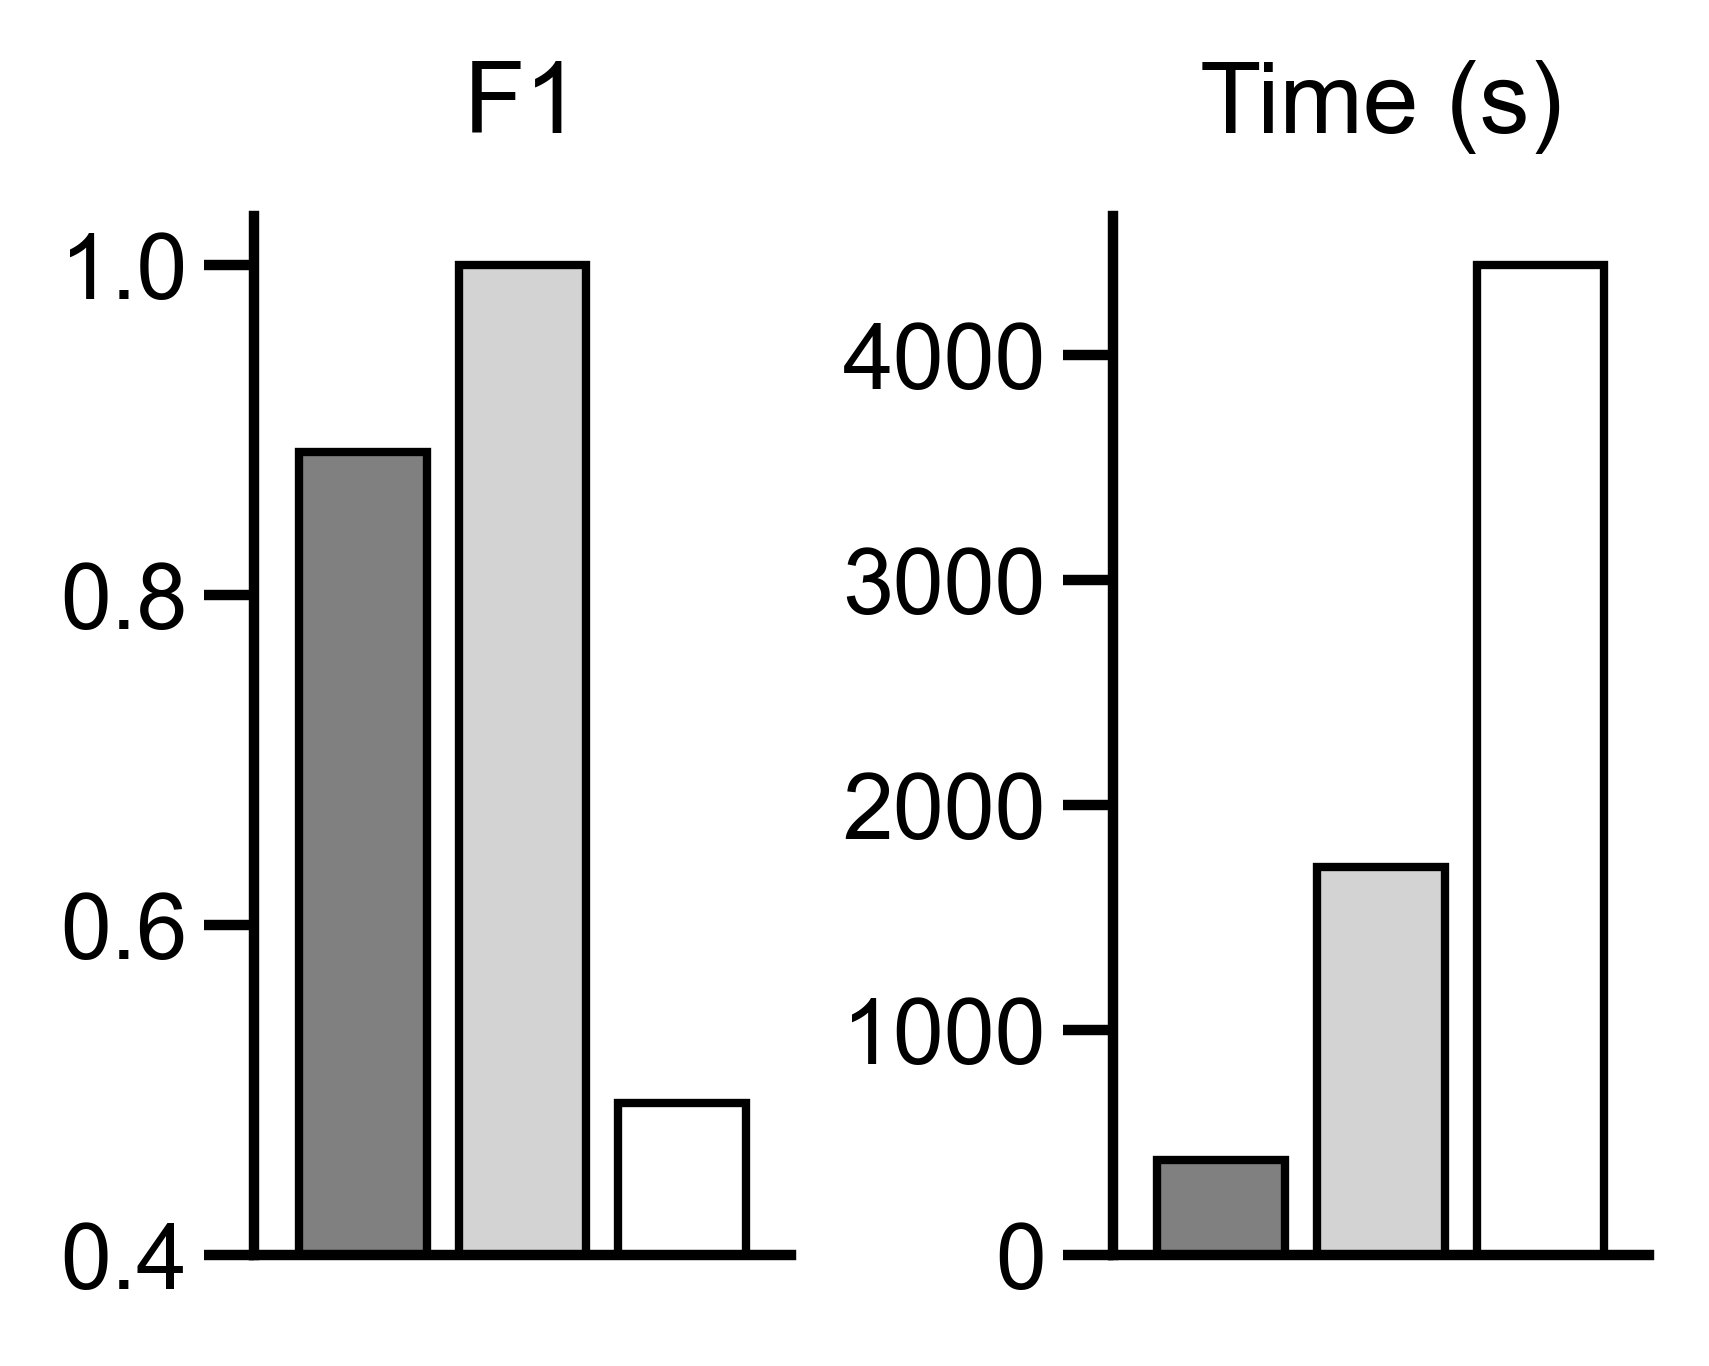

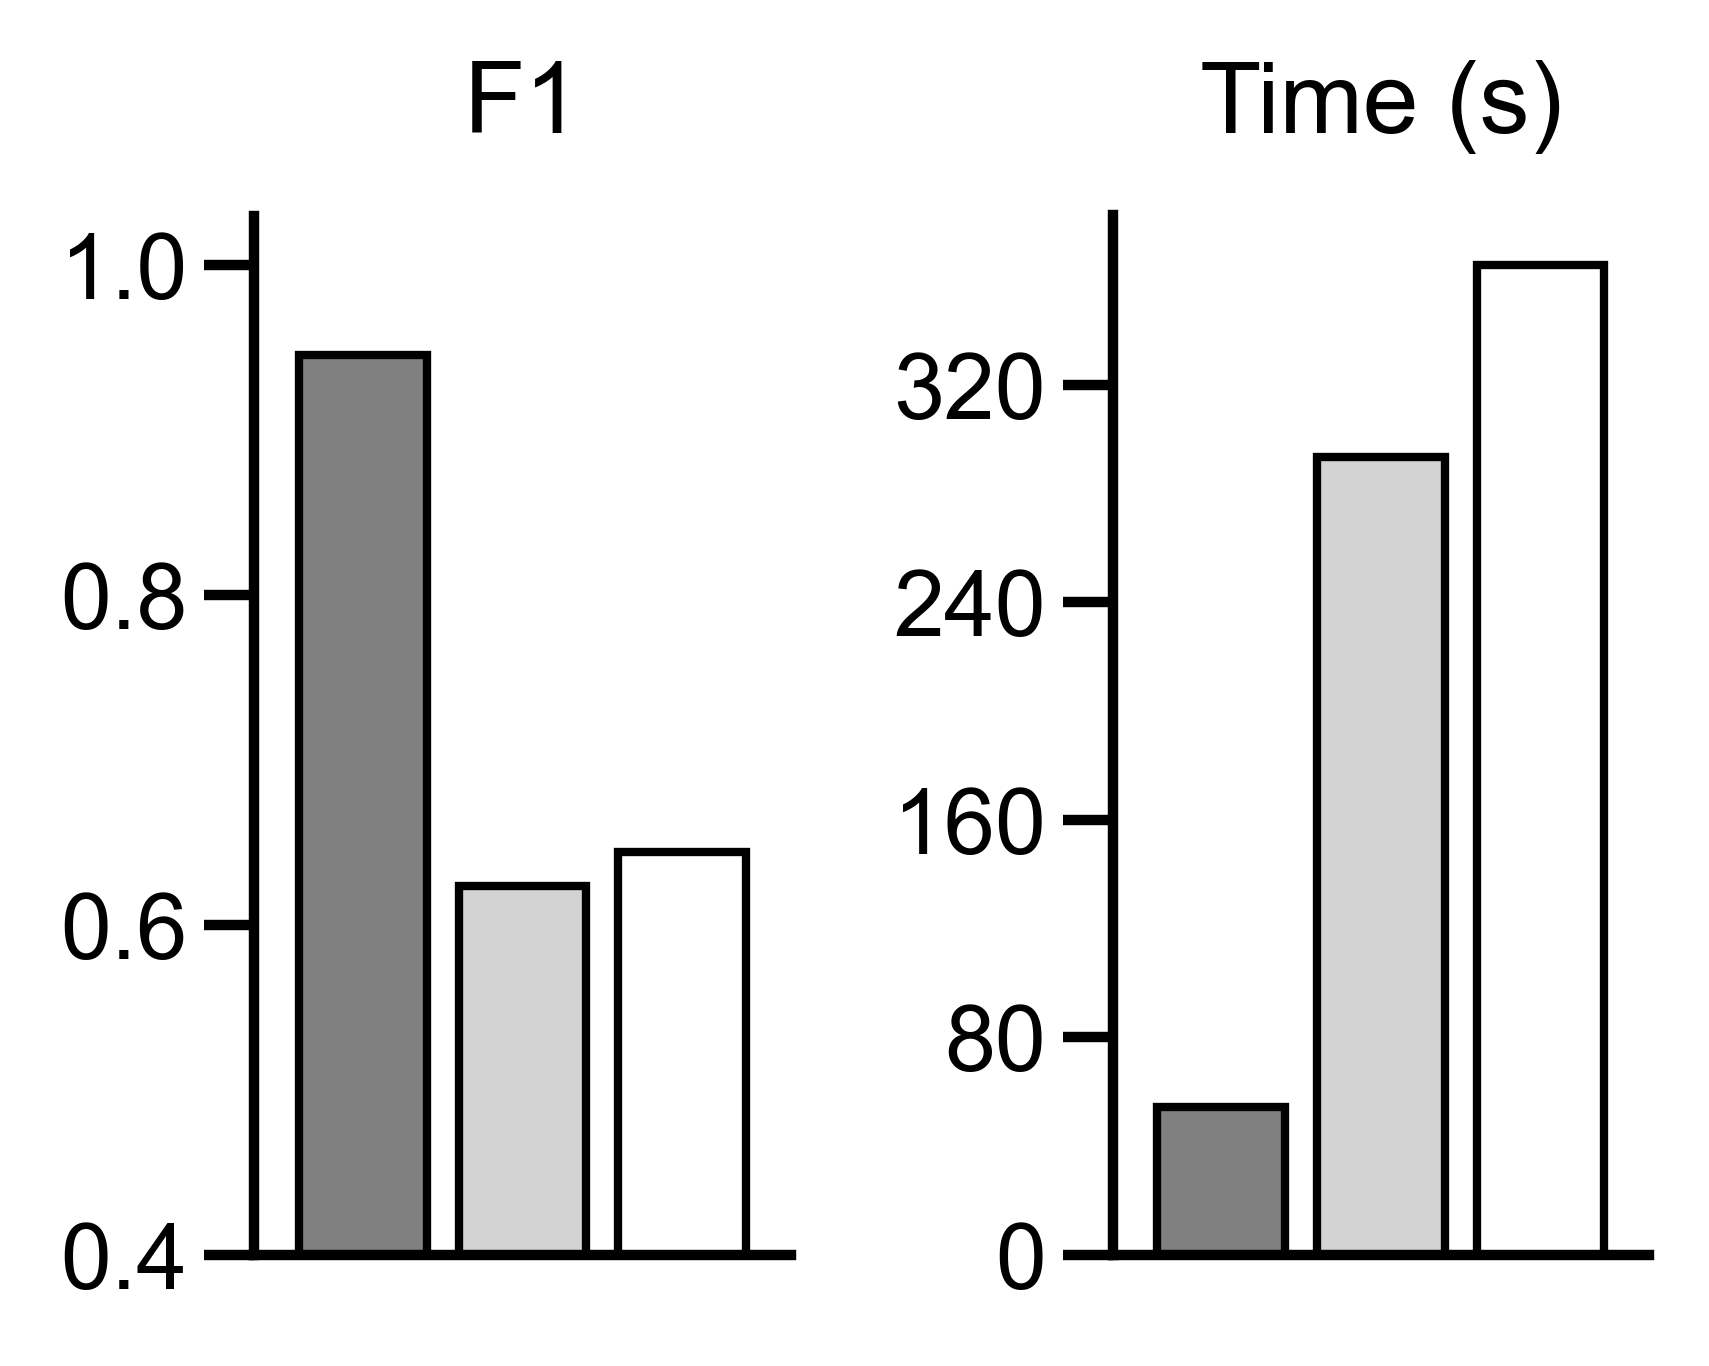

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "emmanuel results new.csv"))
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
metrics = ["f1", "total_time"]
method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  
# 
for sample in results["sample"].unique():
    sample_results = results[results["sample"] == sample]                  
    agg = sample_results.groupby("method")[metrics].agg(["mean", "std"])

    x = np.arange(len(methods))          # one group center per method
    color =  "black"

    fig, axes = plt.subplots(
        figsize=(3, 2.25),
        dpi=600,
        ncols=2,
        gridspec_kw={"width_ratios": [1,1], "wspace": 0.6},
    )


    for i, metric in enumerate(metrics):
            means = [agg.loc[m, (metric, "mean")] for m in methods]
            sds   = [agg.loc[m, (metric, "std")]  for m in methods]
            axes[i].bar(x=methods, height=means, capsize=4, linewidth=1,
                    label="Time", color=[method_colors[m] for m in methods], edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars

            axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
            axes[i].set_xticklabels("")
            axes[i].spines["top"].set_visible(False)
            axes[i].spines["right"].set_visible(False)

            axes[i].tick_params(left=True, bottom=False) 
            axes[i].tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
            axes[i].margins(x=0.1)
            axes[i].set_ylabel("")

        
            if i == 0:
                    axes[i].set_title("F1", pad=10)
                    axes[i].set_ylim(0.4, 1.03)
                    axes[i].yaxis.set_major_locator(MaxNLocator(nbins=4))
            else:
                    axes[i].set_title("Time (s)", pad=10)
                    # axes[i].set_ylim(0, 2500)

    figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
    plt.savefig(os.path.join(figure_folder, f"emmanuel_{sample}.eps"), dpi=600, bbox_inches="tight")
    plt.show()

In [24]:
import napari
import os
import tifffile
import numpy as np
from napari.utils.colormaps import colormap_utils as cu
from skimage.transform import resize
from scipy import ndimage
colormap = cu.label_colormap(num_colors=1024)

# input_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001"
# sample_name = "40x WIS zstack DAPI midbrain"
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"

# image = tifffile.imread(os.path.join(input_directory, sample_name, f"{sample_name}.TIF"))[:, 300:, :]
# cp = tifffile.imread(os.path.join(input_directory, sample_name, f"3d_segmented_cp4.tif"))[:, 300:, :]
# nuclogic = tifffile.imread(os.path.join(input_directory, sample_name, f"3d_segmented_nuclogic.tif"))[:, 300:, :]

# degraded_image = tifffile.imread(os.path.join(input_directory, sample_name, f"{sample_name}_degraded.TIF"))[:, 300:, :]
# degraded_image = resize(degraded_image, image.shape, order=1)  # rescale back to original size
# #renormalize over 255
# degraded_image = (degraded_image / np.percentile(degraded_image, 99.8) * 255).astype(np.uint8)
# cp_degraded = tifffile.imread(os.path.join(input_directory, sample_name, f"3d_segmented_cp4_degraded.tif"))[:, 300:, :]
# nuclogic_degraded = tifffile.imread(os.path.join(input_directory, sample_name, f"3d_segmented_nuclogic_degraded.tif"))[:, 300:, :]

# # calculate window for showing only 1:8th of xy planes
# xy_8 = slice(0, image.shape[1] * 1 // 8)
# xy_8_degraded = slice(0, degraded_image.shape[1] * 1 // 8)
# scale = (0.43, 0.23, 0.23)  # in micrometers
# viewer = napari.Viewer(ndisplay=2)
# # viewer.add_image(image, scale=scale) #contrast_limits=(0, 600) for degraded
# viewer.add_image(image, scale=scale, contrast_limits=(0, 600)) #contrast_limits=(0, 600) for degraded
# viewer.add_labels(gt, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(cp4, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.reset_view()
# # move to z 594
# viewer.dims.set_point(0, 575 * scale[0]) 
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# viewer.grid.enabled = True
# viewer.camera.zoom  = 3
# napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "emmanuel_degraded_slice.png"), size=(2160, 3840), canvas_only=True, scale = 1)

scale = (1, 0.1678, 0.1678)  # in micrometers
viewer = napari.Viewer(ndisplay=3)
# viewer.add_image(image[:, xy_8, :], scale=scale) #contrast_limits=(0, 600) for degraded
# viewer.add_labels(cp[:, xy_8, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(nuclogic[:, xy_8, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_image(degraded_image[:, xy_8_degraded, :], scale=scale)
# viewer.add_labels(cp_degraded[:, xy_8_degraded, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(nuclogic_degraded[:, xy_8_degraded, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_image(image, name="Image", scale=scale) #contrast_limits=(0, 600) for degraded
viewer.add_labels(cp, name="CP", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(nuclogic, name="NucLogic", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_image(degraded_image, name="Degraded Image", scale=scale)
viewer.add_labels(cp_degraded, name="CP Degraded", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(nuclogic_degraded, name="NucLogic Degraded", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.grid.enabled = True
viewer.camera.zoom   = 1.5

napari.run()
viewer.screenshot(path=os.path.join(output_directory, "emmanuel_new.png"), size=(2160, 3840), canvas_only=True, scale = 1)

# viewer.camera.center = (255.82705268500638, 48.530579166199146, 251.23925045414418)
# viewer.camera.angles = (180.0, 0.0, 0.0)
viewer.camera.zoom = 4
# adjust brigthness for cp_degraded
limit = np.percentile(degraded_image[50], 99.8)
viewer.layers["Degraded Image"].contrast_limits = [0, limit]
# # # Reset view to the data bounds, then set a side-view camera angle (XZ view)
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "emmanuel_new_zoomed.png"), size=(2160, 3840), canvas_only=True, scale = 1)

# go to XY view and Z 90
viewer.dims.ndisplay = 2
viewer.dims.set_point(0, 90 * scale[0])
viewer.camera.zoom = 7
viewer.screenshot(path=os.path.join(output_directory, "emmanuel_new_slice.png"), size=(2160, 3840), canvas_only=True, scale = 1)



array([[[110, 110, 110, 255],
        [113, 113, 113, 255],
        [113, 113, 113, 255],
        ...,
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255]],

       [[110, 110, 110, 255],
        [113, 113, 113, 255],
        [113, 113, 113, 255],
        ...,
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255]],

       [[110, 110, 110, 255],
        [102, 102, 102, 255],
        [102, 102, 102, 255],
        ...,
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255]],

       ...,

       [[ 42,  42,  42, 255],
        [ 42,  42,  42, 255],
        [ 42,  42,  42, 255],
        ...,
        [158, 139, 180, 255],
        [158, 139, 180, 255],
        [158, 139, 180, 255]],

       [[ 42,  42,  42, 255],
        [ 42,  42,  42, 255],
        [ 42,  42,  42, 255],
        ...,
        [158, 139, 180, 255],
        [158, 139, 180, 255],
        [158, 139, 180, 255]],

       [[ 42

In [9]:
from imaris_ims_file_reader import ims
import numpy as np
import sys
import os
import tifffile
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import napari
from napari.utils.colormaps import colormap_utils as cu

colormap = cu.label_colormap(num_colors=1024)
number = 75
movie = ims(rf"C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F{number}_cropped.ims")

image = movie[16]
nuclei = np.max(image, axis=0) 
scale = (2.5, 0.64, 0.64)  # in micrometers

model1 = r"C:\Users\6331823\Local SSD\Train model fixed intestinal organoid\models\intestinal_H2B_20260907"
model2 = r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_low_quality_model"
model3 = r"C:\Users\6331823\Local SSD\Train model fixed intestinal organoid\models\2d_high_quality_model"
model4 = r"C:\Users\6331823\Local SSD\Train model fixed intestinal organoid\models\microtissue_dapi"

viewer = napari.Viewer(ndisplay=3)

for model in [model1, model2, model3, model4]:

    # model_loaded = load_model(model)
    # model_name = os.path.basename(model)

    # segment_2d = segment(nuclei, model_loaded)

    # tifffile.imwrite(
    #     rf"C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F{number}_cropped_segmented_2d_{model_name}.tif",
    #     segment_2d,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    # segment_3d = stitch_3d(
    #     segment_2d,
    #     nuclei,
    #     image_type_1="wt",
    #     breaking_threshold=3,
    #     scale=scale
    # )
    # tifffile.imwrite(
    #     rf"C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F{number}_cropped_segmented_3d_{model_name}.tif",
    #     segment_3d,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    segment_3d = tifffile.imread(
        rf"C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F{number}_cropped_segmented_3d_{os.path.basename(model)}.tif"
    )
    viewer.add_labels(segment_3d, name=f"{model_name}", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)



viewer.add_image(nuclei, name="nuclei", scale=scale, colormap="gray", blending="additive")

Opening readonly file: C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F75_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F75_cropped.ims 



c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:128: UserWarning: HistogramMax value is not present for resolution 3, time 21, channel 1. 
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:134: UserWarning: HistogramMin value is not present for resolution 3, time 21, channel 1.
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)


<Image layer 'nuclei' at 0x2a23c74ecd0>